In [29]:
from mace.calculators import MACECalculator
import numpy as np
import pandas as pd
import ase
from ase import Atom, Atoms

from ase.build import graphene
from ase.optimize import BFGS

from ase.filters import ExpCellFilter

from ase.visualize import view

from ase.io import write

import matplotlib.pyplot as plt

from tqdm import tqdm

from ase.phonons import Phonons

In [30]:
SQRT2 = np.sqrt(2)
SQRT3 = np.sqrt(3)
HALFSQRT3 = SQRT3/2.

INVSQRT2 = 1./SQRT2
INVSQRT3 = 1./SQRT3

class BaseMode():
    def __init__(self):
        self.xyz_directions = None
        return
    
    def apply(self, atoms, amplitude):
        copy = atoms.copy()
        copy.positions += amplitude * self.xyz_directions

        return copy.copy()
    
class AMode(BaseMode):
    def __init__(self):
        super().__init__()

        # These act as pure directional intents now; 
        # precise pre-normalization isn't strictly necessary if normalizing later
        d1 = np.array([1, 0, 0])
        d2 = np.array([INVSQRT2, -INVSQRT2, 0])
        d3 = np.array([0, 1, 0])
        
        self.directions = np.array([
            -d1, d1,
            d2, -d2,
            -d3, d3
        ])

        cell = np.array([
            [1, 0, 0],
            [0.5, HALFSQRT3, 0],
            [0, 0, 1]
        ])

        # 1. Transform to Cartesian coordinates
        xyz_raw = self.directions @ cell
        
        # 2. Calculate the magnitude (Euclidean norm) for each row
        magnitudes = np.linalg.norm(xyz_raw, axis=1, keepdims=True)
        
        # 3. Normalize so every vector has a physical length of 1.0
        # (Avoid division by zero just in case there's a zero vector)
        self.xyz_directions = np.divide(xyz_raw, magnitudes, out=np.zeros_like(xyz_raw), where=magnitudes!=0)

        return
    
class BMode(BaseMode):
    def __init__(self):
        super().__init__()

        d1 = [0, 1, 0]
        d2 = [-HALFSQRT3, -0.5, 0]
        d3 = [HALFSQRT3, -0.5, 0]
        self.xyz_directions = np.array([
            d1,
            d1,
            d2,
            d2,
            d3,
            d3
        ])

        return

BMODE = BMode()
AMODE = AMode()

In [31]:
def get_second_derivative_at_min(x, y, window_size=5):
    """
    Returns the second derivative at the minimum point of the data.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    # 1. Locate the minimum
    min_idx = np.argmin(y)

    # 2. Slice a window around the minimum
    hw = window_size // 2
    start, end = max(0, min_idx - hw), min(len(x), min_idx + hw + 1)
    
    x_local = x[start:end]
    y_local = y[start:end]

    # 3. Fit 2nd order poly (y = ax^2 + bx + c)
    # coeffs[0] is 'a'
    coeffs = np.polyfit(x_local, y_local, 2)
    
    # 4. Second derivative is d2/dx2 (ax^2 + bx + c) = 2a
    second_derivative = 2 * coeffs[0]

    return second_derivative

import numpy as np
import warnings

def get_second_derivative_at_zero(x, y, window_size=7):
    # compute second derivative and its uncertainty using 4th order polynomial
    x = np.asarray(x)
    y = np.asarray(y)

    # 1. Find the index where x is closest to 0
    zero_idx = np.argmin(np.abs(x))

    # 2. Define the window boundaries
    half_w = window_size // 2
    start = max(0, zero_idx - half_w)
    end = min(len(x), zero_idx + half_w + 1)

    x_local = x[start:end]
    y_local = y[start:end]

    # 3. Fit a 4th degree polynomial
    # We need at least 6 points to compute a covariance matrix for deg=4
    if len(x_local) < 6:
        return np.nan, np.nan 


    coeffs, cov_matrix = np.polyfit(x_local, y_local, 4, cov=True)


    # 4. Extract the second derivative and its uncertainty at x = 0
    # coeffs: [c0*x^4, c1*x^3, c2*x^2, c3*x, c4]
    # Second derivative at x=0 is 2 * c2
    second_deriv = 2 * coeffs[2]
    
    # cov_matrix[2, 2] is the variance of c2
    c2_uncertainty = np.sqrt(cov_matrix[2, 2])
    second_deriv_uncertainty = 2 * c2_uncertainty

    return second_deriv, second_deriv_uncertainty

def ploy4fit(x, y, window_size=7):
    # compute second derivative and its uncertainty using 4th order polynomial
    x = np.asarray(x)
    y = np.asarray(y)

    # 1. Find the index where x is closest to 0
    zero_idx = np.argmin(np.abs(x))

    # 2. Define the window boundaries
    half_w = window_size // 2
    start = max(0, zero_idx - half_w)
    end = min(len(x), zero_idx + half_w + 1)

    x_local = x[start:end]
    y_local = y[start:end]

    # 3. Fit a 4th degree polynomial
    # We need at least 6 points to compute a covariance matrix for deg=4
    if len(x_local) < 6:
        return np.nan, np.nan 


    coeffs, cov_matrix = np.polyfit(x_local, y_local, 4, cov=True)
    
    # cov_matrix[2, 2] is the variance of c2
    c2_uncertainty = np.sqrt(cov_matrix[2, 2])
    second_deriv_uncertainty = 2 * c2_uncertainty

    return coeffs, cov_matrix

In [32]:
model = MACECalculator("../../MACE.model", device = "cuda")

Using head Default out of ['Default']
No dtype selected, switching to float32 to match model dtype.


/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


In [33]:
primitive = graphene()
primitive.cell[2] = [0,0,100]
filter = ExpCellFilter(primitive, mask = [1,1,0,0,0,0])
primitive.calc = model

opt = BFGS(filter)
opt.run(fmax = 1e-5)

/tmp/ipykernel_53406/1072062919.py:3: DeprecationWarning: Use FrechetCellFilter for better convergence w.r.t. cell variables.
  filter = ExpCellFilter(primitive, mask = [1,1,0,0,0,0])


      Step     Time          Energy          fmax
BFGS:    0 15:02:22      -15.917213        0.014585


BFGS:    1 15:02:22      -15.917212        0.029116
BFGS:    2 15:02:22      -15.917212        0.000018
BFGS:    3 15:02:22      -15.917215        0.000041
BFGS:    4 15:02:22      -15.917213        0.000033
BFGS:    5 15:02:22      -15.917215        0.000004


np.True_

In [34]:
cell0 = primitive.cell.copy()
a0 = np.linalg.norm(cell0[0])
l0 = primitive.get_all_distances()[0][1]

In [35]:
supercell = np.array([
    [15, -15, 0],
    [15, 15, 0],
    [0, 0, 1]
])

from ase.build import make_supercell

supercell_atoms = make_supercell(primitive, supercell, wrap = True)
view(supercell_atoms, viewer = "ngl")

In [36]:
print(np.linalg.norm(supercell_atoms.cell, axis = 1))
print(len(supercell_atoms))

[ 63.90822749  36.8974326  100.        ]
900


In [37]:
supercell_atoms.calc = model
stress = supercell_atoms.get_stress()

In [38]:
stress

array([-7.1564676e-10, -5.8060201e-10,  2.8025969e-45,  4.3924829e-31,
        5.5550369e-31, -2.0496280e-10], dtype=float32)

In [39]:
write("supercell_20_12.lammps-data", supercell_atoms)

In [40]:
def generate_primitive(latticeparam=2.46):
    a = latticeparam

    # Primitive vectors rotated 30° relative to your original.
    # a1 points at 30°, a2 points at 90° — armchair direction is now along X.
    cell = np.array([
        [0.5 * np.sqrt(3) * a,  0.5 * a, 0],   # a1 at 30°
        [0,                      a,       0],   # a2 at 90°
        [0,                      0,      20.0]
    ])

    # Same fractional coordinates as your original — still valid graphene
    positions_frac = np.array([
        [1/3, 1/3, 0],
        [2/3, 2/3, 0]
    ])

    xyz_positions = positions_frac @ cell

    atoms = Atoms("C2",
                  positions=xyz_positions,
                  cell=cell,
                  pbc=(True, True, False))

    return atoms

In [41]:
primitive = generate_primitive(2.4598288248992755)

In [42]:
DEG2RAG = np.pi / 180
angle = 45
rot = 0
amplitude = 0.2275

C = np.cos(angle * DEG2RAG)
S = np.sin(angle * DEG2RAG)

Cr = np.cos(rot * DEG2RAG)
Sr = np.sin(rot * DEG2RAG)

ROT = np.array([
    [Cr, -Sr, 0],
    [Sr, Cr, 0],
    [0, 0, 1]
])

strain_versor = np.array([
    [C, 0, 0],
    [0, S, 0],
    [0, 0, 0]
])
strain = amplitude * strain_versor
deformation = np.eye(3) + strain

deformed_primitive = primitive.copy()
deformed_primitive.calc = model

opt = BFGS(deformed_primitive)
opt.run(1e-5)

deformed_primitive.set_cell(deformed_primitive.cell @ deformation, scale_atoms=True)

      Step     Time          Energy          fmax
BFGS:    0 15:02:28      -15.917215        0.000001


In [43]:
from ase.phonons import Phonons
ph = Phonons(
    deformed_primitive,
    model,
    supercell = (9, 9, 1),
    delta = 0.00005,
    name="cache"
)

ph.run()
ph.read(acoustic=True)
ph.clean()



13

In [44]:
bandpath = primitive.cell.bandpath(path="GMKG", npoints = 200)
bs, modes = ph.get_band_structure(bandpath, modes=True)

WARNING, 2 imaginary frequencies at q = ( 0.00,  0.00,  0.00) ; (omega_q = 3.079e-03*i)
WARNING, 1 imaginary frequencies at q = ( 0.01,  0.00,  0.00) ; (omega_q = 1.149e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.35, -0.30,  0.00) ; (omega_q = 6.099e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.35, -0.31,  0.00) ; (omega_q = 9.612e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.34, -0.32,  0.00) ; (omega_q = 1.155e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.34, -0.33,  0.00) ; (omega_q = 1.265e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.33, -0.33,  0.00) ; (omega_q = 1.312e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.33, -0.33,  0.00) ; (omega_q = 1.287e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.33, -0.33,  0.00) ; (omega_q = 1.212e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.32, -0.32,  0.00) ; (omega_q = 1.080e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.32, -0.32,  0.00) ; (omega_q = 8.645e-02*i)
WARNING, 1 imaginary frequencies

(-0.018483431851095113, 0.0015165681489048878)

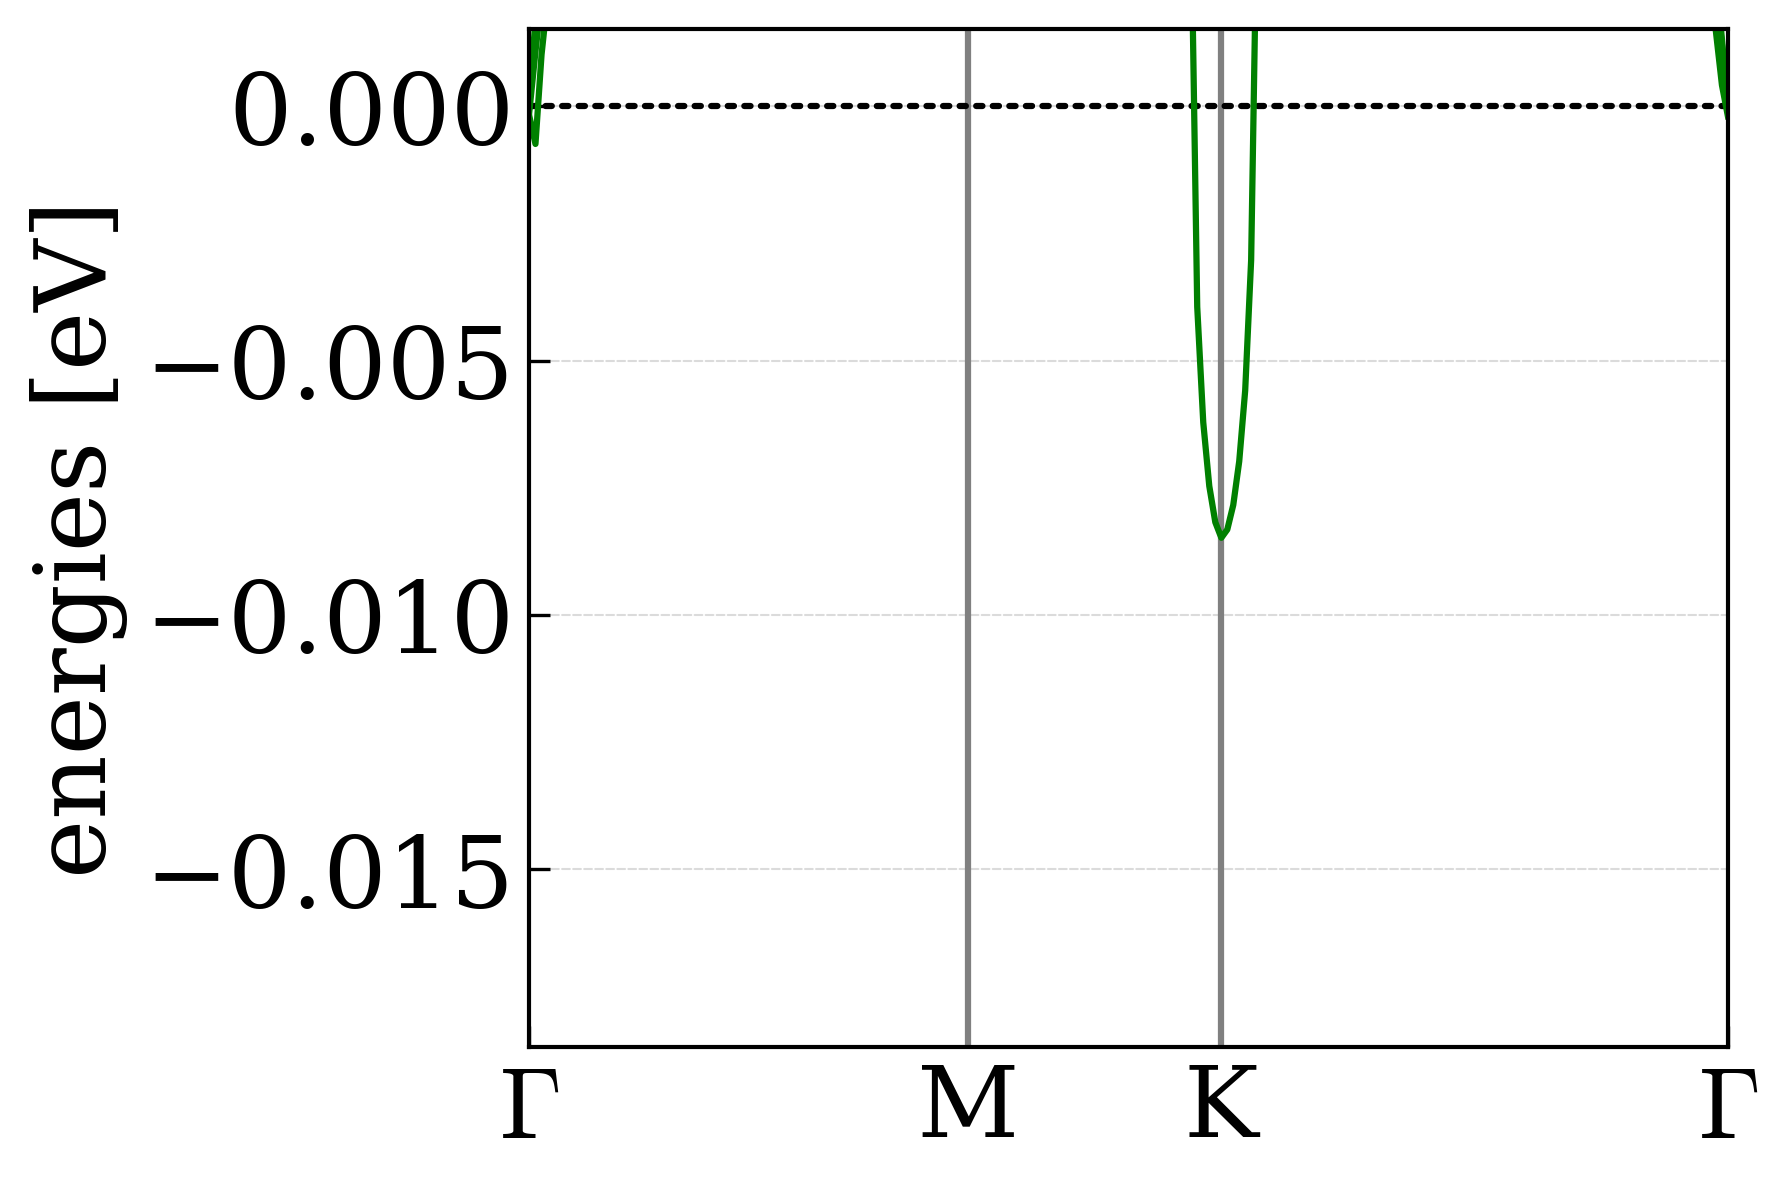

In [45]:
bs.plot()
mine = np.min(bs.energies)
maxe = np.max(bs.energies)
plt.ylim(mine - 0.01, mine + 0.01)

In [46]:
KCELL0 = 3*l0* np.array([
    [1,0,0],
    [0.5, np.sqrt(3)/2, 0],
    [0,0,100]
])
# in K cell 0 primitive direction
KBASE0 = (1/3.) * np.array([
    [1, 0, 0],
    [2, 0, 0],
    [2, 1, 0],
    [1, 2, 0],
    [0, 1, 0],
    [0, 2, 0]
])

katoms = Atoms("C6", positions = KBASE0 @ KCELL0, cell=KCELL0, pbc = [True, True, True])


In [47]:
opt = BFGS(atoms=katoms)
katoms.calc = model
opt.run(fmax = 1e-5)

      Step     Time          Energy          fmax
BFGS:    0 15:02:33      -47.751644        0.000002


np.True_

In [48]:
write("kcell.extxyz", katoms)

In [49]:
DEG2RAG = np.pi / 180
angle = 45
rot = 0
amplitude = 0.2275

C = np.cos(angle * DEG2RAG)
S = np.sin(angle * DEG2RAG)

Cr = np.cos(rot * DEG2RAG)
Sr = np.sin(rot * DEG2RAG)

ROT = np.array([
    [Cr, -Sr, 0],
    [Sr, Cr, 0],
    [0, 0, 1]
])

strain_versor = np.array([
    [C, 0, 0],
    [0, S, 0],
    [0, 0, 0]
])
strain = amplitude * strain_versor
deformation = np.eye(3) + strain

deformed_k = katoms.copy()
deformed_k.calc = model

opt = BFGS(deformed_k)
opt.run(1e-5)

deformed_k.set_cell(katoms.cell @ deformation, scale_atoms=True)

      Step     Time          Energy          fmax
BFGS:    0 15:02:34      -47.751644        0.000002


WARNING, 3 imaginary frequencies at q = ( 0.00,  0.00,  0.00) ; (omega_q = 3.347e-02*i)
WARNING, 2 imaginary frequencies at q = ( 0.01,  0.00,  0.00) ; (omega_q = 3.026e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.01,  0.00,  0.00) ; (omega_q = 1.744e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.01, -0.01,  0.00) ; (omega_q = 1.877e-02*i)
WARNING, 2 imaginary frequencies at q = ( 0.00, -0.00,  0.00) ; (omega_q = 3.043e-02*i)
WARNING, 3 imaginary frequencies at q = ( 0.00,  0.00,  0.00) ; (omega_q = 3.347e-02*i)


(-0.012164220899886908, 0.007835779100113092)

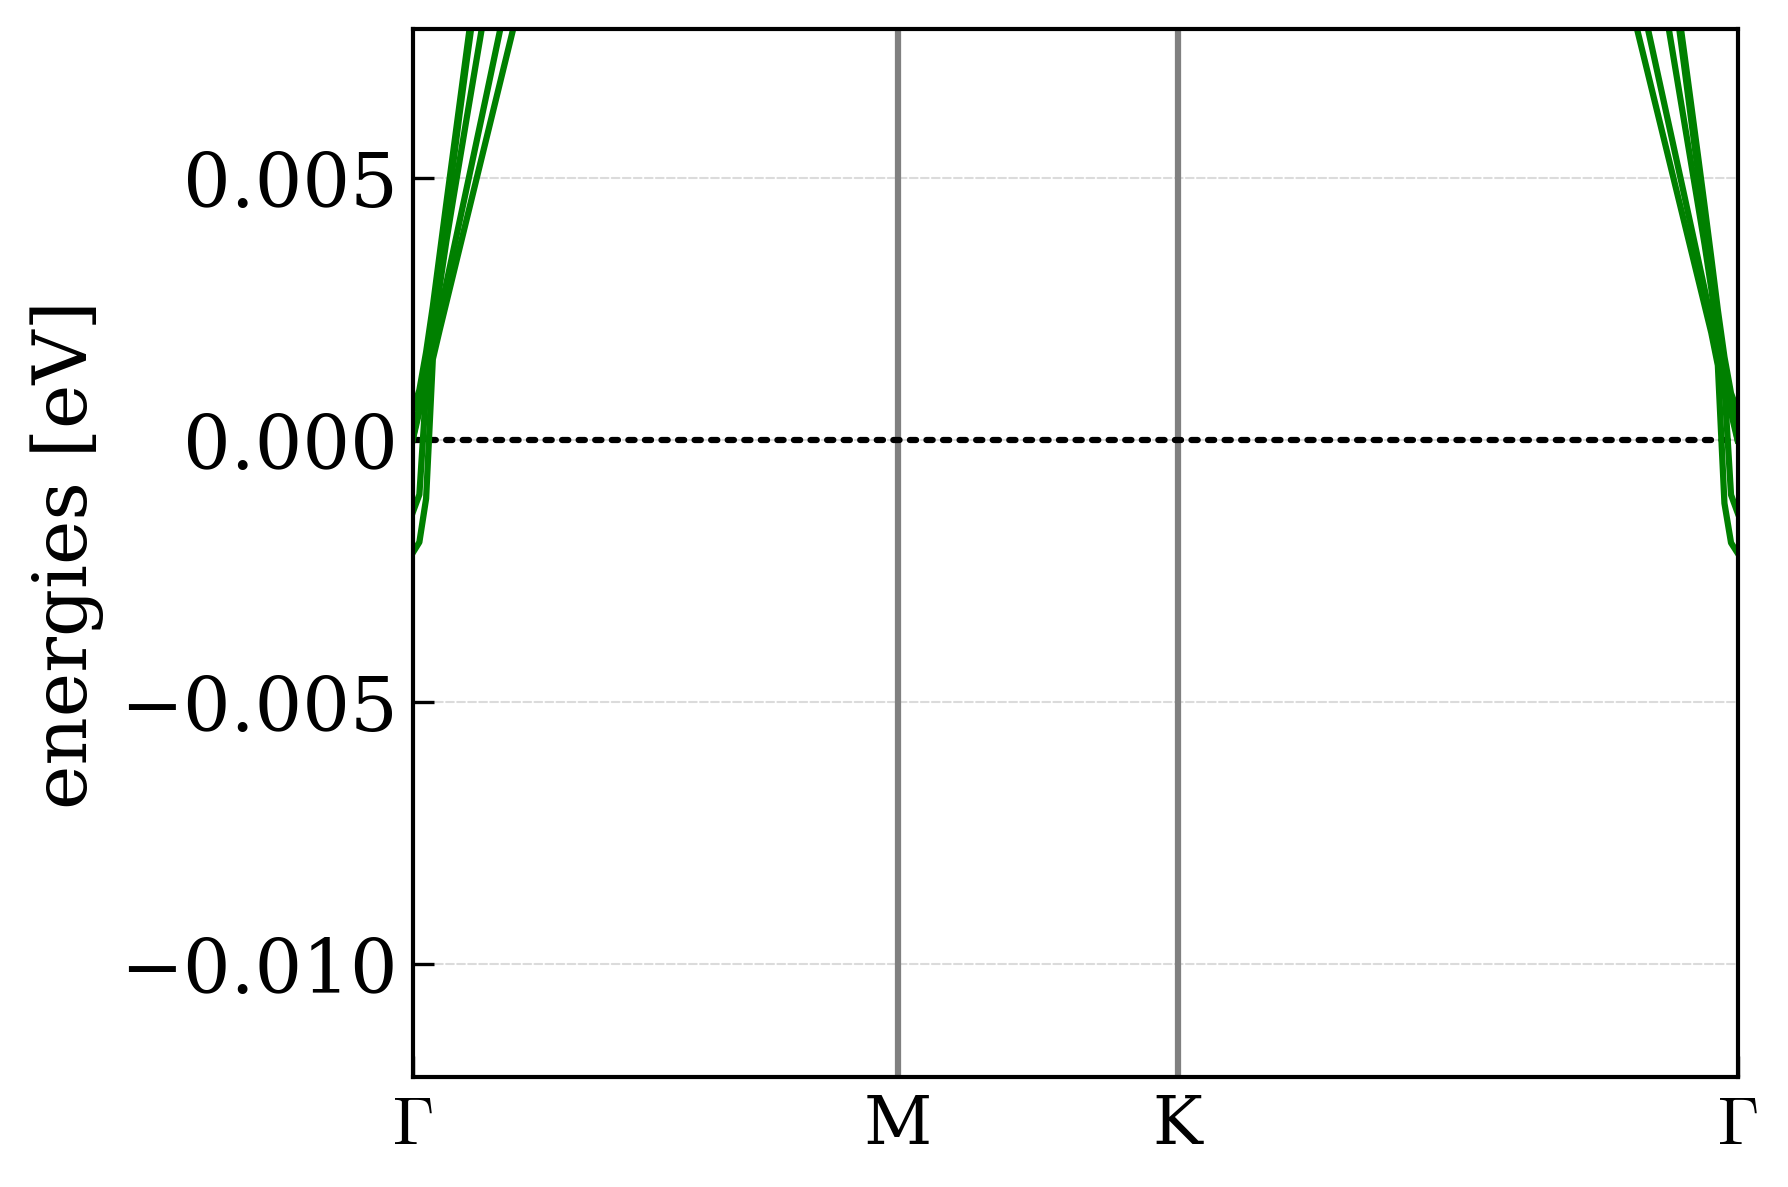

In [25]:
from ase.phonons import Phonons
ph = Phonons(
    deformed_k,
    model,
    supercell = (9, 9, 1),
    delta = 0.001,
    name="cache"
)

ph.run()
ph.read(acoustic=True)
ph.clean()

bandpath = katoms.cell.bandpath(path="GMKG", npoints = 200)
bs, modes = ph.get_band_structure(bandpath, modes=True)

bs.plot()
mine = np.min(bs.energies)
maxe = np.max(bs.energies)
plt.ylim(mine - 0.01, mine + 0.01)

In [26]:
def bisect_mode_amplitude(atoms, mode: BaseMode, min, max, treshold = 1e-4):
    low = min
    high = max

    atoms.calculator = model

    minatoms = mode.apply(atoms, min)
    minatoms.calc = model
    lowval = minatoms.get_potential_energy()

    maxatoms = mode.apply(atoms, max)
    maxatoms.calc = model
    maxatoms.calc = model
    highval = maxatoms.get_potential_energy()

    width = high - low
    mid = low + (high - low) / 2

    midatoms = mode.apply(atoms, mid)

    while width > treshold:
        print(low, mid, high)

        mid = low + (high - low) / 2
        midatoms = mode.apply(atoms, mid)
        midatoms.calc = model
        midval = midatoms.get_potential_energy()
        width /= 2

        if highval > lowval:
            highval = midval
            high = mid
            continue

        lowval = midval
        low = mid
        continue

    return mid, midval, midatoms

In [27]:
mid, midval, midatoms = bisect_mode_amplitude(deformed_k, AMODE, 0, 0.5)

0 0.25 0.5
0 0.25 0.25
0 0.125 0.125
0 0.0625 0.0625
0.03125 0.03125 0.0625
0.046875 0.046875 0.0625
0.0546875 0.0546875 0.0625
0.05859375 0.05859375 0.0625
0.060546875 0.060546875 0.0625
0.0615234375 0.0615234375 0.0625
0.06201171875 0.06201171875 0.0625
0.062255859375 0.062255859375 0.0625
0.0623779296875 0.0623779296875 0.0625


WARNING, 2 imaginary frequencies at q = ( 0.00,  0.00,  0.00) ; (omega_q = 1.360e-03*i)
WARNING, 1 imaginary frequencies at q = ( 0.01,  0.00,  0.00) ; (omega_q = 1.776e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.01,  0.00,  0.00) ; (omega_q = 3.509e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.02,  0.00,  0.00) ; (omega_q = 5.185e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.03,  0.00,  0.00) ; (omega_q = 6.781e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.03,  0.00,  0.00) ; (omega_q = 8.284e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.04,  0.00,  0.00) ; (omega_q = 9.687e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.05,  0.00,  0.00) ; (omega_q = 1.099e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.06,  0.00,  0.00) ; (omega_q = 1.218e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.06,  0.00,  0.00) ; (omega_q = 1.328e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.07,  0.00,  0.00) ; (omega_q = 1.429e-01*i)
WARNING, 1 imaginary frequencies

(-0.023402679633485086, -0.003402679633485086)

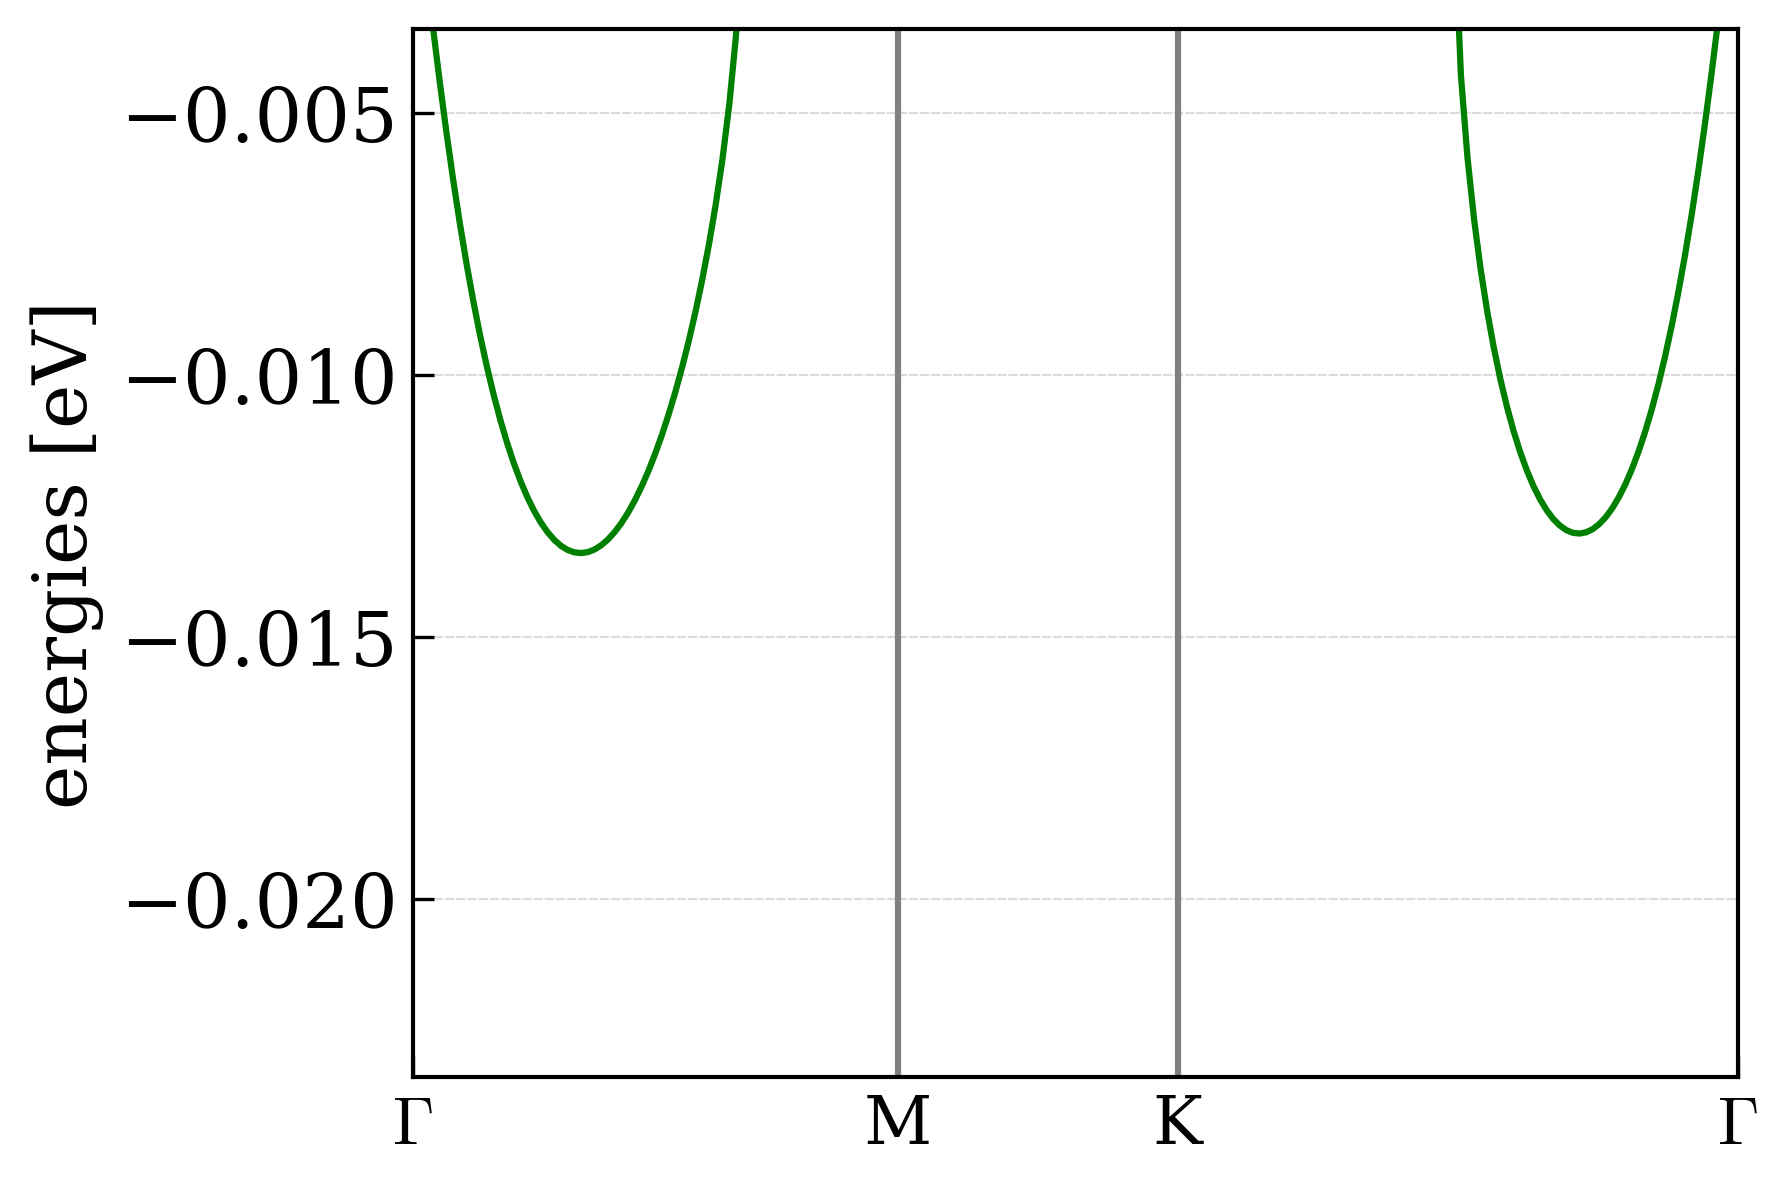

In [28]:
from ase.phonons import Phonons
ph = Phonons(
    midatoms,
    model,
    supercell = (9, 9, 1),
    delta = 0.001,
    name="cache"
)

ph.run()
ph.read(acoustic=True)
ph.clean()

bandpath = katoms.cell.bandpath(path="GMKG", npoints = 200)
bs, modes = ph.get_band_structure(bandpath, modes=True)

bs.plot()
mine = np.min(bs.energies)
maxe = np.max(bs.energies)
plt.ylim(mine - 0.01, mine + 0.01)

In [29]:
# min_idx = np.argmin(bs.energies)
# mine = bs.energies[min_idx]

# kidx = min_idx // 18
# mode_idx = min_idx % 18 

# # kidx = 0
# # mode_idx = 1
# kpoint = bs.path.kpts[kidx]

# mode = modes[kidx][mode_idx]

In [30]:
ph = Phonons(
    deformed_k,
    model,
    supercell = (9, 9, 1),
    delta = 0.01,
    name="cache"
)

ph.run()
ph.read(acoustic=True)
ph.clean()

kpoint = np.array([0, 0, 0])
Dk = ph.compute_dynamical_matrix(
    np.array(kpoint),
    ph.D_N
)

In [31]:
Dk.shape

(18, 18)

In [32]:
eigenvalues, modes = np.linalg.eigh(Dk, UPLO="U")

In [33]:
eigenvalues

array([-3.04064378e-04, -1.70261042e-04, -1.59076999e-09, -1.00001829e-15,
        9.10619021e-07,  1.11719592e+00,  1.11719640e+00,  1.11719656e+00,
        1.11719685e+00,  1.64546438e+00,  1.90866242e+00,  1.90872073e+00,
        1.90881917e+00,  1.90882801e+00,  2.04482385e+00,  2.04491067e+00,
        2.67149918e+00,  2.67157621e+00])

In [34]:
modes[0]

array([-3.78605766e-01+0.j,  1.71549257e-01+0.j, -3.23064140e-04+0.j,
       -3.91720806e-11+0.j, -4.00687460e-01+0.j, -9.71605738e-07+0.j,
       -2.47849204e-05+0.j, -7.93265967e-06+0.j,  2.18148039e-05+0.j,
       -1.61212705e-06+0.j, -2.01207988e-01+0.j, -2.49960528e-01+0.j,
       -4.29206809e-01+0.j, -2.14687474e-01+0.j,  4.16451990e-02+0.j,
       -4.06233234e-01+0.j,  1.03694038e-01+0.j, -3.94831162e-01+0.j])

In [35]:
modes = (
                    ph.m_inv_x[:, np.newaxis] * modes[:, eigenvalues.argsort()]
                ).T.copy().reshape((-1, len(ph.indices), 3))

(6, 3)


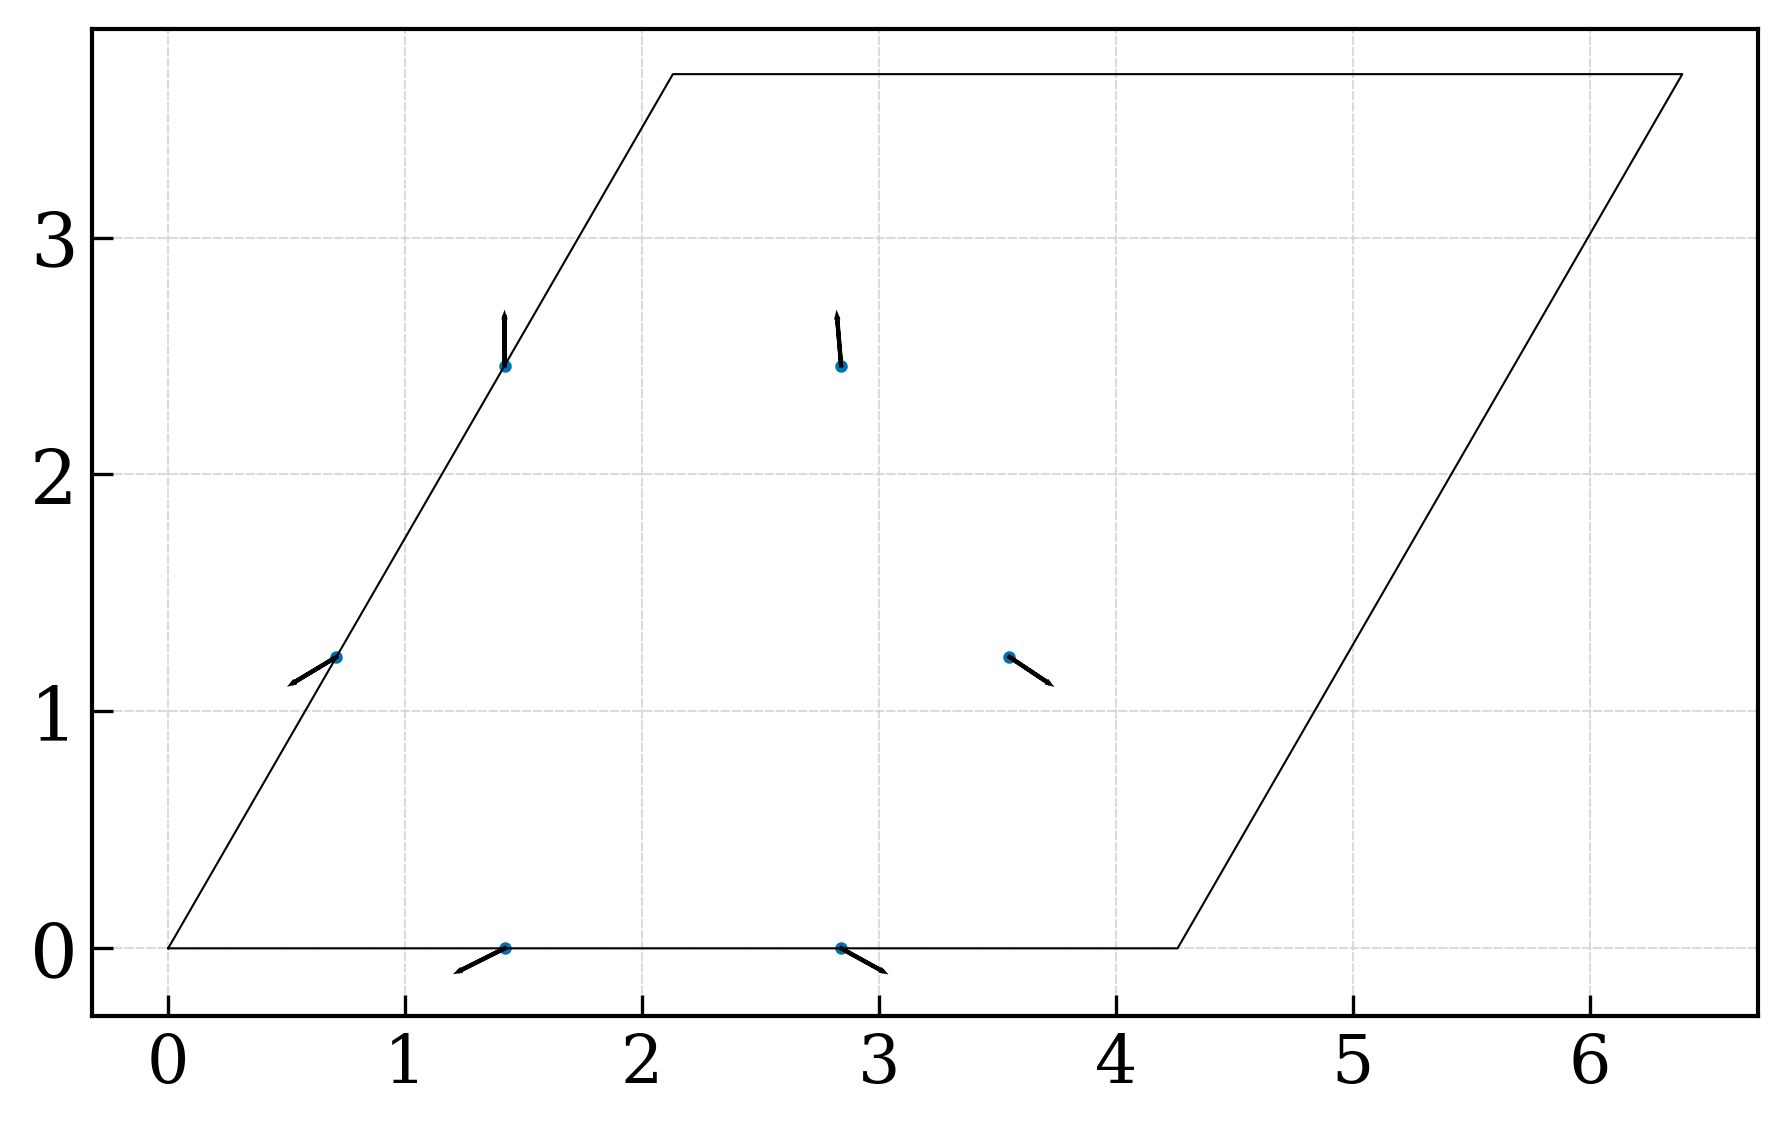

In [36]:
fig, ax = plt.subplots()

mode = modes[0]
norm_mode = mode / np.linalg.norm(mode)
amp = 0.5
displacements = amp * norm_mode
displacements = np.real(displacements)
print(displacements.shape)

ax.scatter(
    katoms.positions[:,0], katoms.positions[:,1]
)

ax.plot([0, KCELL0[0,0], KCELL0[0,0]+KCELL0[1,0], KCELL0[1,0], 0], [0, KCELL0[0,1], KCELL0[0,1]+KCELL0[1,1], KCELL0[1,1], 0], color="black", linewidth=0.5)


for at, disp in zip(katoms.positions, displacements):
    ax.arrow(
        at[0], at[1], disp[0], disp[1]
    )

ax.set_aspect("equal")

In [38]:
import subprocess
ROOT = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()

import sys, os

sys.path.append(f"{ROOT}/KAGGLE_DOWNLOAD/from_C2_v1/INSTABILITY/graphene/PHONONS_INSTABILITY_BOUNDARY/KPOINTS_INSTABILITIES")

from energy_vs_amplitude import energy_mode

In [39]:
mode_amplitudes = np.linspace(-0.2, 0.2, 101, endpoint = True)
mode_amplitudes_zoomed = np.linspace(-0.05, 0.05, 101, endpoint = True)

phonon_mode, energies, force_projections = energy_mode(
    katoms, 
    strain_versor, 
    amplitude, 
    np.array([1,1,1]), 
    model, 
    np.array([kpoint]),
    np.array([norm_mode]),
    np.array([1]),
    mode_amplitudes,
)

phonon_mode_zoomed, energies_zoomed, force_projections_zoomed = energy_mode(
    katoms, 
    strain_versor, 
    amplitude, 
    np.array([1,1,1]), 
    model, 
    np.array([kpoint]),
    np.array([norm_mode]),
    np.array([1]),
    mode_amplitudes_zoomed,
)

In [40]:
from scipy.constants import elementary_charge, atomic_mass, h, hbar

conversion = 1

mass = 12.011
w2 = eigenvalues[0]

deformed_k.calc = model
e0 = deformed_k.get_potential_energy()
harmonic_energies = (e0 + 
                     conversion * 0.5 * mass * w2 * mode_amplitudes**2 * np.sum(norm_mode * norm_mode))

harmonic_energies_zoomed = (e0 + 
                     conversion * 0.5 * mass * w2 * mode_amplitudes_zoomed**2 * np.sum(norm_mode * norm_mode))

In [41]:
eigenvalues

array([-3.04064378e-04, -1.70261042e-04, -1.59076999e-09, -1.00001829e-15,
        9.10619021e-07,  1.11719592e+00,  1.11719640e+00,  1.11719656e+00,
        1.11719685e+00,  1.64546438e+00,  1.90866242e+00,  1.90872073e+00,
        1.90881917e+00,  1.90882801e+00,  2.04482385e+00,  2.04491067e+00,
        2.67149918e+00,  2.67157621e+00])

In [42]:
from numpy import poly1d

/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)


-0.0018260586199626404
-0.0038627898551474933 3.377133620471391e-06


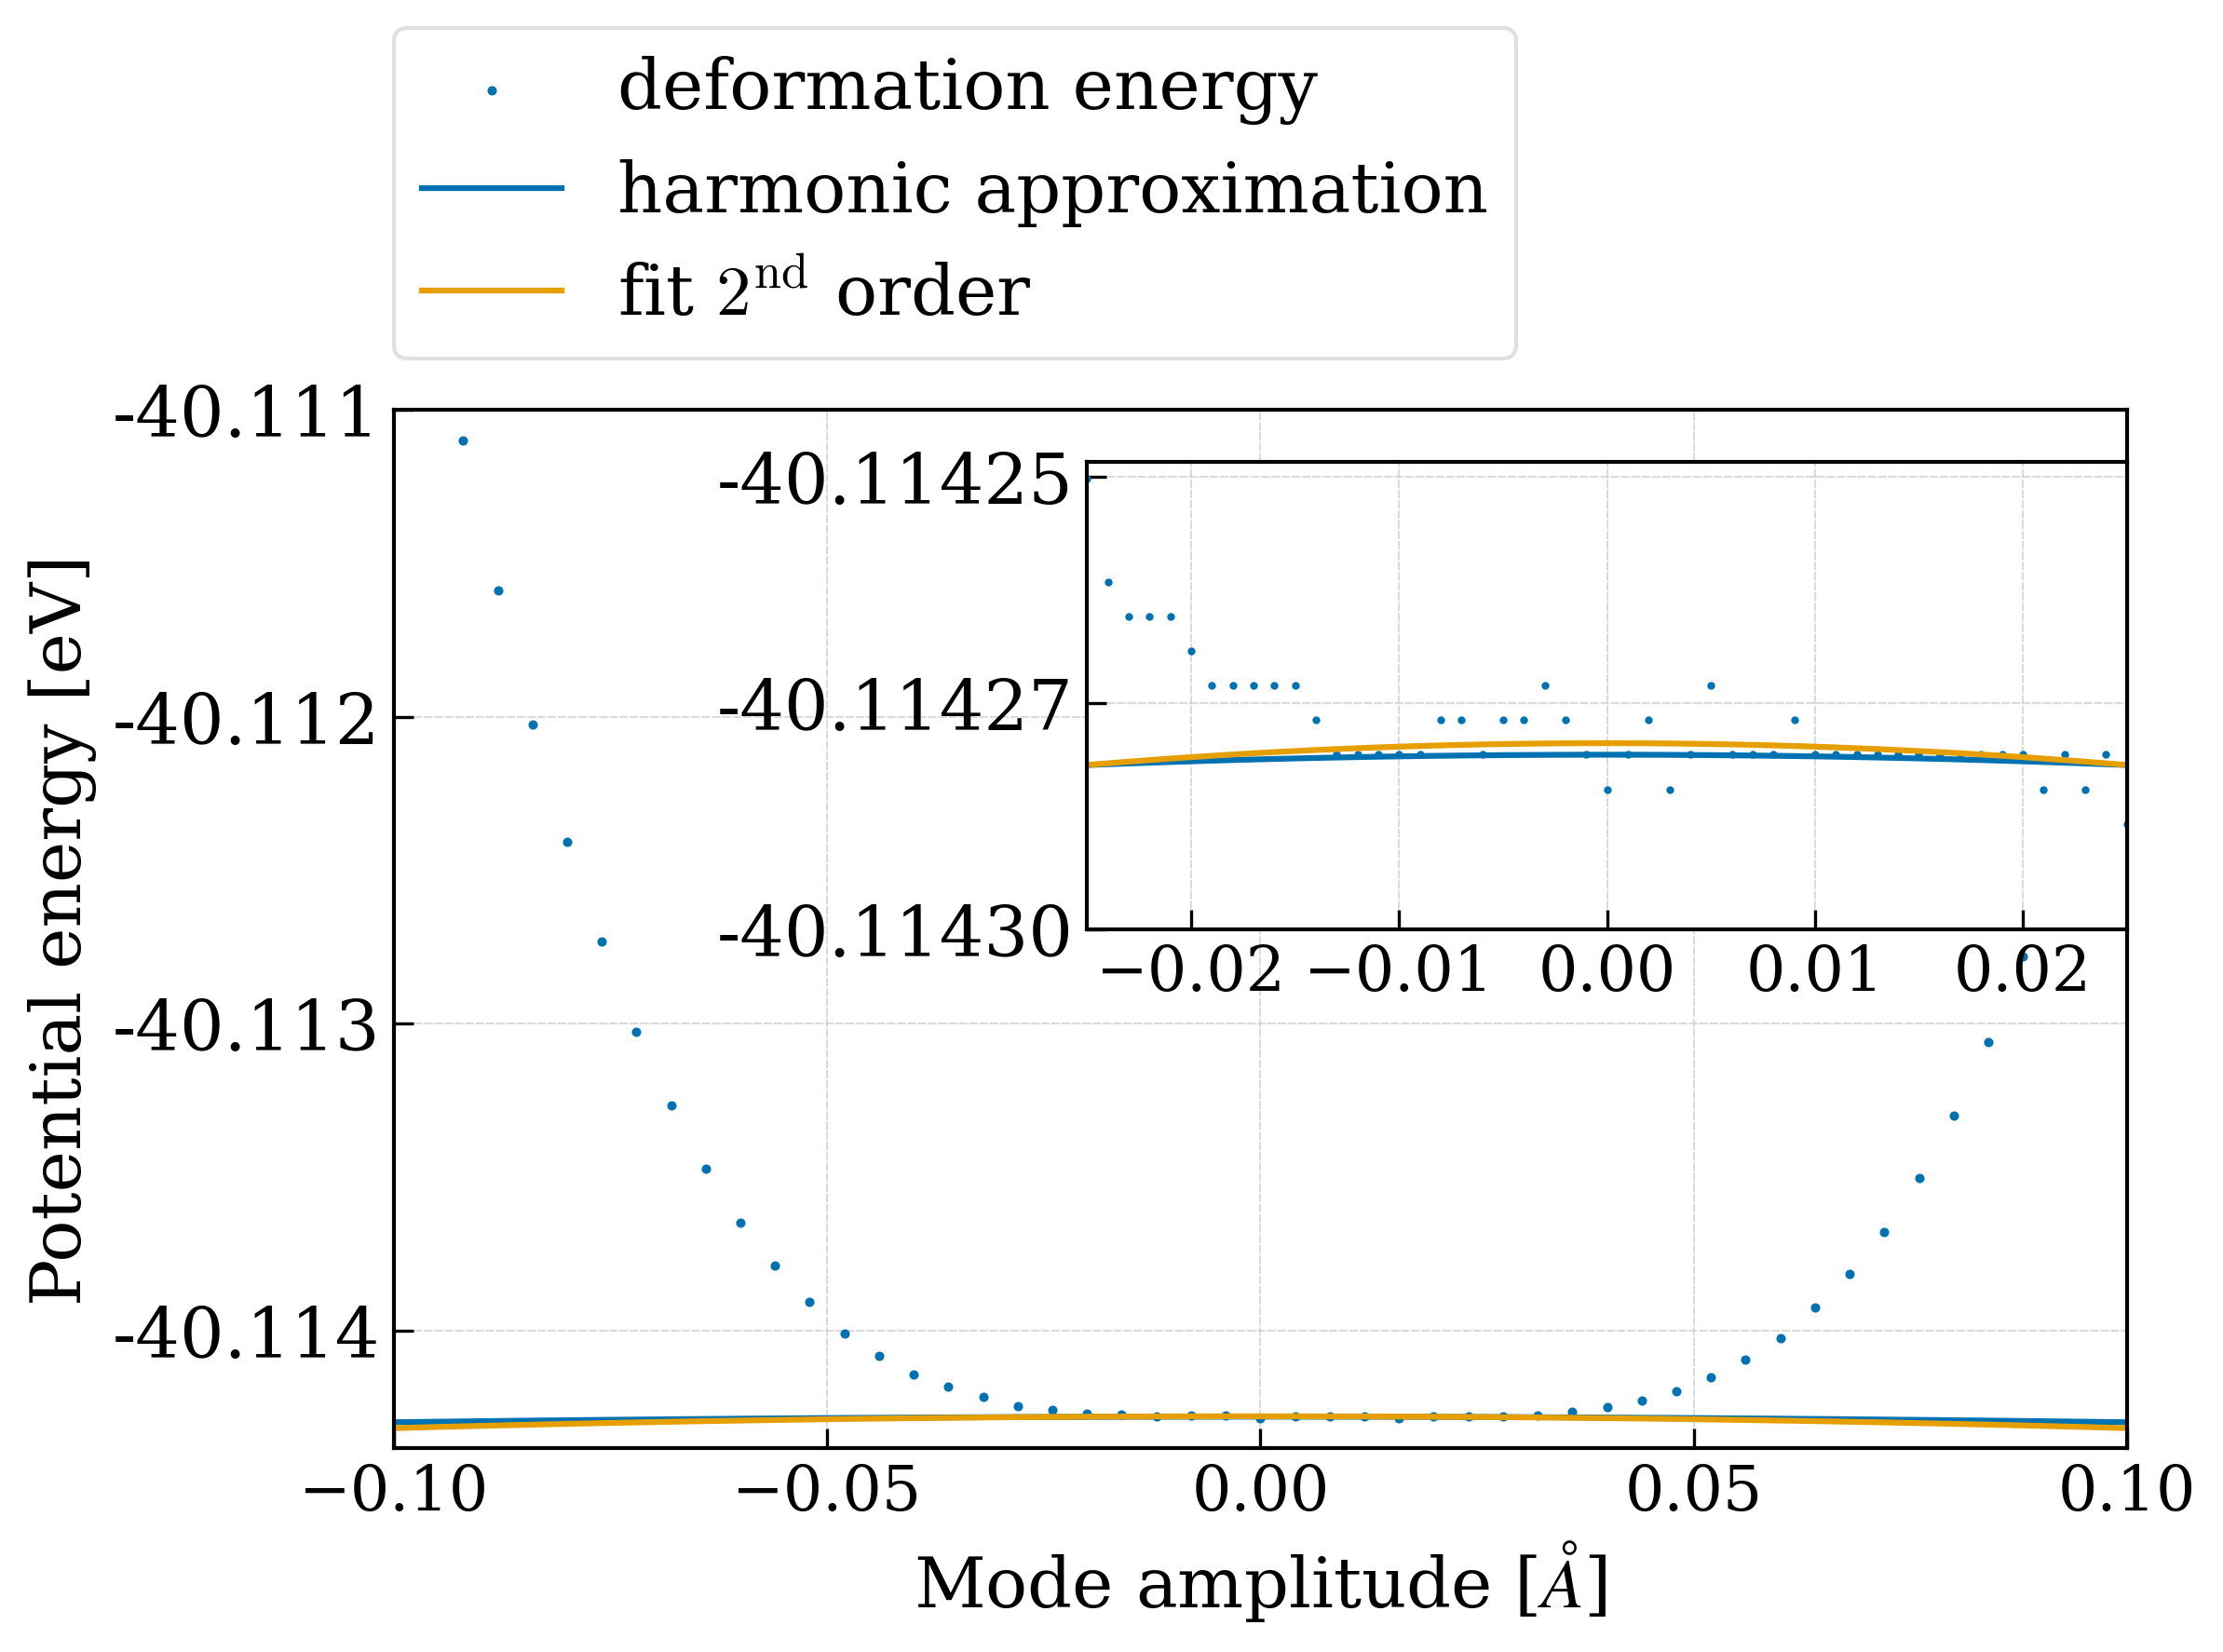

In [94]:
fig, ax = plt.subplots(1, 1, figsize = (8, 6))
energies_zoomed = np.array(energies_zoomed)

ax.scatter(mode_amplitudes, energies, label = "deformation energy", s = 2)
ax.plot(mode_amplitudes, harmonic_energies, label = "harmonic approximation")

inset_ax = ax.inset_axes((0.4, 0.5, 0.60, 0.45))
inset_ax.set_xlim(-0.025, 0.025)
inset_ax.scatter(mode_amplitudes_zoomed, energies_zoomed, s = 1)
inset_ax.plot(mode_amplitudes_zoomed, harmonic_energies_zoomed)

coeffs, covar = ploy4fit(mode_amplitudes_zoomed, energies_zoomed, window_size=101)
fitted_parabola_zoom = coeffs[-1] + coeffs[-3] * mode_amplitudes_zoomed**2
third_order = coeffs[-1] + coeffs[-4] * mode_amplitudes_zoomed**3
fourth_order = coeffs[-1] + coeffs[-5] * mode_amplitudes_zoomed**4
fit=poly1d(coeffs)
inset_ax.plot(mode_amplitudes_zoomed, fitted_parabola_zoom, label = r"fit $2^{\text{nd}}$ order")
# inset_ax.plot(mode_amplitudes_zoomed, third_order, label = r"$3^{rd}$ order")
# inset_ax.plot(mode_amplitudes_zoomed, fourth_order, label = r"$4^{th}$ order")
# inset_ax.plot(mode_amplitudes_zoomed, fit(mode_amplitudes_zoomed), label = r"fit")
# inset_ax.legend()

fitted_parabola = coeffs[-1] + coeffs[-3] * mode_amplitudes**2
ax.plot(mode_amplitudes, fitted_parabola, label = r"fit $2^{\text{nd}}$ order")

print(0.5 * mass * w2)
print(coeffs[-3], covar[-3, -3]*2)

inset_ylim = np.min(energies_zoomed)-1e-5, np.min(energies_zoomed)+4e-5
inset_ax.set_ylim(inset_ylim)
inset_yticks = np.linspace(-40.11430, -40.11425, 3)
inset_ax.set_yticks(inset_yticks)
inset_ax.set_yticklabels([f"{tick:.5f}" for tick in inset_yticks])


ax.legend(loc = (0, 1.05))
ax.set_xlabel(r"Mode amplitude [$\AA$]")
ax.set_ylabel(r"Potential energy [eV]")

mine = np.min(energies)

ymin, ymax = np.min(energies)-1e-4, np.min(energies)+3e-3
ax.set_ylim(ymin, ymax)
yticks = np.linspace(-40.114, -40.111, 4)
ax.set_yticks(yticks)
ax.set_xticks(np.linspace(-0.1, 0.1, 5))
ax.set_yticklabels([f"{yt:.3f}" for yt in yticks])

ax.set_xlim(-0.1, 0.1)

plt.tight_layout()

plt.savefig("MF_deformation_vs_harmonic.pdf")

In [383]:
view(phonon_mode, viewer="ngl")

In [17]:
strains = np.linspace(0.16, 0.3, 30)
strains_tensors = [np.array([
    [s, 0, 0],
    [0, 0, 0],
    [0, 0, 0]
]) for s in strains]
id = np.eye(3)
deformations = [id + s for s in strains_tensors]

In [18]:
def stress_strain(strain_template, atoms, strains=np.linspace(0.15, 0.30), supercell = (1,1,1), color = "blue"):

    cell0 = atoms.cell.copy()
    strains_tensors = [strain_template * s for s in strains]
    id = np.eye(3)
    deformations = [id + s for s in strains_tensors]

    stresses = []
    energies = []
    traj = []

    for deform in tqdm(deformations):
        cell = cell0 @ deform
        strained_atoms = atoms.copy()
        strained_atoms = strained_atoms.repeat(supercell)
        strained_atoms.set_cell(cell, scale_atoms=True)
        strained_atoms.pbc = (True, True, True)
        strained_atoms.calc = model
        perturbations = np.random.normal(0, 5e-3, size=(len(strained_atoms),3))
        # perturbations = np.ones(shape=(len(strained_atoms),3)) * 2.5e-3
        # signs = np.random.choice([-1, 1], size=(len(strained_atoms),3))
        # perturbations *= signs
        perturbations[:,2] = 0
        strained_atoms.positions += perturbations
        opt = BFGS(strained_atoms, logfile=None)
        opt.run(fmax = 1e-4)

        stress = strained_atoms.get_stress()
        energy = strained_atoms.get_potential_energy()
        energies.append(energy)
        stresses.append(stress)
        traj.append(strained_atoms)

    # Apply your scaling factor to the raw stress array
    stresses = (np.array(stresses) * cell0[2,2])
    
    # Combined stress for plotting
    y_values = stresses[:,0] + stresses[:,1]
    
    plt.scatter(strains, y_values, color = color)
    
    maxi = np.argmax(y_values)
    maxstrain = strains[maxi]
    # Scaling the displayed max stress by sqrt(2) per your label request
    max_val_label = y_values[maxi]
    
    plt.scatter(maxstrain, y_values[maxi], marker = "x", color = color, 
                label = f"max strain {maxstrain:.3f}\nmax $(\sigma_{{xx}} + \sigma_{{yy}}) L_{{z}}$: {max_val_label:.3f}")

    plt.legend()
    plt.xlabel(r"Strain Amplitude $(\epsilon_{xx} + \epsilon_{yy})/\sqrt{2}$")
    plt.ylabel(r"Planar Stress $(\sigma_{xx} + \sigma_{yy}) L_{z}$ [eV/Å$^2$]")
    plt.grid(True)
    plt.show()

    plt.scatter(strains, energies)
    plt.ylabel("energ [eV]")
    plt.show()

    return y_values, energies, traj

<>:48: SyntaxWarning: invalid escape sequence '\s'


In [19]:
STRAINXX = np.array(([1,0,0], [0,0,0], [0,0,0]))
STRAINYY = np.array(([0,0,0], [0,1,0], [0,0,0]))
STRAINEQUI = (STRAINXX + STRAINYY) / np.sqrt(2)

100%|██████████| 100/100 [00:21<00:00,  4.66it/s]


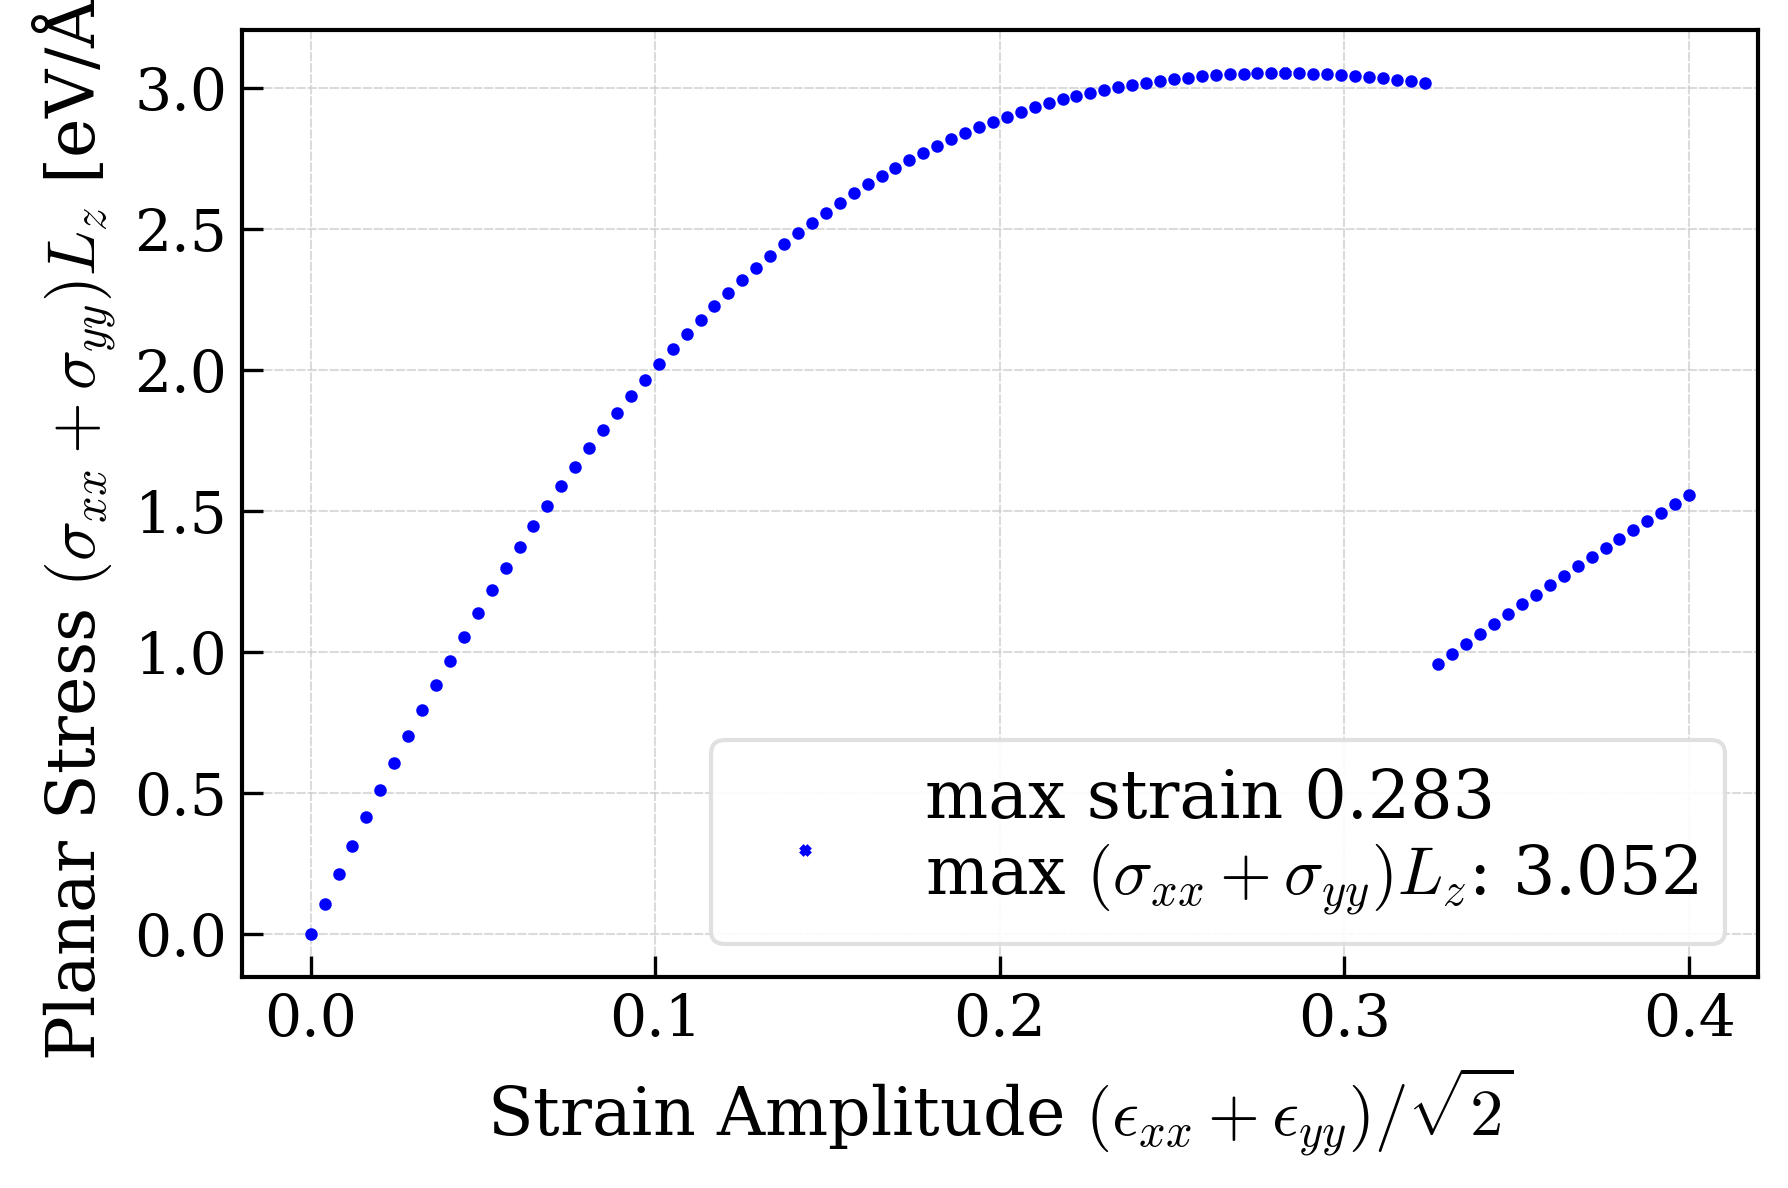

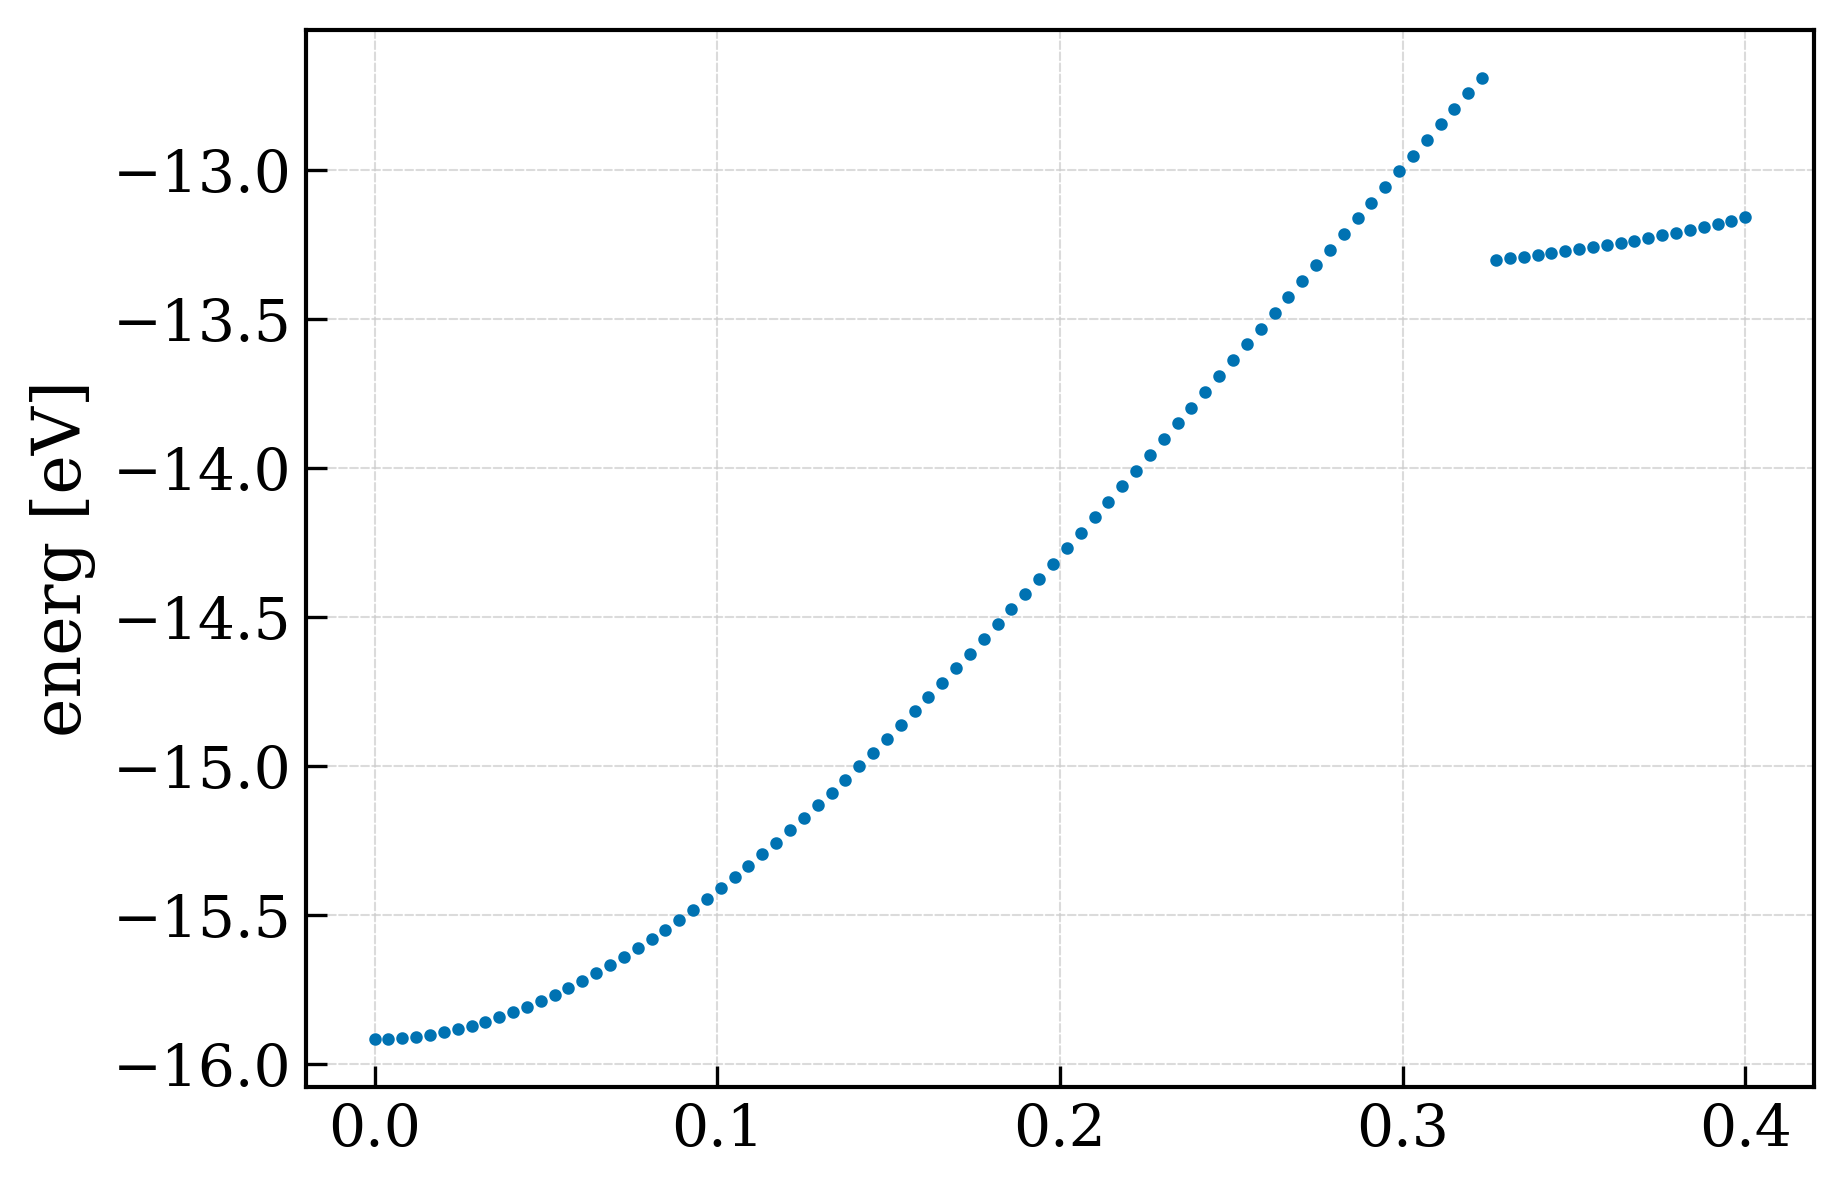

In [387]:
stresses, energies, traj = stress_strain(STRAINYY, primitive, strains = np.linspace(0, 0.4, 100));

In [388]:
view([a.repeat((3,3,1)) for a in traj], viewer = "ngl")

In [389]:
stresses, energies, traj = stress_strain(STRAINYY, primitive.repeat((3, 3, 1)), strains = np.linspace(0, 0.4, 100));

 72%|███████▏  | 72/100 [02:42<01:03,  2.25s/it]


KeyboardInterrupt: 

In [ ]:
view([a.repeat((3,3,1)) for a in traj], viewer = "ngl")

100%|██████████| 50/50 [00:22<00:00,  2.19it/s]


array([2.56228395, 2.58853877, 2.61394327, 2.63850785, 2.6622377 ,
       2.68513983, 2.70721671, 2.72847991, 2.74893226, 2.76858633,
       2.78744325, 2.80551892, 2.82281475, 2.83934818, 2.85512701,
       2.87016736, 2.8844773 , 2.89807322, 2.91097058, 2.92318818,
       2.93473321, 2.94563574, 2.95590121, 2.96556013, 2.97462266,
       2.9831032 , 2.99102248, 2.99839234, 3.00523923, 3.0115619 ,
       3.01737806, 3.02270275, 3.02755877, 3.03193938, 3.03587618,
       3.03935889, 3.04241059, 3.0450454 , 3.0472547 , 3.04905913,
       3.05045703, 3.0514514 , 3.0520588 , 3.05226905, 3.05208717,
       3.05139074, 0.96533774, 0.86667954, 0.78060315, 0.7050841 ])

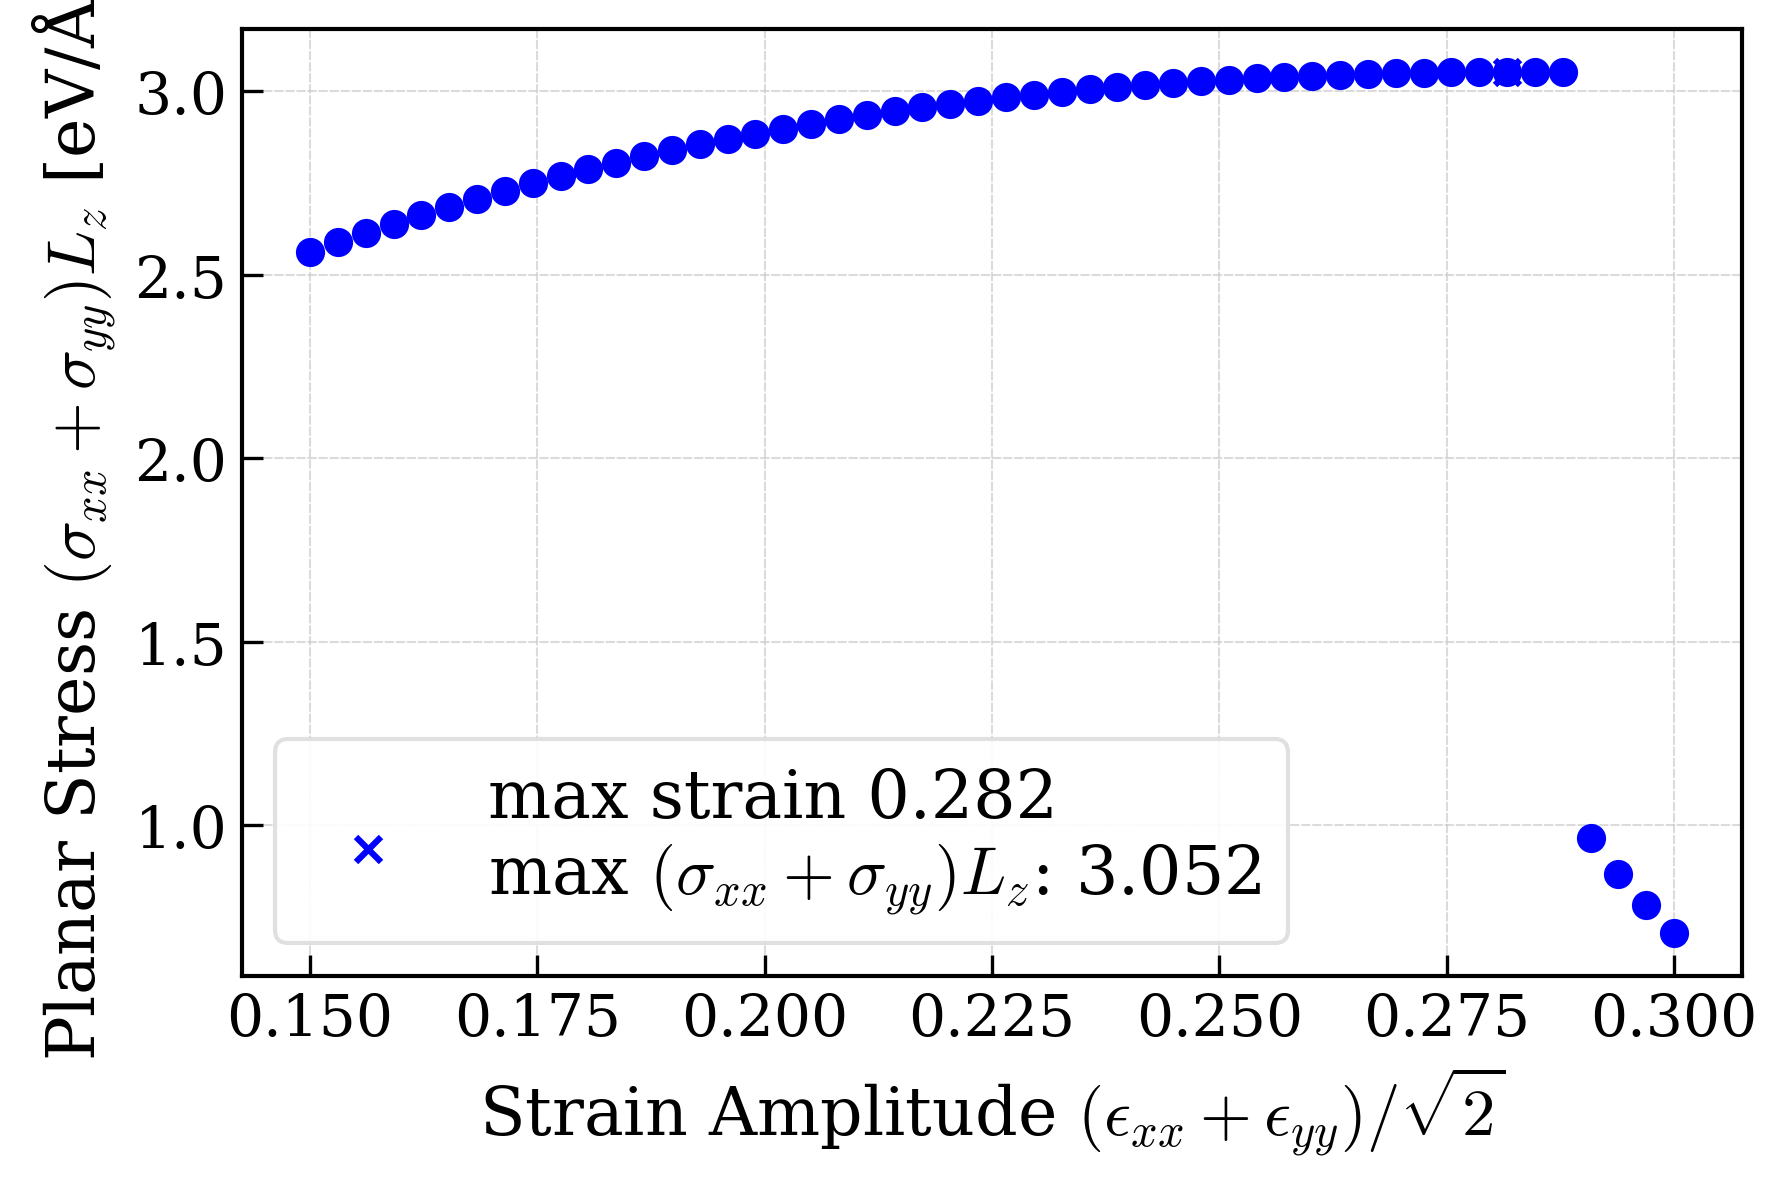

In [ ]:
stress_strain(STRAINYY, katoms)

100%|██████████| 150/150 [00:13<00:00, 10.96it/s]


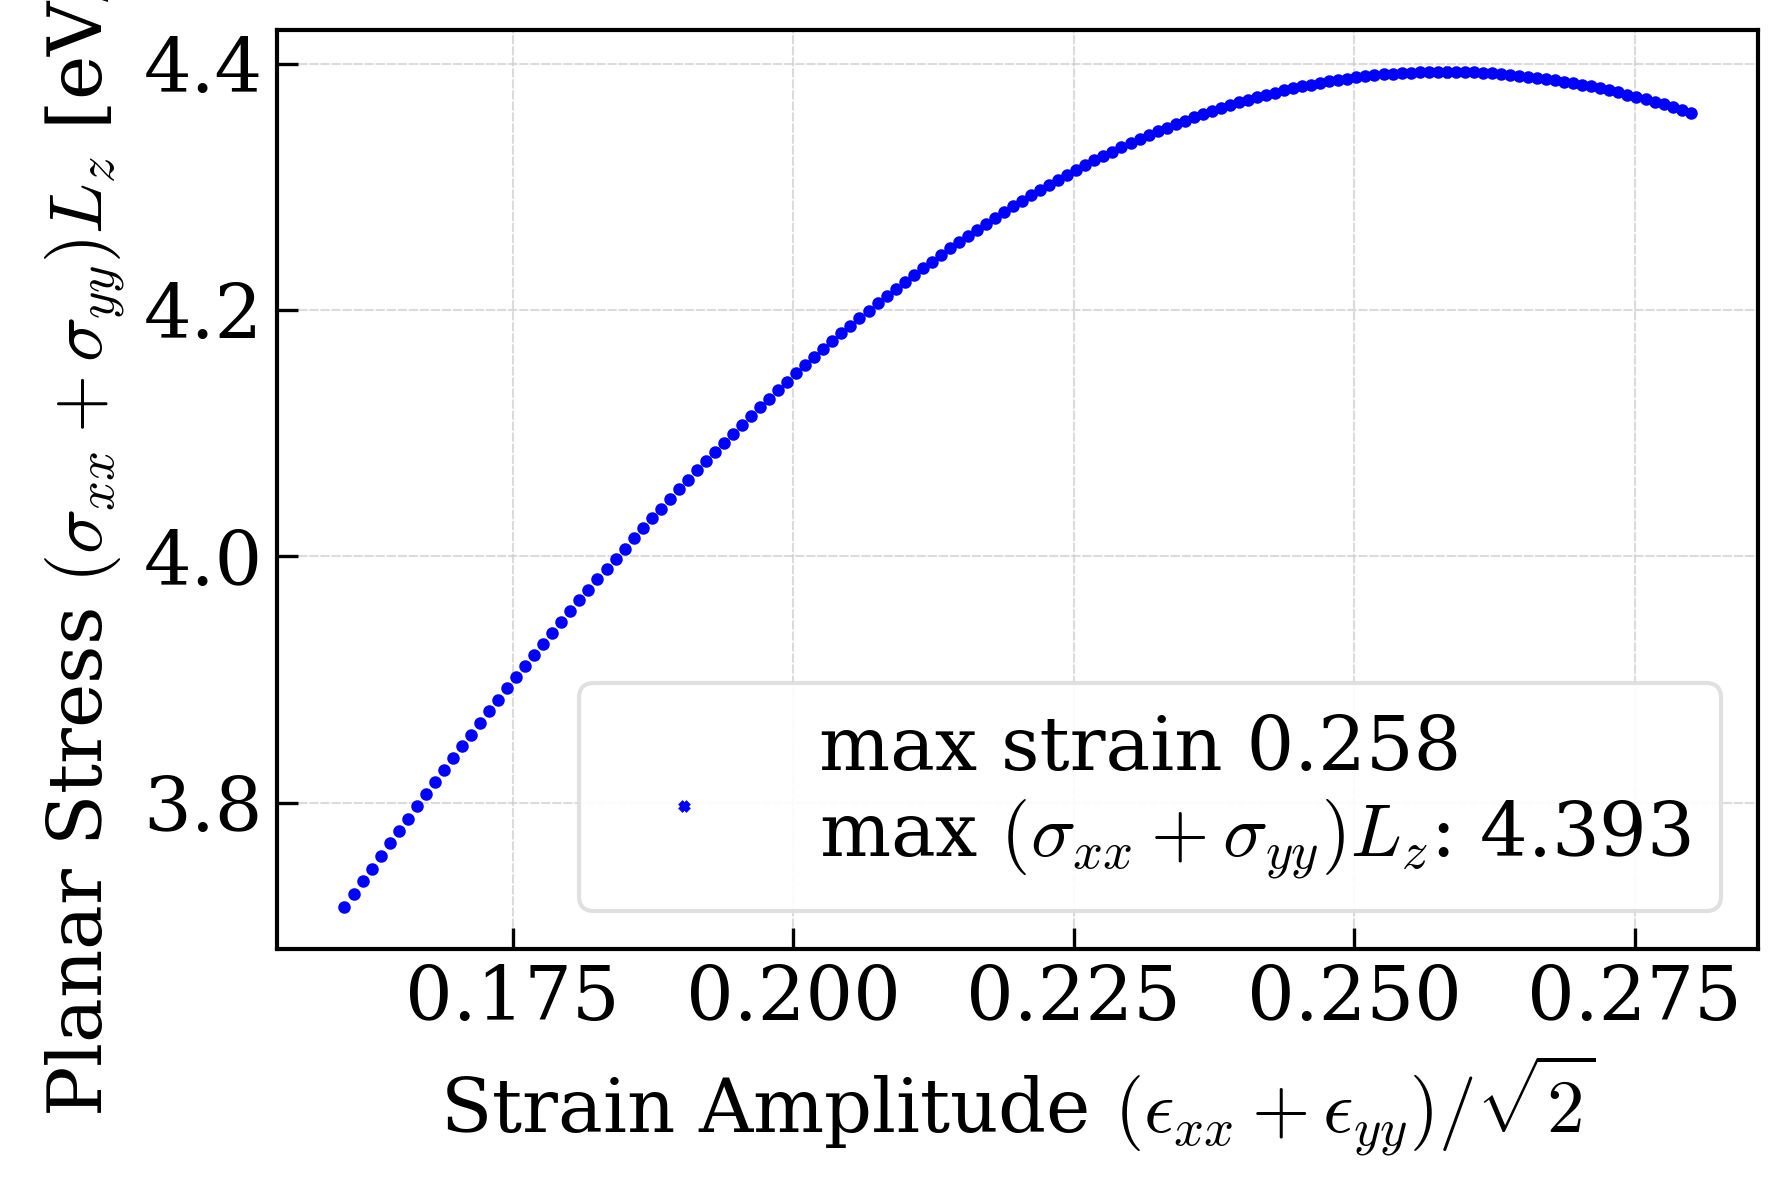

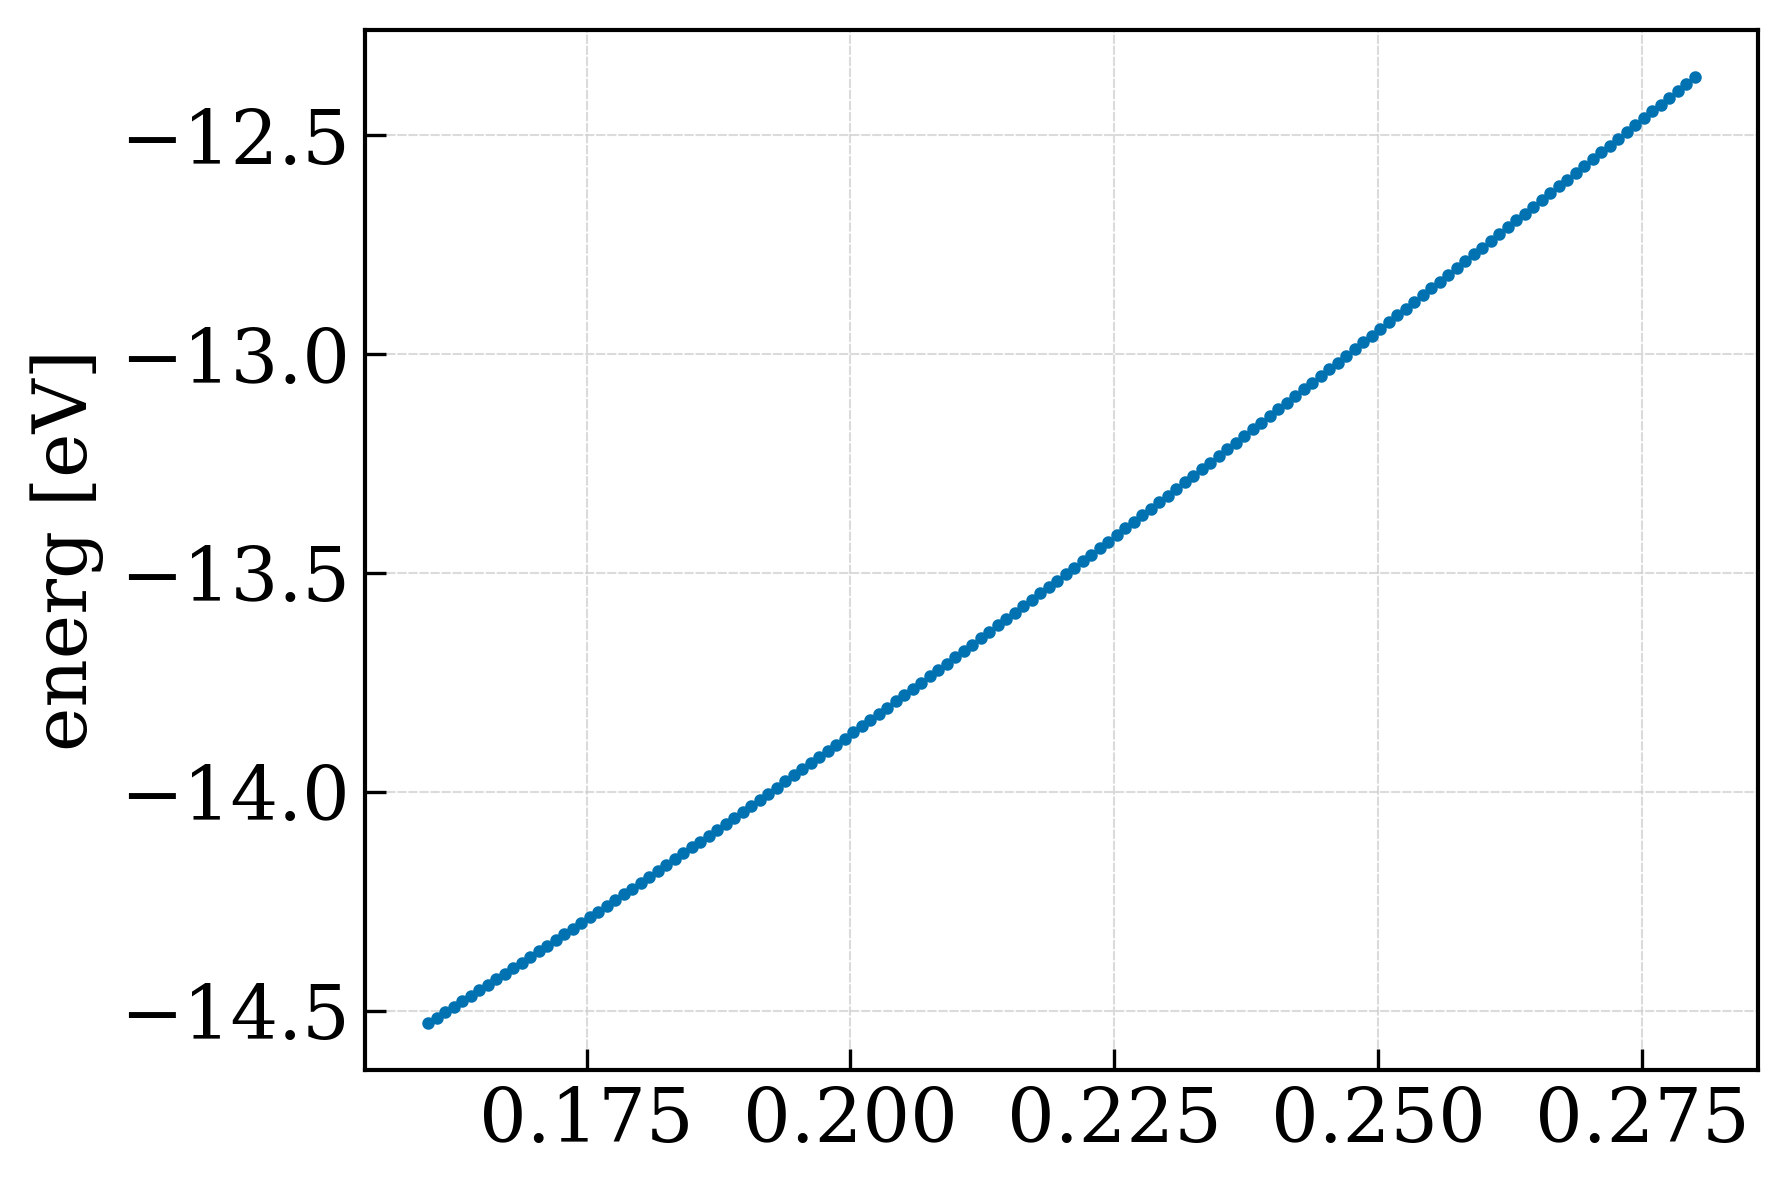

In [20]:
primitive_equi = stress_strain(STRAINEQUI, primitive, np.linspace(0.16, 0.28, 150))

100%|██████████| 150/150 [01:48<00:00,  1.39it/s]


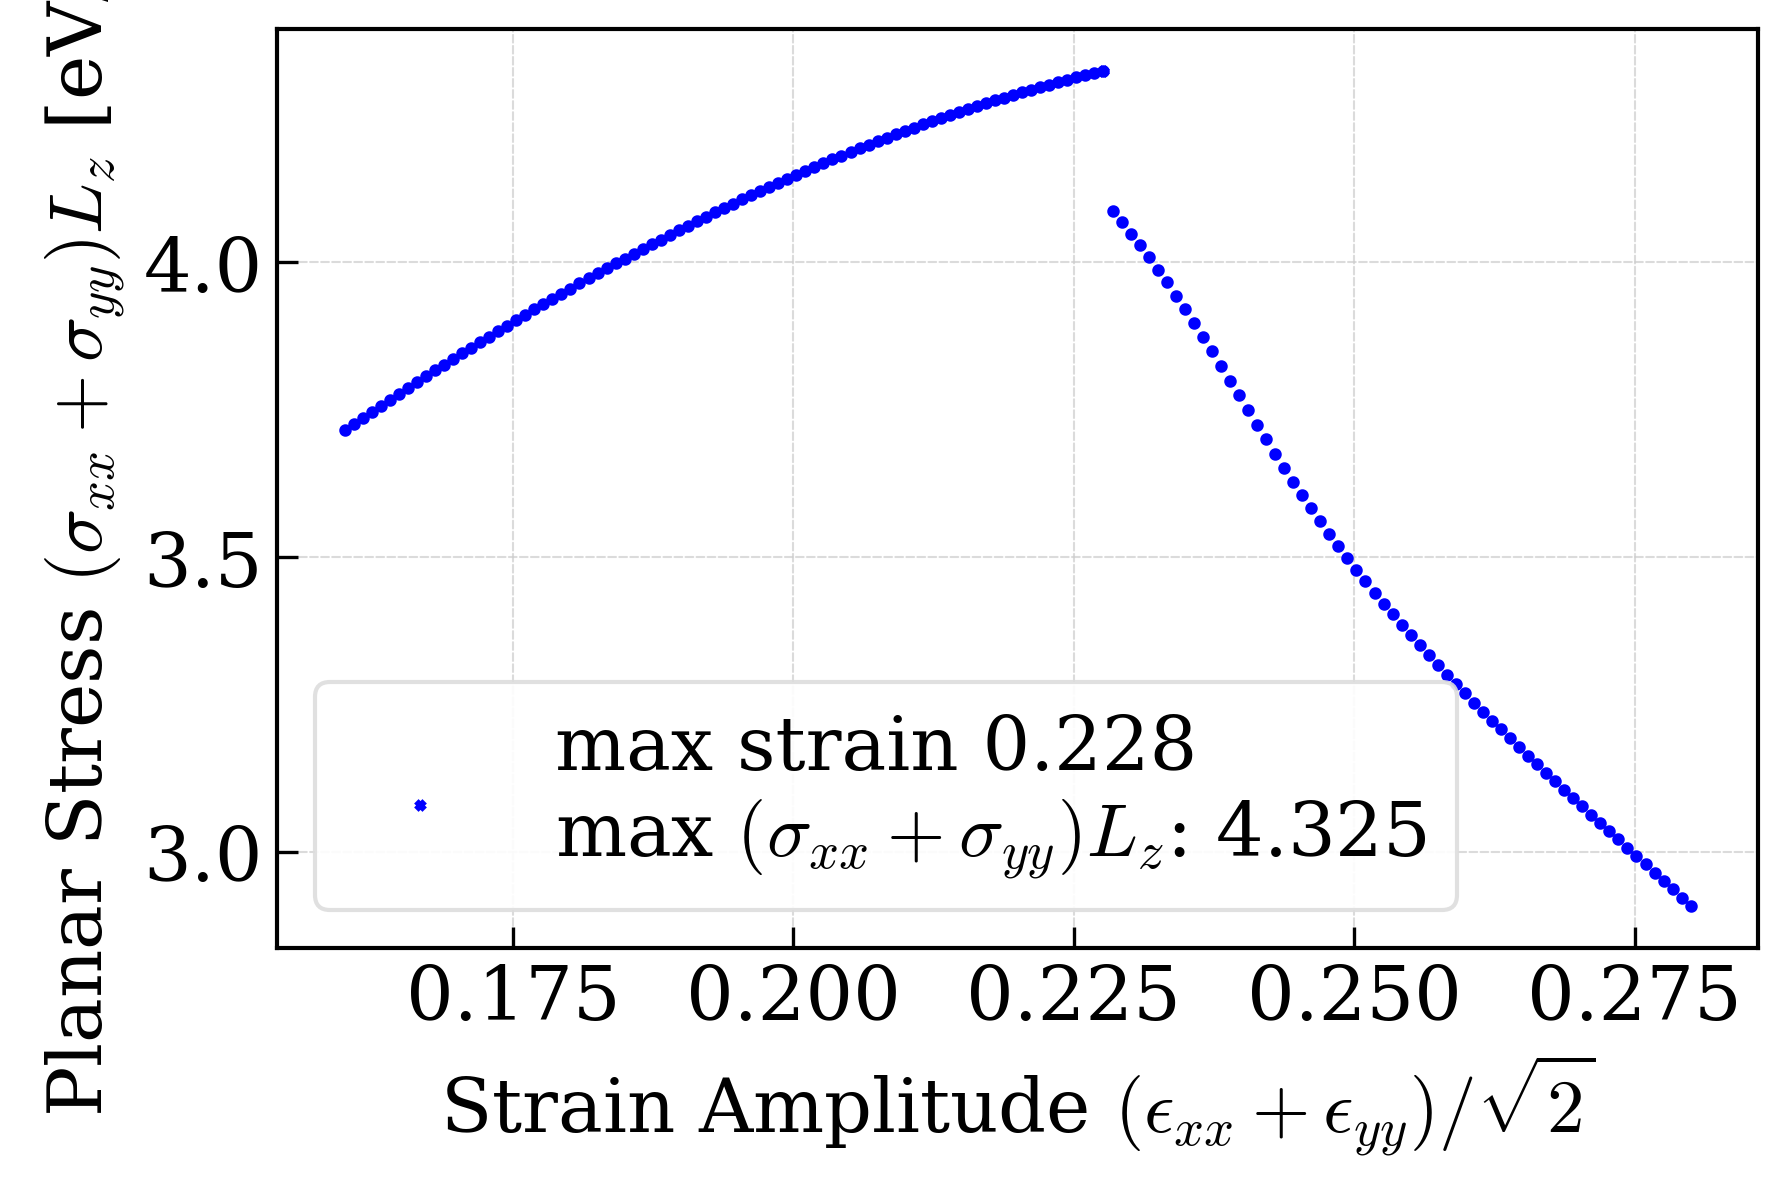

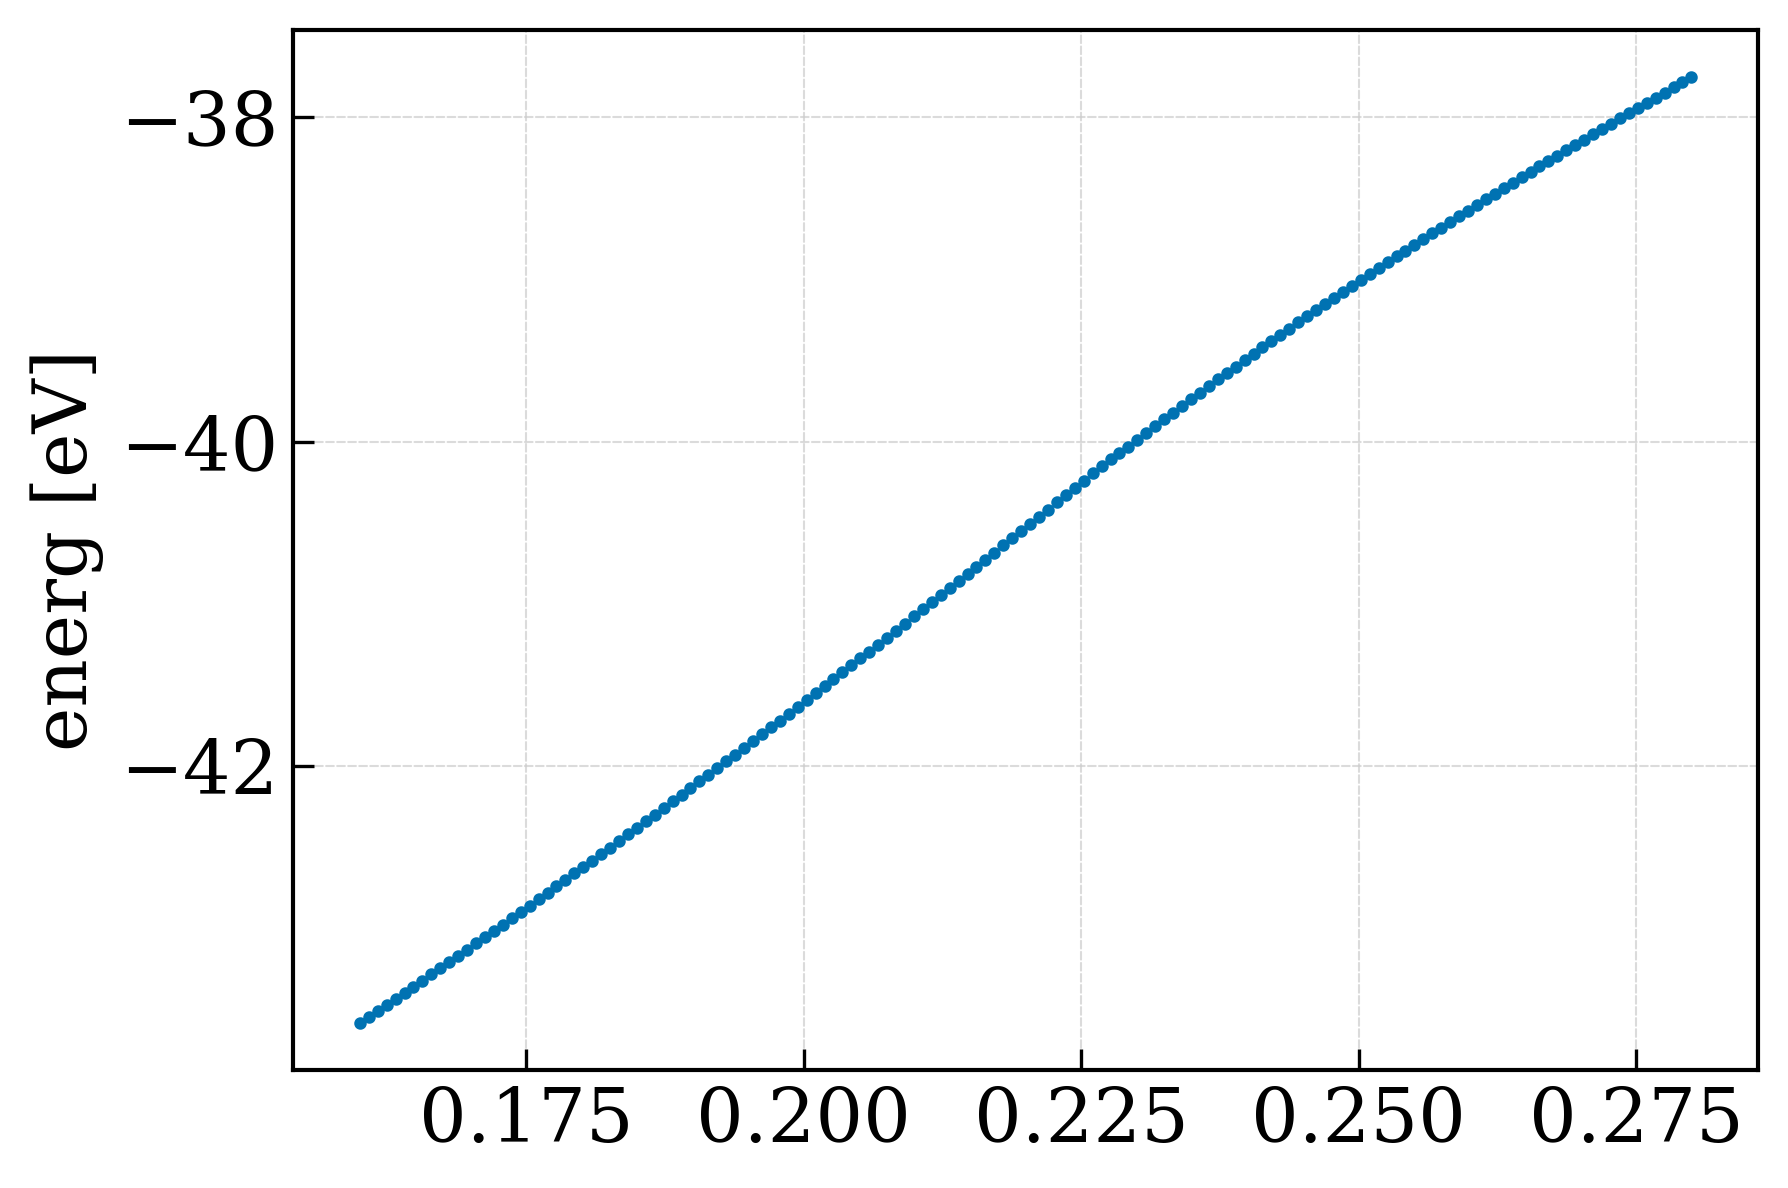

In [21]:
kcell_equi = stress_strain(STRAINEQUI, katoms, np.linspace(0.16, 0.28, 150))

100%|██████████| 30/30 [00:02<00:00, 10.10it/s]


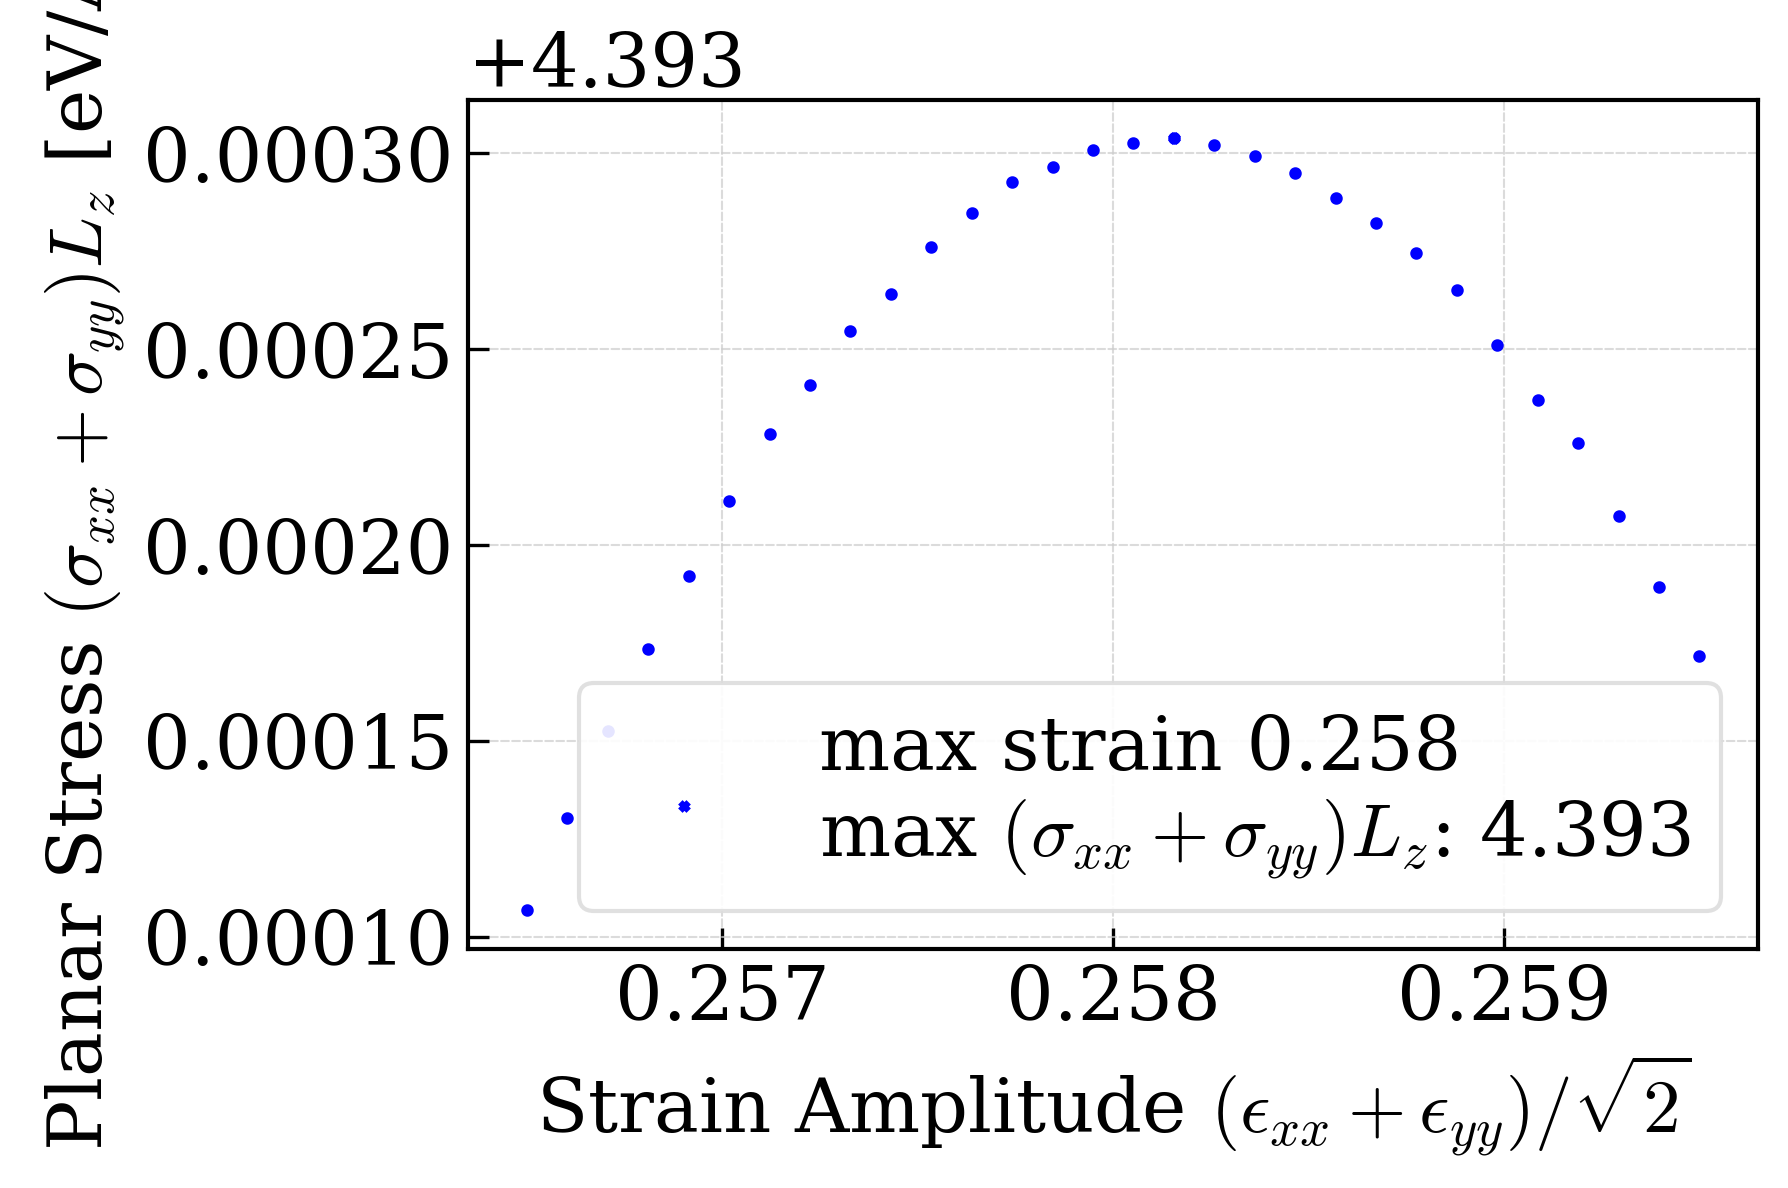

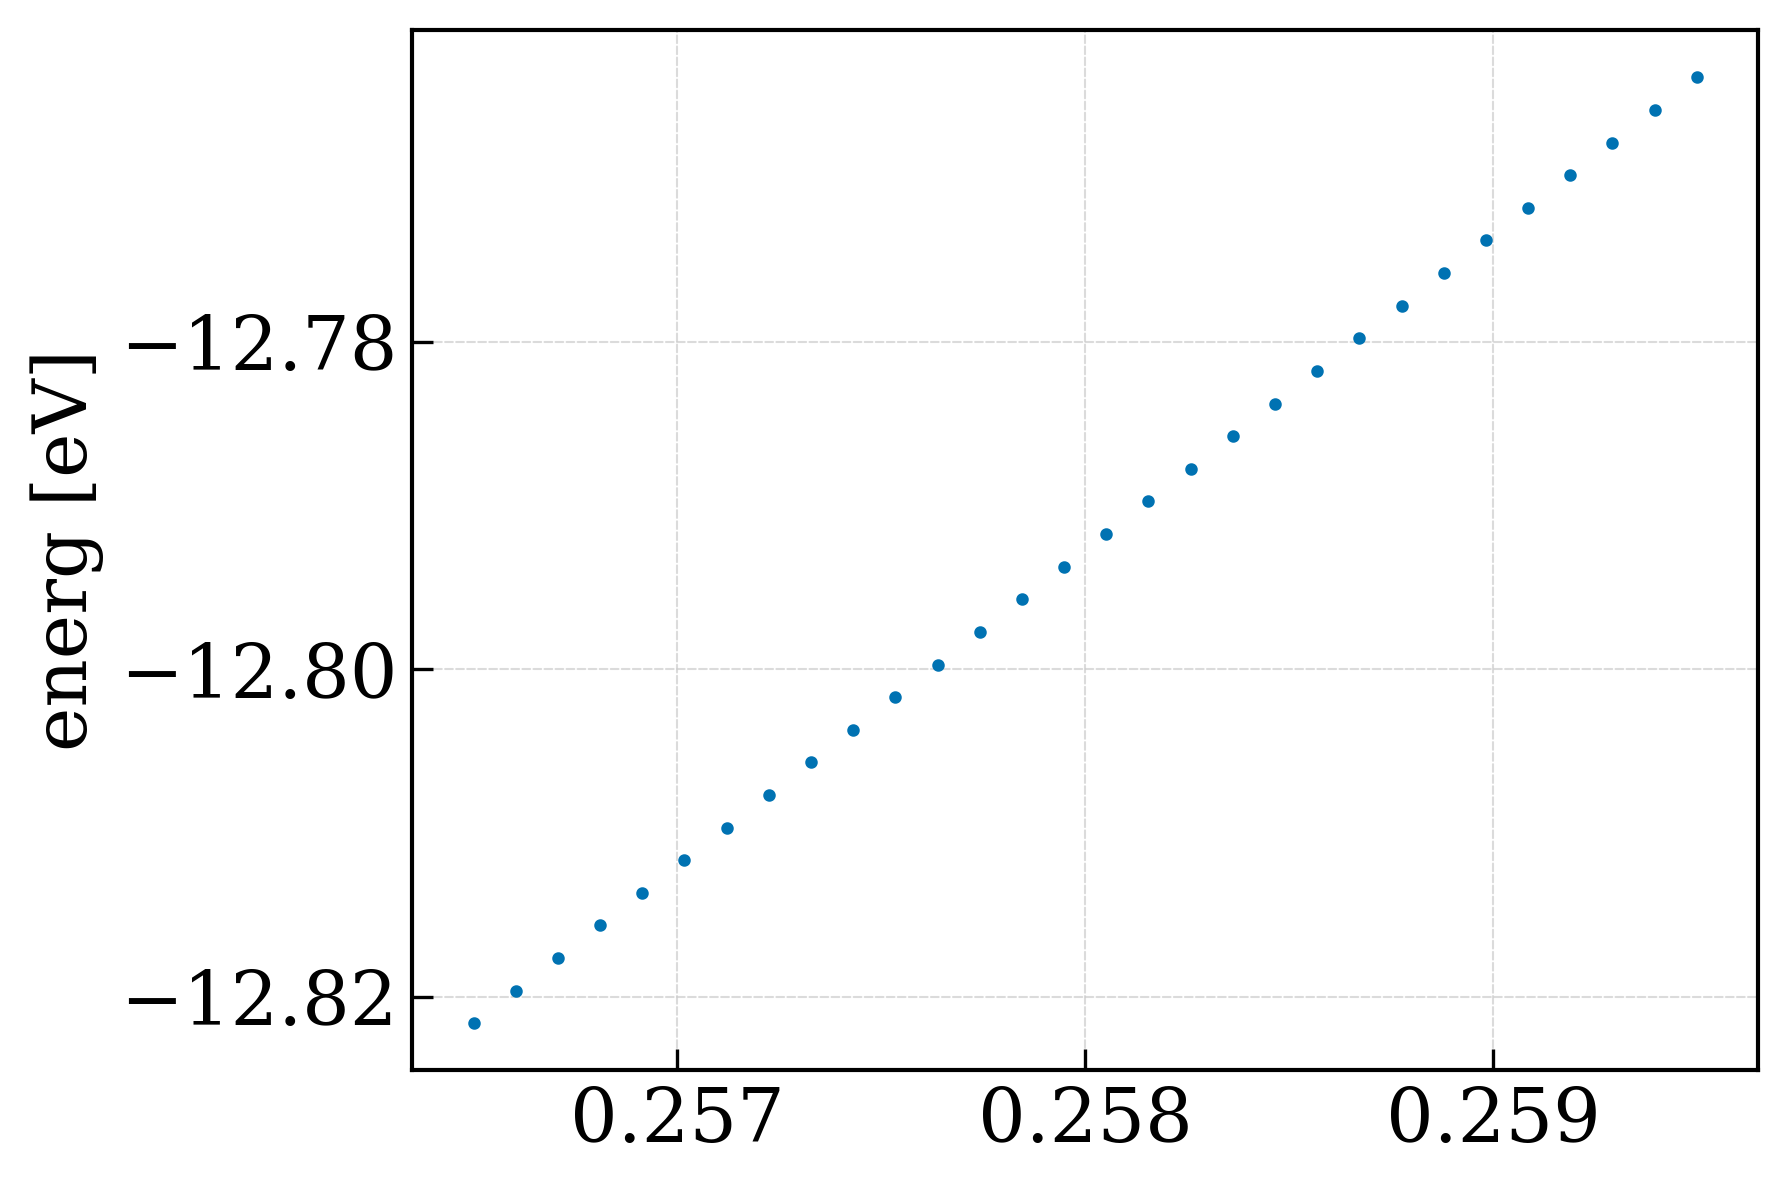

In [22]:
primitive_zoom = stress_strain(STRAINEQUI, primitive, np.linspace(0.2565, 0.2595, 30))

100%|██████████| 30/30 [00:19<00:00,  1.58it/s]


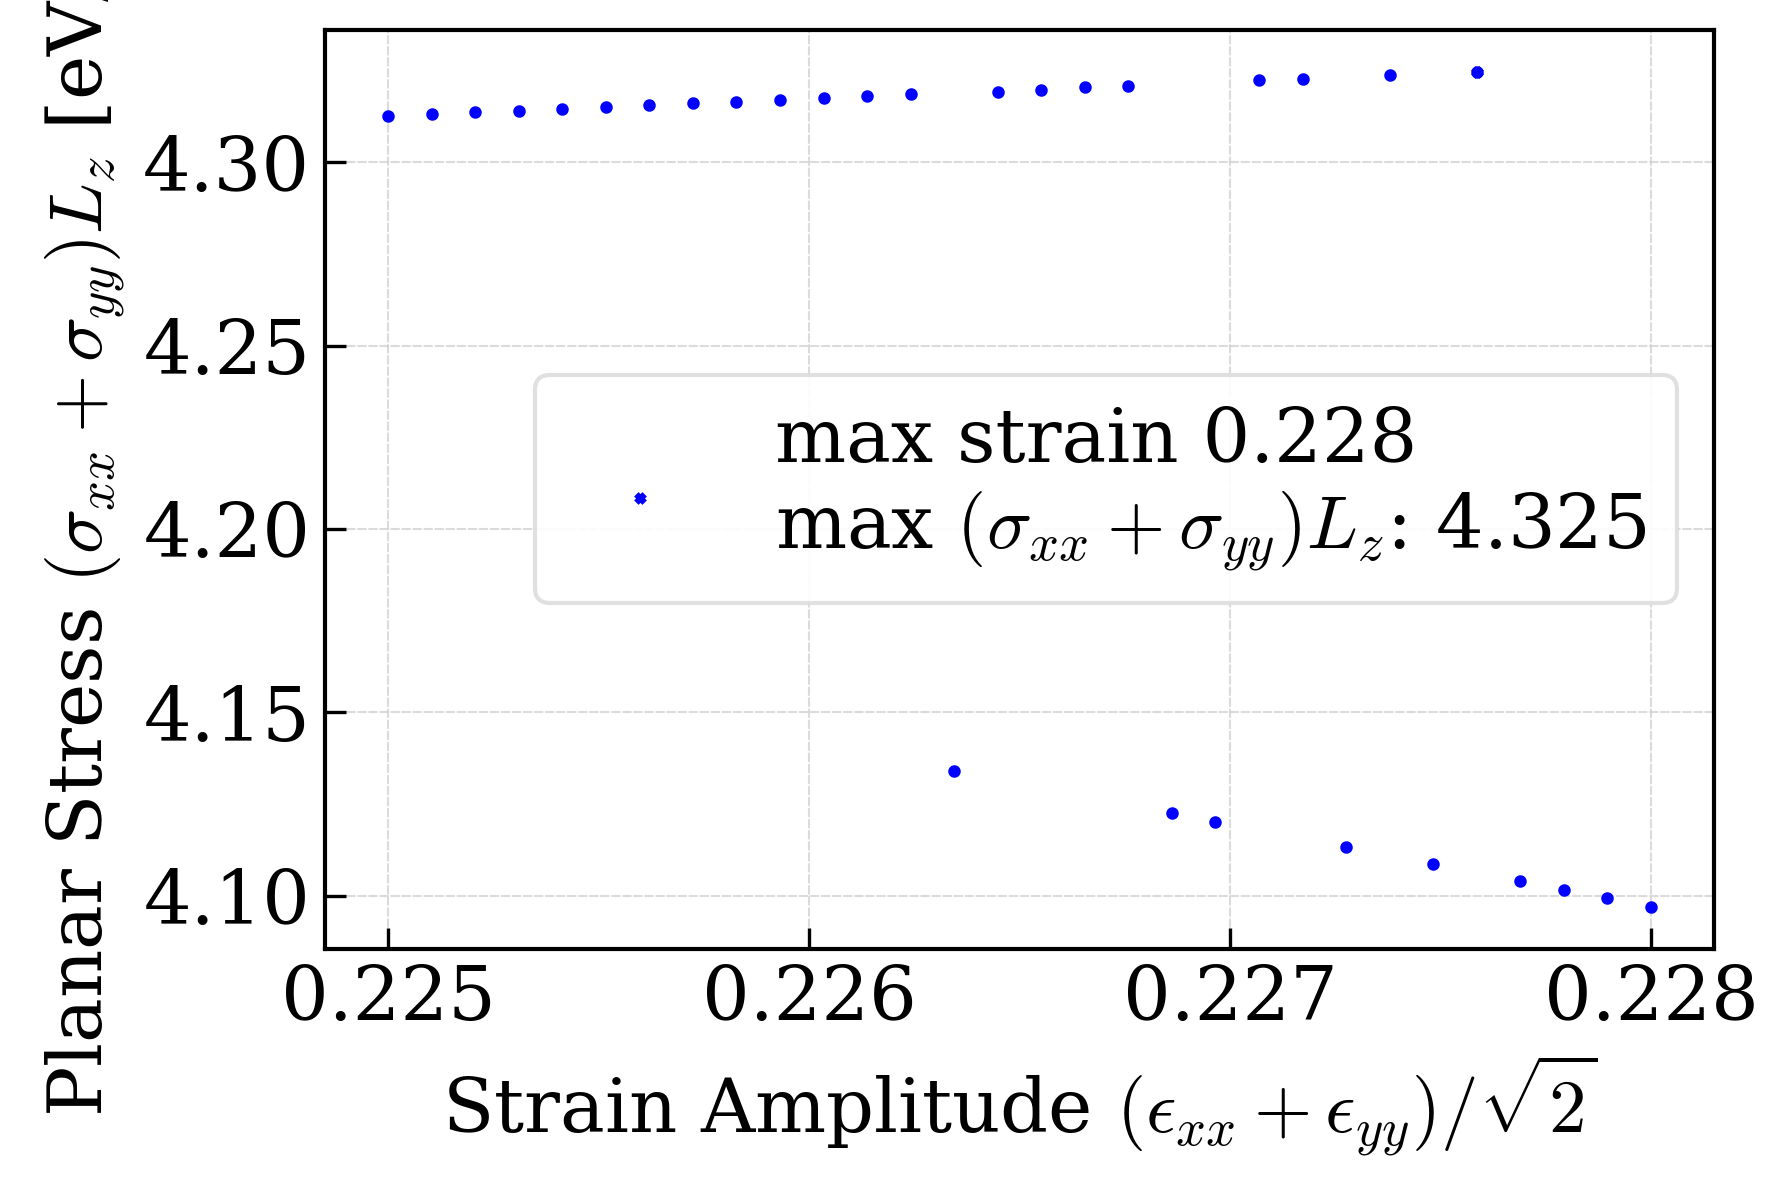

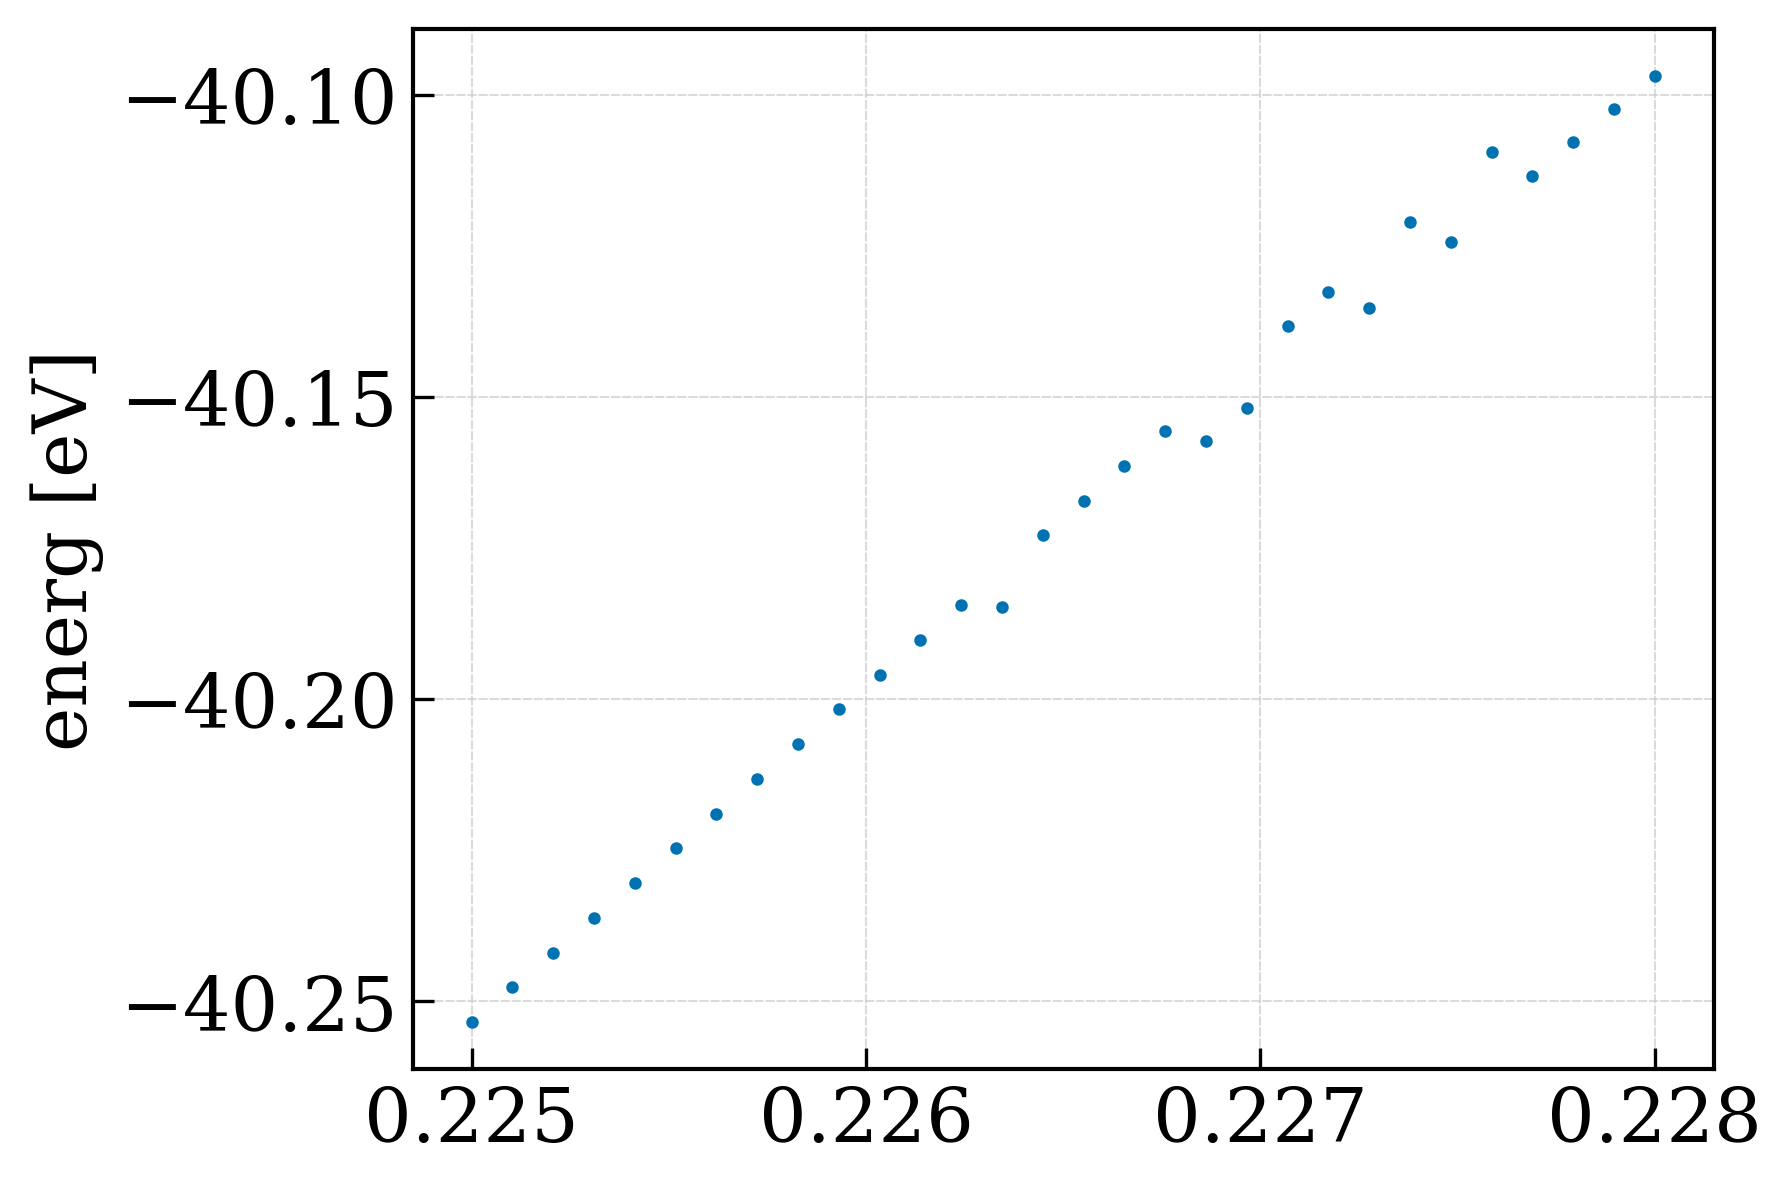

In [23]:
kcell_zoom = stress_strain(STRAINEQUI, katoms, np.linspace(0.225, 0.228, 30))

In [24]:
primitive_equi = primitive_equi[0]
kcell_equi = kcell_equi[0]

kcell_zoom = kcell_zoom[0]
primitive_zoom = primitive_zoom[0]

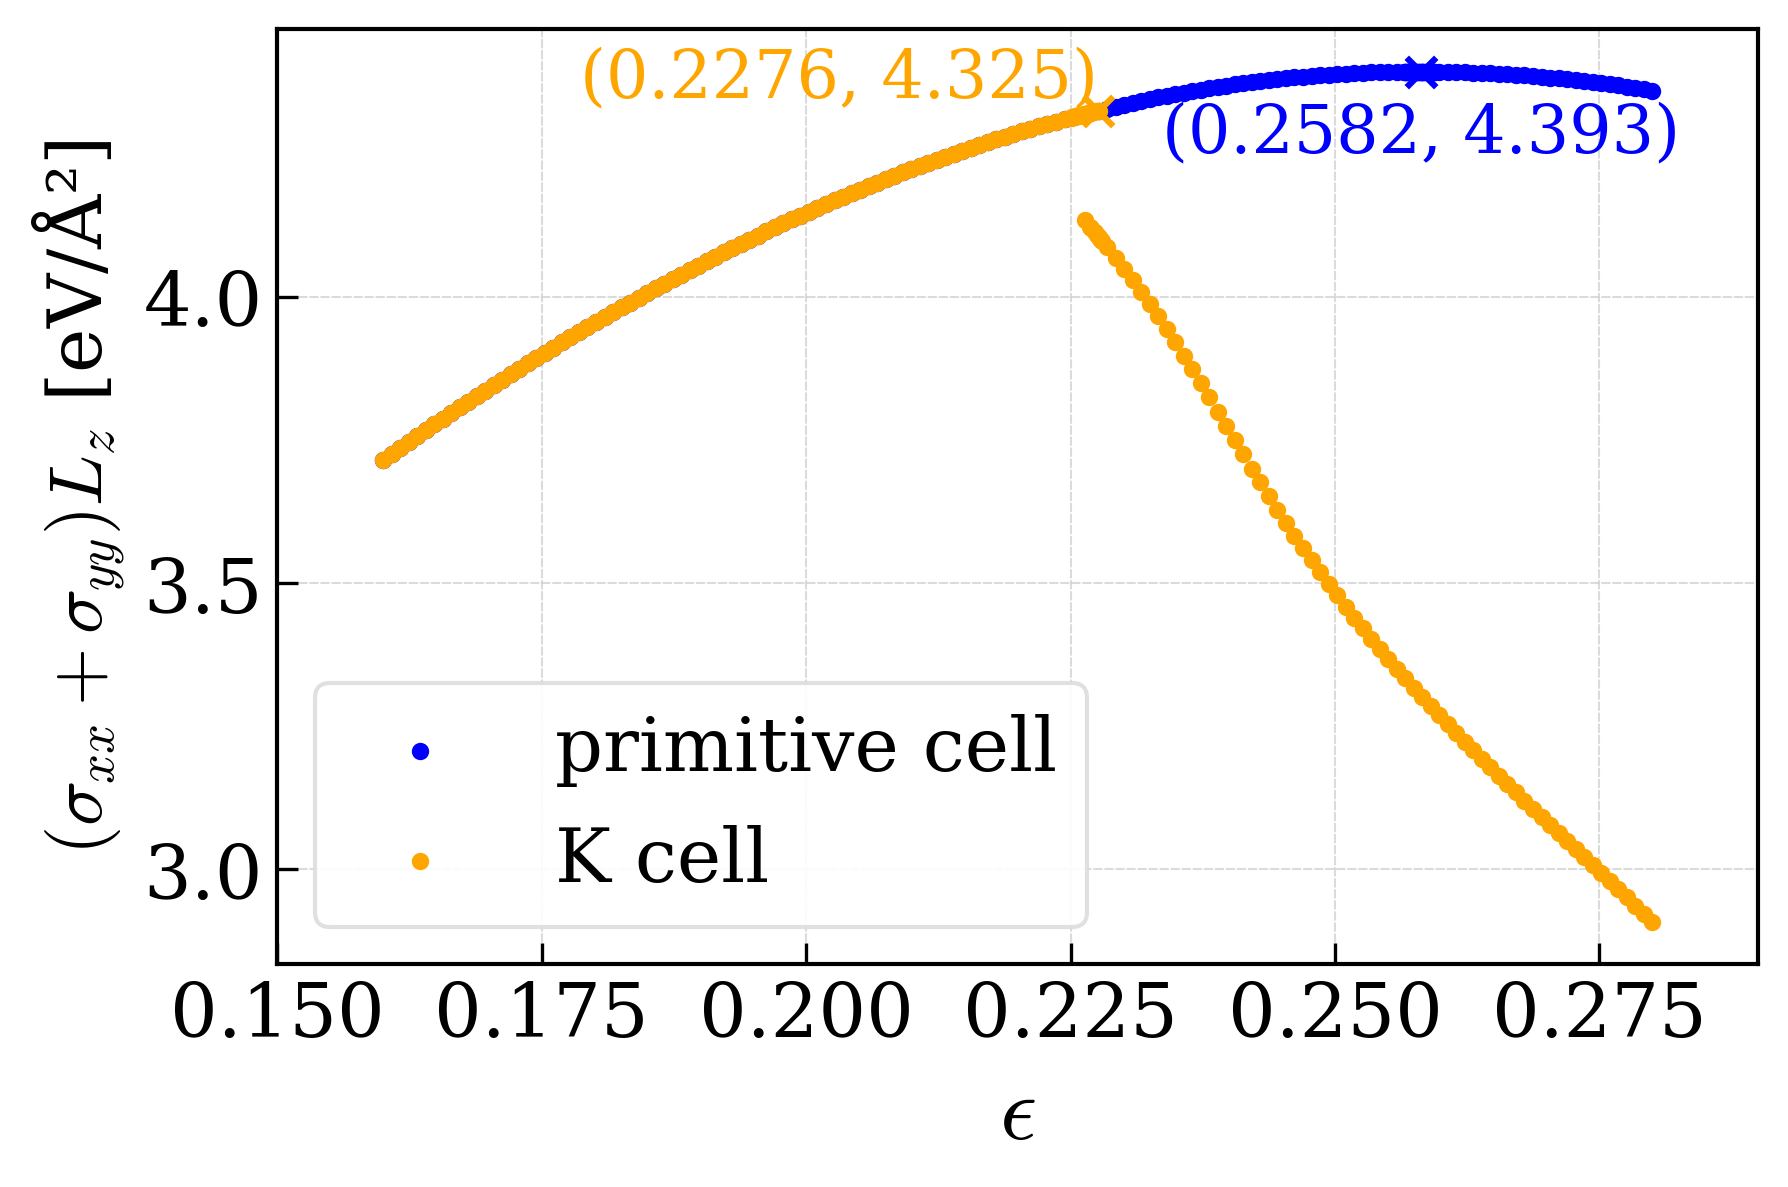

In [25]:
strains = np.linspace(0.16, 0.28, 150)
plt.scatter(strains, primitive_equi, label = "primitive cell", color = "blue", s=10)
plt.scatter(strains, kcell_equi, label = "K cell", color = "orange", s=10)

zoom_kcell_strains = np.linspace(0.225, 0.228, 30)
plt.scatter(zoom_kcell_strains, kcell_zoom, color="orange", s=10)

zoom_primitive_strains = np.linspace(0.2565, 0.2595, 30)
plt.scatter(zoom_primitive_strains, primitive_zoom, color="blue", s=10)


maxi = np.argmax(primitive_zoom)
maxstrain = zoom_primitive_strains[maxi]
max_val_label = primitive_zoom[maxi]
plt.scatter(maxstrain, primitive_zoom[maxi], marker = "x", color = "blue", s = 50)
plt.annotate(f"({maxstrain:.4f}, {max_val_label:.3f})", xy=(maxstrain, primitive_zoom[maxi]-0.05), fontsize=16, color='blue', ha='center', va='top')

maxi = np.argmax(kcell_zoom)
maxstrain = zoom_kcell_strains[maxi]
max_val_label = kcell_zoom[maxi]
plt.scatter(maxstrain, kcell_zoom[maxi], marker = "x", color = "orange", s = 50)
plt.annotate(f"({maxstrain:.4f}, {max_val_label:.3f})", xy=(maxstrain, kcell_zoom[maxi]), fontsize=16, color='orange', ha='right', va='bottom')


plt.xlim(0.15, 0.29)
plt.xlabel(r"$\epsilon$", fontsize = 22)
plt.ylabel("$(\sigma_{xx} + \sigma_{yy}) L_z$ [eV/Å²]")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("MF_stress_strain_comparison.pdf")

<>:13: SyntaxWarning: invalid escape sequence '\s'


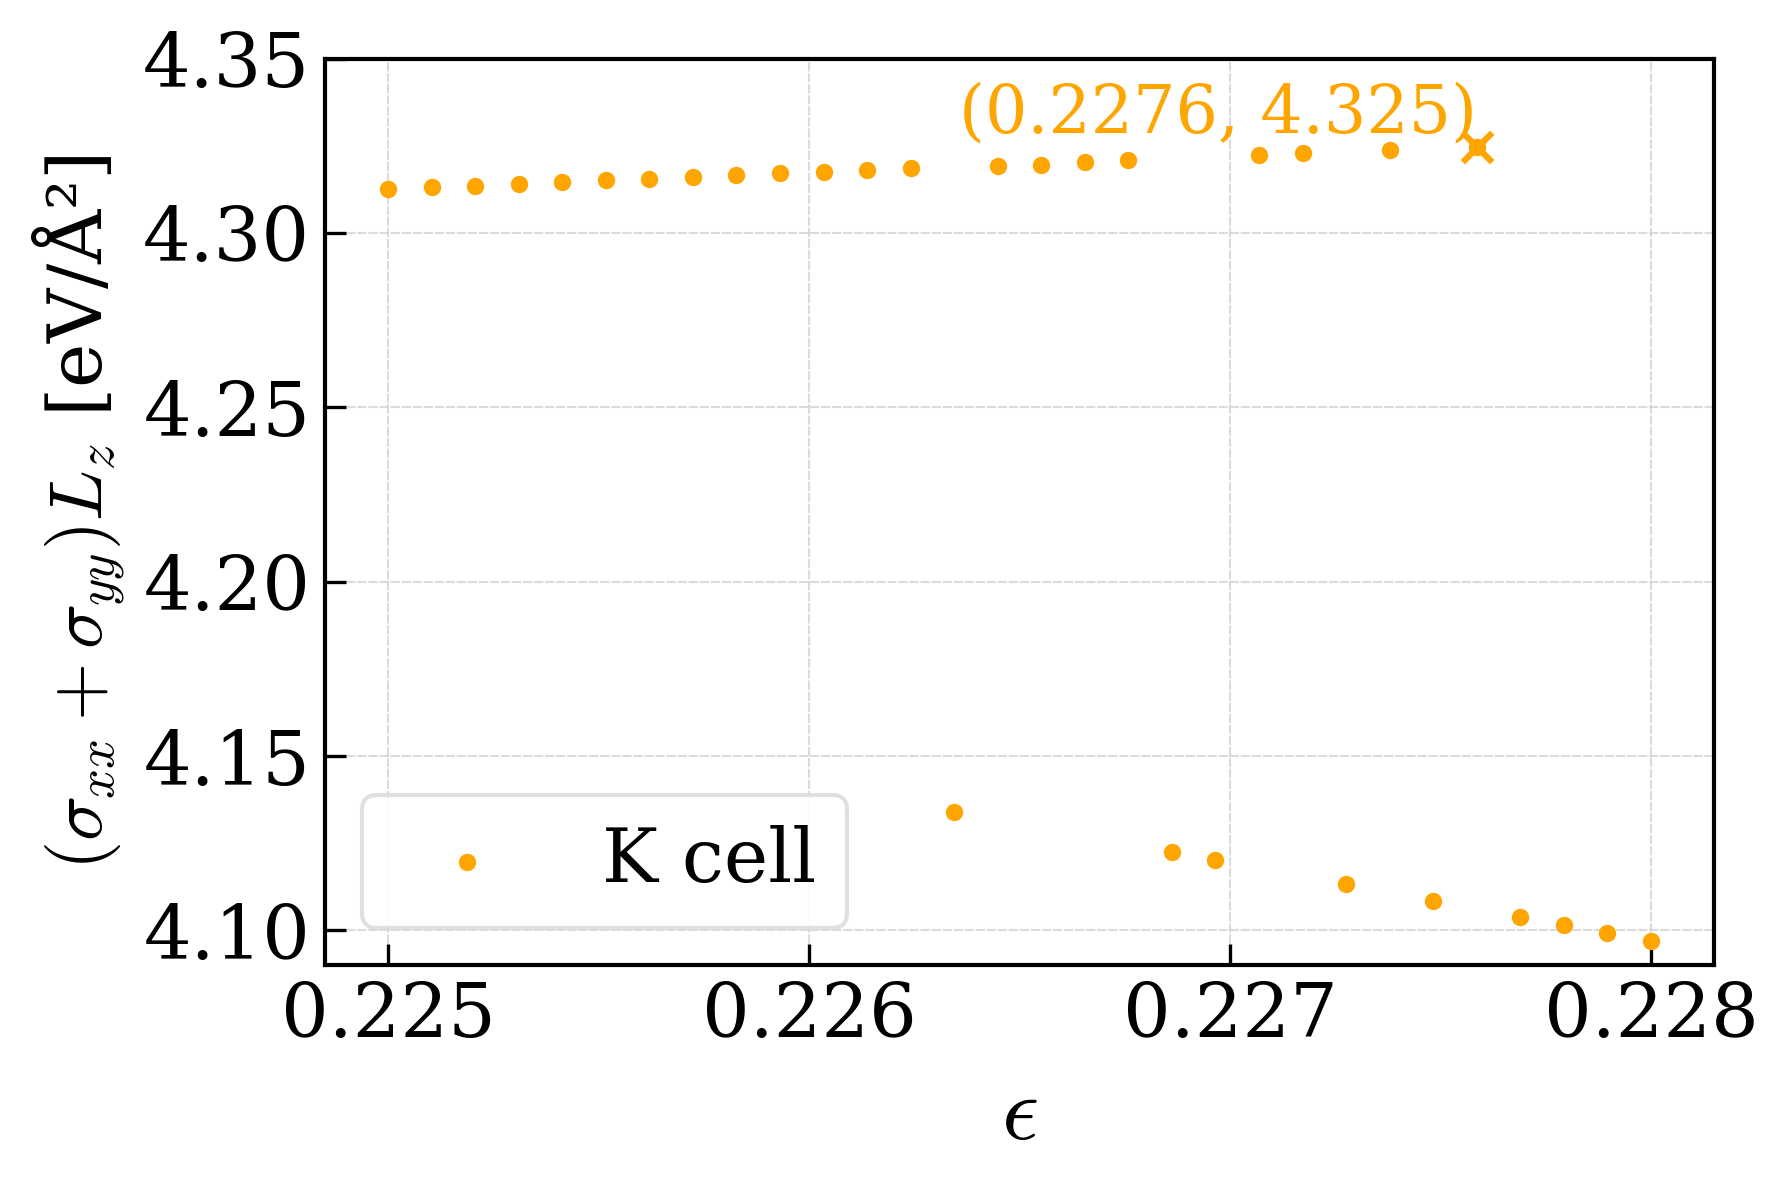

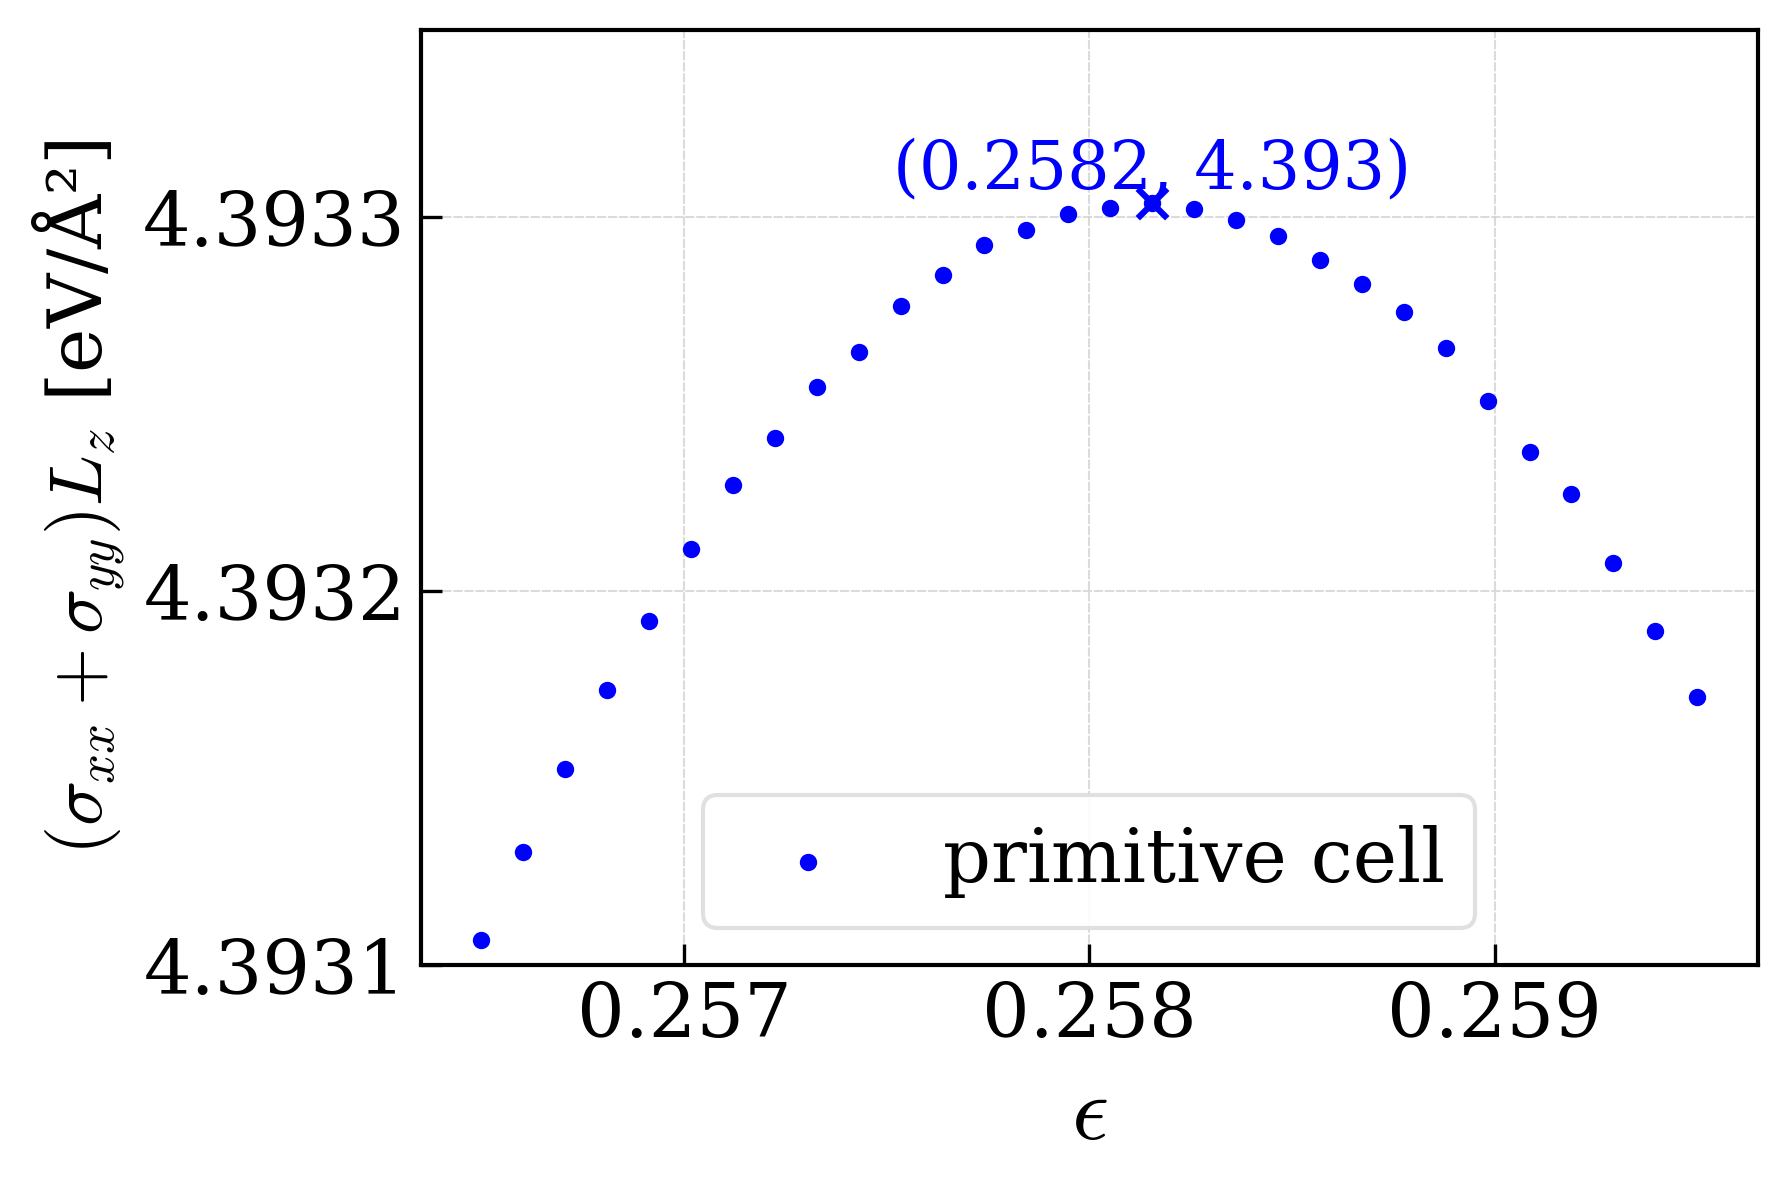

In [26]:
zoom_kcell_strains = np.linspace(0.225, 0.228, 30)
plt.scatter(zoom_kcell_strains, kcell_zoom, color="orange", s=10, label = "K cell")
xticks = np.linspace(0.225, 0.228, 4)
plt.xticks(xticks)

maxi = np.argmax(kcell_zoom)
maxstrain = zoom_kcell_strains[maxi]
max_val_label = kcell_zoom[maxi]
plt.scatter(maxstrain, kcell_zoom[maxi], marker = "x", color = "orange", s = 50)
plt.annotate(f"({maxstrain:.4f}, {max_val_label:.3f})", xy=(maxstrain, kcell_zoom[maxi]), fontsize=16, color='orange', ha='right', va='bottom')

plt.xlabel(r"$\epsilon$", fontsize = 22)
plt.ylabel("$(\sigma_{xx} + \sigma_{yy}) L_z$ [eV/Å²]")
plt.ylim(4.09, 4.35)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("MF_strainstress_kcell_zoom.pdf")
plt.show()

maxi = np.argmax(primitive_zoom)
maxstrain = zoom_primitive_strains[maxi]
max_val_label = primitive_zoom[maxi]
plt.scatter(maxstrain, primitive_zoom[maxi], marker = "x", color = "blue", s = 50)
plt.annotate(f"({maxstrain:.4f}, {max_val_label:.3f})", xy=(maxstrain, primitive_zoom[maxi]), fontsize=16, color='blue', ha='center', va='bottom')

zoom_primitive_strains = np.linspace(0.2565, 0.2595, 30)
plt.scatter(zoom_primitive_strains, primitive_zoom, color="blue", s=10, label = "primitive cell")

plt.xlabel(r"$\epsilon$", fontsize = 22)
plt.ylabel("$(\sigma_{xx} + \sigma_{yy}) L_z$ [eV/Å²]")
ymin, ymax = 4.3931, 4.39335
plt.ylim(ymin, ymax)
yticks = np.linspace(ymin, 4.3933, 3)
plt.yticks(yticks, yticks)

plt.legend(loc = "lower center")
plt.savefig("MF_strainstress_primitive_zoom.pdf")
plt.show()


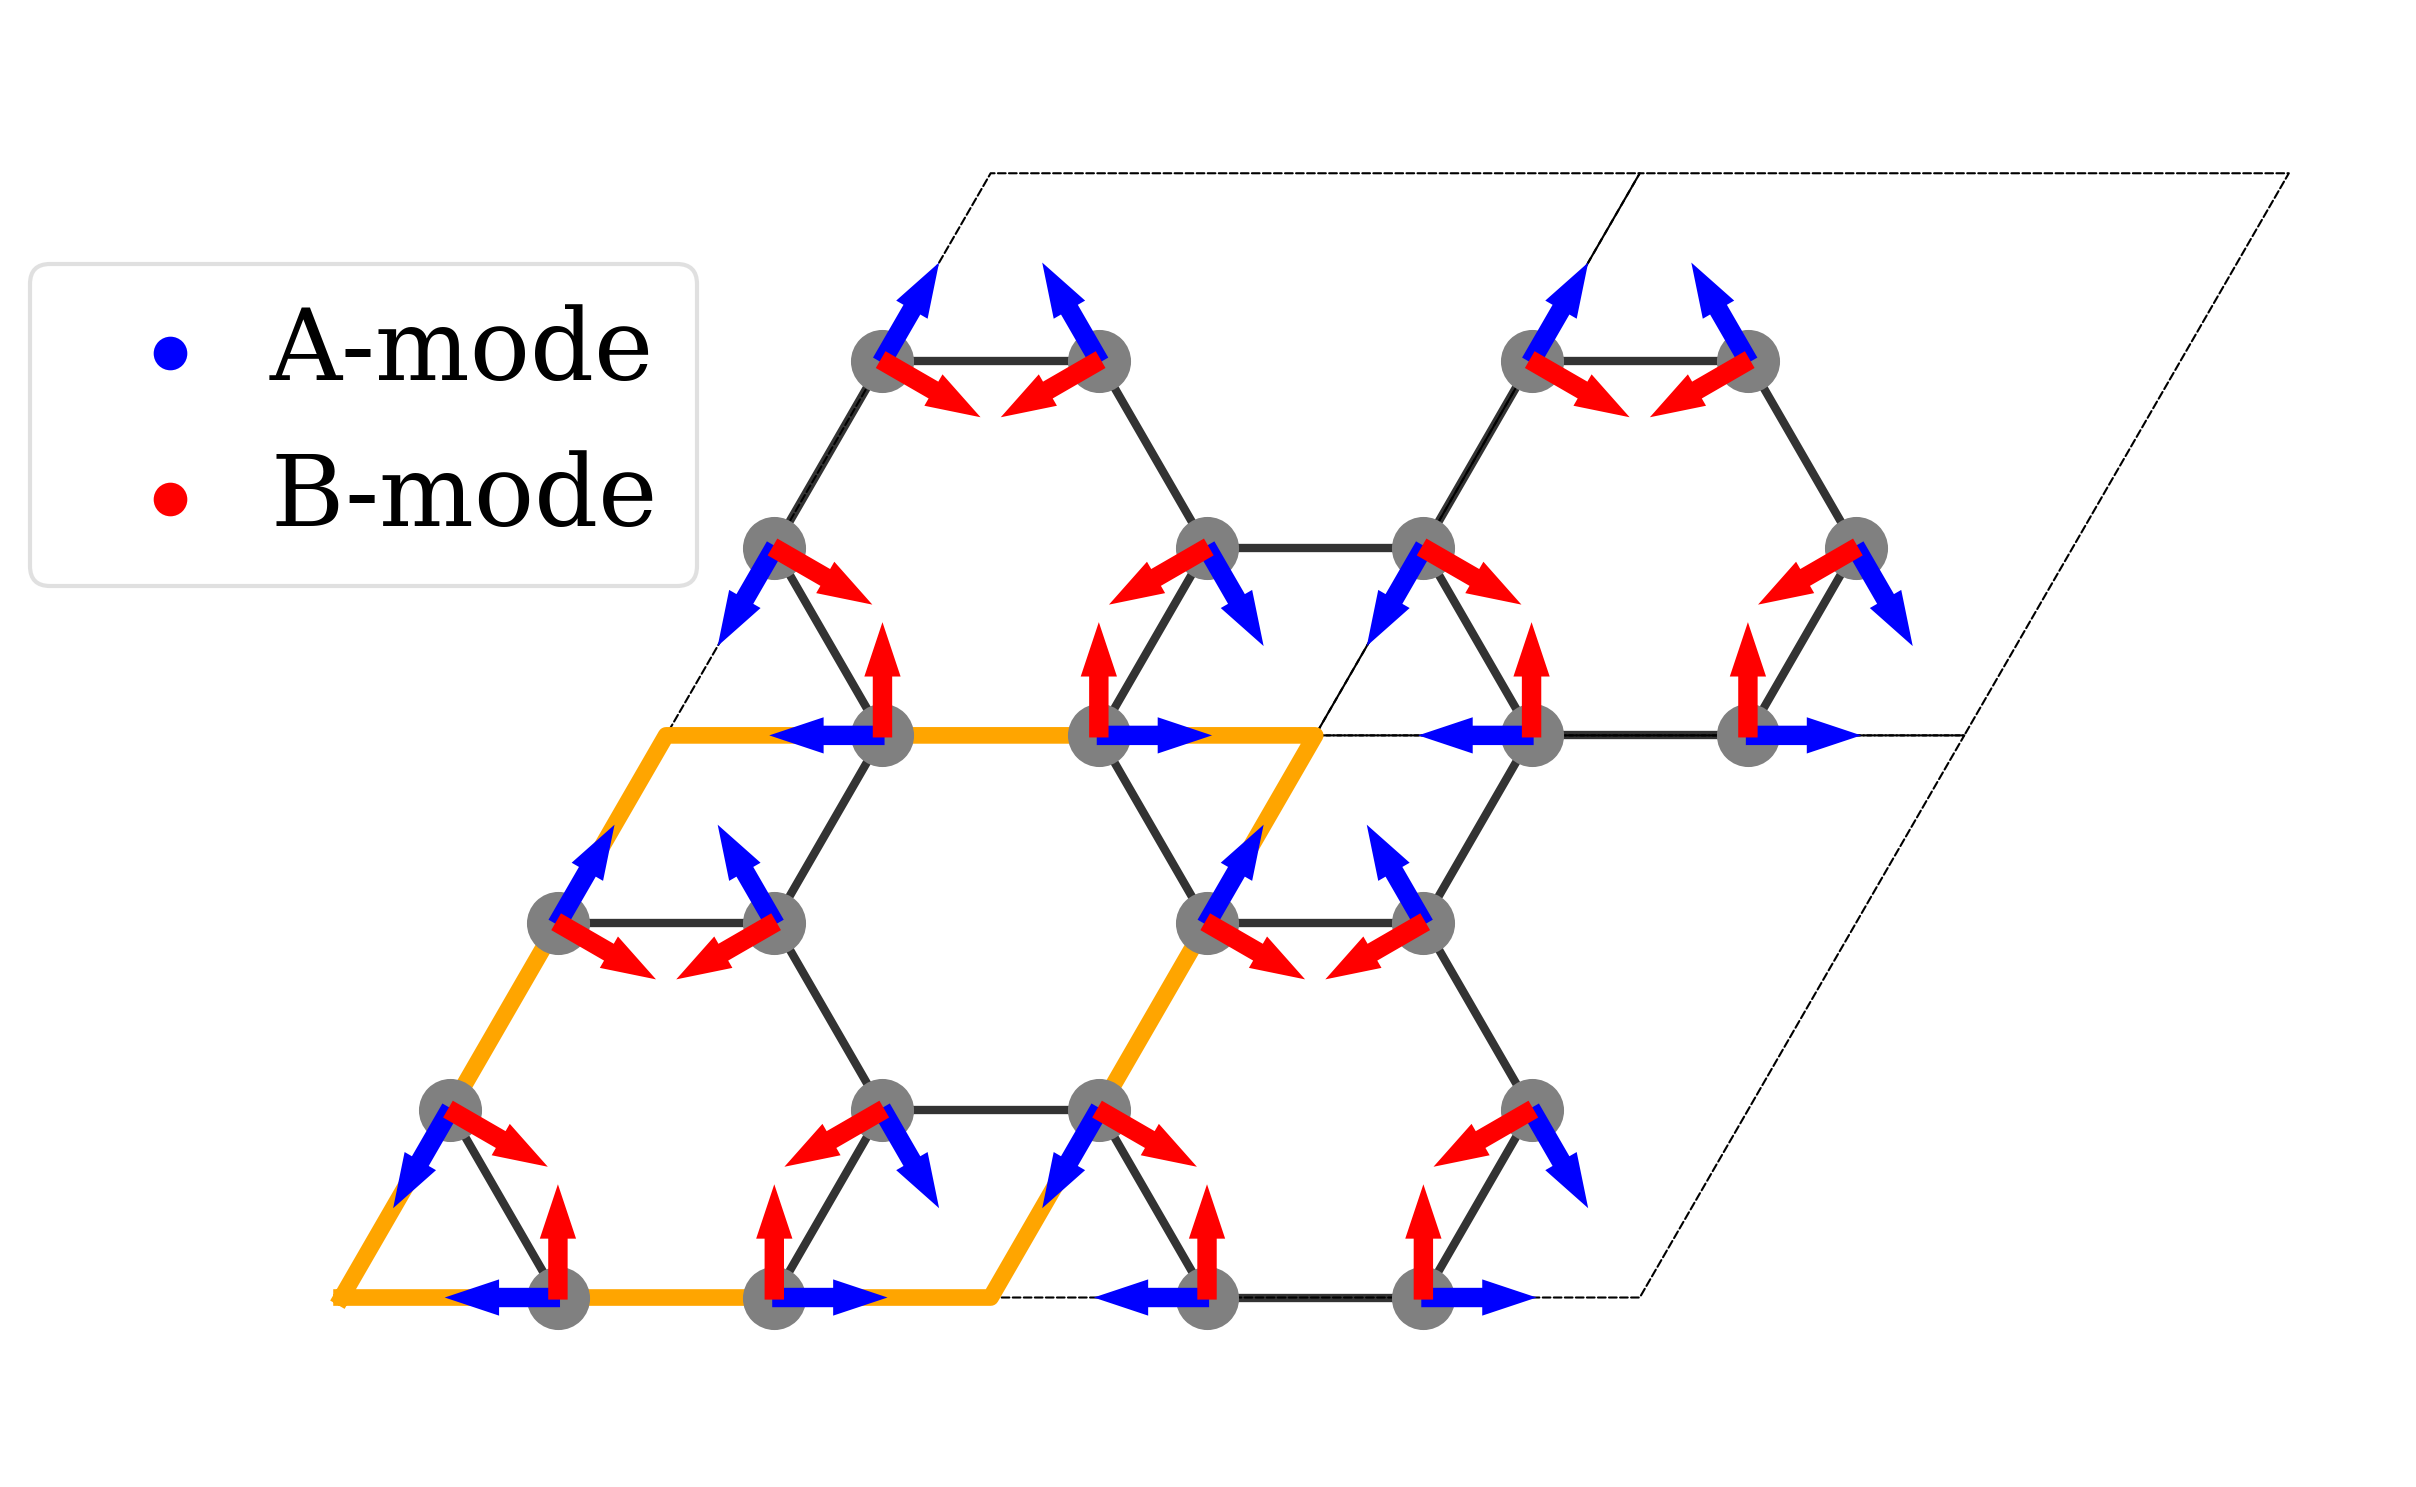

In [80]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import cKDTree
# Assuming katoms, KCELL0, AMODE, and BMODE are already defined in your environment

plt.figure(figsize=(8, 5))
plt.axis("equal")
plt.gca().set_frame_on(False)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.grid(False)

norm = 0.7
offsets = [
    (0, 0),  # Bottom-left (First cell)
    (1, 0),  # Bottom-right
    (0, 1),  # Top-left
    (1, 1),  # Top-right
]

# --- Build the full set of atom positions across the 2x2 tessellation ---
all_positions = []
for nx, ny in offsets:
    shift = nx * KCELL0[0] + ny * KCELL0[1]
    all_positions.append(katoms.positions + shift)
all_positions = np.vstack(all_positions)

# --- Auto-detect first-neighbour distance and draw bonds ---
tree = cKDTree(all_positions)
dists, _ = tree.query(all_positions, k=2)   # k=1 would just be each atom itself (dist 0)
nn_dist = np.min(dists[:, 1])
bond_cutoff = nn_dist * 1.05                # small tolerance for numerical noise

pairs = tree.query_pairs(r=bond_cutoff)
for i, j in pairs:
    x_vals = [all_positions[i, 0], all_positions[j, 0]]
    y_vals = [all_positions[i, 1], all_positions[j, 1]]
    plt.plot(x_vals, y_vals, color="black", linewidth=2.0, zorder=2, alpha=0.8)

# Loop through each tile in the 2x2 tessellation
for nx, ny in offsets:
    # Calculate the total displacement vector for this tile
    shift = nx * KCELL0[0] + ny * KCELL0[1]

    # 1. Shift and draw the cell border
    border_x = [0, KCELL0[0,0], KCELL0[0,0]+KCELL0[1,0], KCELL0[1,0], 0] + shift[0]
    border_y = [0, KCELL0[0,1], KCELL0[0,1]+KCELL0[1,1], KCELL0[1,1], 0] + shift[1]

    # Make the first cell (0,0) boundary bold, keep others thin
    if nx == 0 and ny == 0:
        plt.plot(border_x, border_y, color="orange", linewidth=4.0, zorder=2)
    else:
        plt.plot(border_x, border_y, "--", color="black", linewidth=0.5, zorder=1)

    # 2. Shift and draw the grey atoms
    shifted_positions = katoms.positions + shift
    plt.scatter(shifted_positions[:,0], shifted_positions[:,1], color="grey", zorder=3, s=200)

    # 3. Draw A and B mode displacements as arrows
    for i in range(6):
        # A-mode (Blue)
        plt.arrow(
            shifted_positions[i,0], shifted_positions[i,1],
            AMODE.xyz_directions[i,0]*norm, AMODE.xyz_directions[i,1]*norm,
            color="blue", head_width=0.2, length_includes_head=True, zorder=4,
            width=0.1
        )
        # B-mode (Red)
        plt.arrow(
            shifted_positions[i,0], shifted_positions[i,1],
            BMODE.xyz_directions[i,0]*norm, BMODE.xyz_directions[i,1]*norm,
            color="red", head_width=0.2, length_includes_head=True, zorder=4,
            width=0.1
        )

# Write modes associated with arrows in a single legend
plt.scatter([], [], color="blue", label="A-mode", s=50)
plt.scatter([], [], color="red", label="B-mode", s=50)
plt.legend(loc=(-0.1, 0.61), handletextpad=0)
plt.tight_layout()
plt.savefig("MF_kcell.svg")
plt.show()

In [ ]:
SQRT2 = np.sqrt(2)
SQRT3 = np.sqrt(3)
HALFSQRT3 = SQRT3/2.

INVSQRT2 = 1./SQRT2
INVSQRT3 = 1./SQRT3

class BaseMode():
    def __init__(self):
        self.xyz_directions = None
        return
    
    def apply(self, atoms, amplitude):
        copy = atoms.copy()
        copy.positions += amplitude * self.xyz_directions

        return copy.copy()
    
class AMode(BaseMode):
    def __init__(self):
        super().__init__()

        # These act as pure directional intents now; 
        # precise pre-normalization isn't strictly necessary if normalizing later
        d1 = np.array([1, 0, 0])
        d2 = np.array([INVSQRT2, -INVSQRT2, 0])
        d3 = np.array([0, 1, 0])
        
        self.directions = np.array([
            -d1, d1,
            d2, -d2,
            -d3, d3
        ])

        cell = np.array([
            [1, 0, 0],
            [0.5, HALFSQRT3, 0],
            [0, 0, 1]
        ])

        # 1. Transform to Cartesian coordinates
        xyz_raw = self.directions @ cell
        
        # 2. Calculate the magnitude (Euclidean norm) for each row
        magnitudes = np.linalg.norm(xyz_raw, axis=1, keepdims=True)
        
        # 3. Normalize so every vector has a physical length of 1.0
        # (Avoid division by zero just in case there's a zero vector)
        self.xyz_directions = np.divide(xyz_raw, magnitudes, out=np.zeros_like(xyz_raw), where=magnitudes!=0)

        return
    
class BMode(BaseMode):
    def __init__(self):
        super().__init__()

        d1 = [0, 1, 0]
        d2 = [-HALFSQRT3, -0.5, 0]
        d3 = [HALFSQRT3, -0.5, 0]
        self.xyz_directions = np.array([
            d1,
            d1,
            d2,
            d2,
            d3,
            d3
        ])

        return

BMODE = BMode()
AMODE = AMode()

In [ ]:
amode_kcell = AMODE.apply(katoms, 0.5).get_positions() - katoms.get_positions()
kpoint = np.array([1/3, 1/3, 0])

In [ ]:
import numpy as np

import numpy as np

def extract_universal_primitive_mode(amode_obj, katoms, kpoint):
    """
    Directly projects the AMODE supercell displacements onto the 2-atom 
    primitive basis coordinates, cleanly resolving the phase parameters 
    for any arbitrary k-point.
    """
    u_real = amode_obj.xyz_directions  # shape (6, 3)
    pos_cart = katoms.get_positions()
    
    primitive_mode = np.zeros((2, 3), dtype=complex)
    inv_kcell = np.linalg.inv(katoms.cell)
    
    # Analyze the sublattices using the first two cells to resolve Re and Im components
    for sub in [0, 1]:
        # Sample the same sublattice from Cell 0 (index sub) and Cell 1 (index sub + 2)
        idx0 = sub
        idx1 = sub + 2
        
        # Determine their fractional lattice positions inside the KCELL
        R0_frac = pos_cart[idx0] @ inv_kcell
        R1_frac = pos_cart[idx1] @ inv_kcell
        
        # Evaluate the plane-wave phase shifts
        p0 = np.exp(1j * 2 * np.pi * np.dot(kpoint, R0_frac))
        p1 = np.exp(1j * 2 * np.pi * np.dot(kpoint, R1_frac))
        
        # Set up a linear system to unpack the underlying complex coordinates
        M = np.array([
            [p0.real, -p0.imag],
            [p1.real, -p1.imag]
        ])
        
        for axis in range(3):
            rhs = np.array([u_real[idx0, axis], u_real[idx1, axis]])
            # Solve for the real and imaginary components of the mode vector
            res = np.linalg.solve(M, rhs)
            primitive_mode[sub, axis] = res[0] + 1j * res[1]
            
    # Normalize the output array to unit length
    norm = np.linalg.norm(primitive_mode)
    if norm > 1e-8:
        primitive_mode /= norm
        
    return primitive_mode

In [ ]:
extract_universal_primitive_mode(AMODE, katoms=katoms, kpoint=kpoint)

array([[-0.40335306+0.03973605j,  0.18909472+0.22535432j,
         0.        +0.j        ],
       [ 0.7069721 -0.21503059j, -0.44386135-0.07826473j,
         0.        +0.j        ]])

### isotropic breaking

In [ ]:


ID = np.eye(3)
strain = 0.2275
angle = np.deg2rad(45)
C = np.cos(angle)
S = np.sin(angle)
deformation = ID + strain * np.array([[C, 0, 0], [0, S, 0], [0, 0, 0]])
amplitude = 1e-3


In [ ]:

import torch
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# If using newer PyTorch versions:
torch.use_deterministic_algorithms(True)

TRAJDIR = "DETERMINISTIC_AMODERELAXATIONS"
import os
os.makedirs(TRAJDIR, exist_ok = True)

for i in range(3):
    deformed = katoms.copy()
    deformed.set_cell(katoms.cell @ deformation, scale_atoms=True)
    deformed.calc = model
    opt = BFGS(deformed, None)
    opt.run(5e-5, 1000)

    deformed = AMODE.apply(deformed, amplitude)

    deformedsupercell = deformed * (9,9,1)
    deformedsupercell.calc = model
    relaxtraj = os.path.join(TRAJDIR, f"{strain:.4f}_{i}_kcell_supercell_strained_Amode_relax.traj")
    opt = BFGS(deformedsupercell, trajectory=relaxtraj)
    opt.run(0.000001, 500)

      Step     Time          Energy          fmax
BFGS:    0 17:16:19      -40.114288        0.000006
      Step     Time          Energy          fmax
BFGS:    0 17:16:19    -3249.256104        0.000107
BFGS:    1 17:16:19    -3249.256104        0.000111
BFGS:    2 17:16:20    -3249.256348        0.000710
BFGS:    3 17:16:20    -3249.256592        0.001367
BFGS:    4 17:16:21    -3249.256592        0.004330
BFGS:    5 17:16:21    -3249.269775        0.082123
BFGS:    6 17:16:21    -3249.341064        0.155484
BFGS:    7 17:16:22    -3249.575684        0.252878
BFGS:    8 17:16:22    -3249.593994        0.435575
BFGS:    9 17:16:22    -3249.807617        0.289098
BFGS:   10 17:16:22    -3249.886230        0.296002
BFGS:   11 17:16:23    -3249.912354        0.267978
BFGS:   12 17:16:23    -3249.926025        0.241181
BFGS:   13 17:16:23    -3249.967529        0.141348
BFGS:   14 17:16:23    -3249.979736        0.087296
BFGS:   15 17:16:24    -3249.987305        0.066104
BFGS:   16 17:16

### random displacement breaking

In [ ]:

import torch

TRAJDIR = "RANDOM_DISPLACEMENT_RELAXATIONS"
import os
os.makedirs(TRAJDIR, exist_ok = True)

for i in range(3):
    deformed = katoms.copy()
    deformed.set_cell(katoms.cell @ deformation, scale_atoms=True)
    deformed.calc = model
    opt = BFGS(deformed, None)
    opt.run(5e-5, 1000)

    deformedsupercell = deformed * (9,9,1)
    deformedsupercell.calc = model

    displacements = np.random.normal(0, 1e-2, size = deformedsupercell.positions.shape)
    displacements[:,2] = 0
    deformedsupercell.positions += displacements

    relaxtraj = os.path.join(TRAJDIR, f"{strain:.4f}_{i}_kcell_supercell_strained_random_relax.traj")
    opt = BFGS(deformedsupercell, trajectory=relaxtraj)
    opt.run(0.000001, 500)

      Step     Time          Energy          fmax
BFGS:    0 17:44:21      -40.114288        0.000006
      Step     Time          Energy          fmax
BFGS:    0 17:44:21    -3248.414307        0.780889
BFGS:    1 17:44:22    -3248.912598        0.461492
BFGS:    2 17:44:22    -3249.176514        0.156698
BFGS:    3 17:44:22    -3249.202881        0.121062
BFGS:    4 17:44:22    -3249.233154        0.063243
BFGS:    5 17:44:23    -3249.238037        0.059988
BFGS:    6 17:44:23    -3249.247070        0.052506
BFGS:    7 17:44:23    -3249.250244        0.045142
BFGS:    8 17:44:23    -3249.252441        0.026125
BFGS:    9 17:44:24    -3249.253906        0.019456
BFGS:   10 17:44:24    -3249.254639        0.016527
BFGS:   11 17:44:24    -3249.254883        0.015714
BFGS:   12 17:44:24    -3249.255615        0.011170
BFGS:   13 17:44:25    -3249.255615        0.008965
BFGS:   14 17:44:25    -3249.255615        0.008878
BFGS:   15 17:44:25    -3249.255859        0.009575
BFGS:   16 17:44

### second derivative

In [ ]:
ID = np.eye(3)
strains = np.linspace(0.13, 0.23, num = 100)
deformations = [ID + np.array([[s, 0, 0], [0, s, 0], [0, 0, 0]]) for s in strains]
amplitudes = np.linspace(-0.4, 0.6, num=50)

AMODE_ENERGIES = {}

AMODE_ENERGIES['amplitudes'] = amplitudes
amodes = []

for strain, deformation in tqdm(zip(strains, deformations), total=strains.size):
    cell = KCELL0 @ deformation
    strained_atoms = katoms.copy()
    strained_atoms.set_cell(cell, scale_atoms=True)
    strained_atoms.calc = model

    energies = []
    for a in amplitudes:
        modded_atoms = AMODE.apply(strained_atoms, a)
        modded_atoms.calc = model
        energies.append(modded_atoms.get_potential_energy())
        amodes.append(modded_atoms.copy())

    AMODE_ENERGIES[strain] = energies


100%|██████████| 100/100 [02:06<00:00,  1.27s/it]


In [ ]:
import json
import numpy as np

class NumpyEncoder(json.JSONEncoder):
    """ Custom encoder for numpy data types """
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.bool_):
            return bool(obj)
        return super(NumpyEncoder, self).default(obj)



In [ ]:
import json
with open("AMODE.json", "w") as f:
    json.dump(AMODE_ENERGIES, f, cls=NumpyEncoder)

In [67]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import numpy as np

def plot_mode_energy(mode_energy, ylim = None):
    # 'amplitudes' is our x-axis data
    amplitudes = np.asarray(mode_energy['amplitudes'])
    
    # Filter keys to get only the strain data (keeping them as strings for dict lookup)
    strain_keys = [s for s in mode_energy.keys() if s != "amplitudes"]
    # Convert to floats for sorting and normalization
    print(strain_keys)
    strain_floats = [float(s) for s in strain_keys]
    print(strain_floats)

    norm = colors.Normalize(vmin=np.sqrt(2)*min(strain_floats), vmax=np.sqrt(2)*max(strain_floats))
    cmap = cm.viridis

    fig, ax = plt.subplots()

    # We'll store the index of the minimum for each strain
    for s_key in strain_keys:
        # Get color based on the float value of the strain
        color = cmap(norm(np.sqrt(2)*float(s_key)))
        
        y_data = np.asarray(mode_energy[s_key])
        ax.plot(amplitudes, y_data, color=color, zorder=2)
        
        # --- FIX 1: Find and plot the minimum inside this loop or store correctly ---
        mini_idx = np.argmin(y_data)
        
        # x-coord: the amplitude at that index
        # y-coord: the energy value at that index
        ax.scatter(
            amplitudes[mini_idx], 
            y_data[mini_idx], 
            marker="x", 
            s = 5,
            color="red", 
            zorder=5  # Keep in foreground
        )

    ax.set_ylim(-45, 1)
    ax.set_xlabel("A-mode amplitude [$\\AA$]")
    ax.set_ylabel("Potential Energy [eV]")

    # Add the Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) 
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r'$\epsilon$')
    if ylim:
        plt.ylim(ylim)

    plt.tight_layout()
    plt.savefig("amode_amplitude.svg")

    plt.show()

['0.13', '0.13101010101010102', '0.13202020202020204', '0.13303030303030303', '0.13404040404040404', '0.13505050505050506', '0.13606060606060608', '0.13707070707070707', '0.13808080808080808', '0.1390909090909091', '0.14010101010101011', '0.1411111111111111', '0.14212121212121212', '0.14313131313131314', '0.14414141414141415', '0.14515151515151514', '0.14616161616161616', '0.14717171717171718', '0.1481818181818182', '0.1491919191919192', '0.1502020202020202', '0.15121212121212121', '0.15222222222222223', '0.15323232323232325', '0.15424242424242424', '0.15525252525252525', '0.15626262626262627', '0.1572727272727273', '0.1582828282828283', '0.1592929292929293', '0.1603030303030303', '0.16131313131313132', '0.1623232323232323', '0.16333333333333333', '0.16434343434343435', '0.16535353535353536', '0.16636363636363638', '0.16737373737373737', '0.16838383838383839', '0.1693939393939394', '0.1704040404040404', '0.1714141414141414', '0.17242424242424242', '0.17343434343434344', '0.174444444444

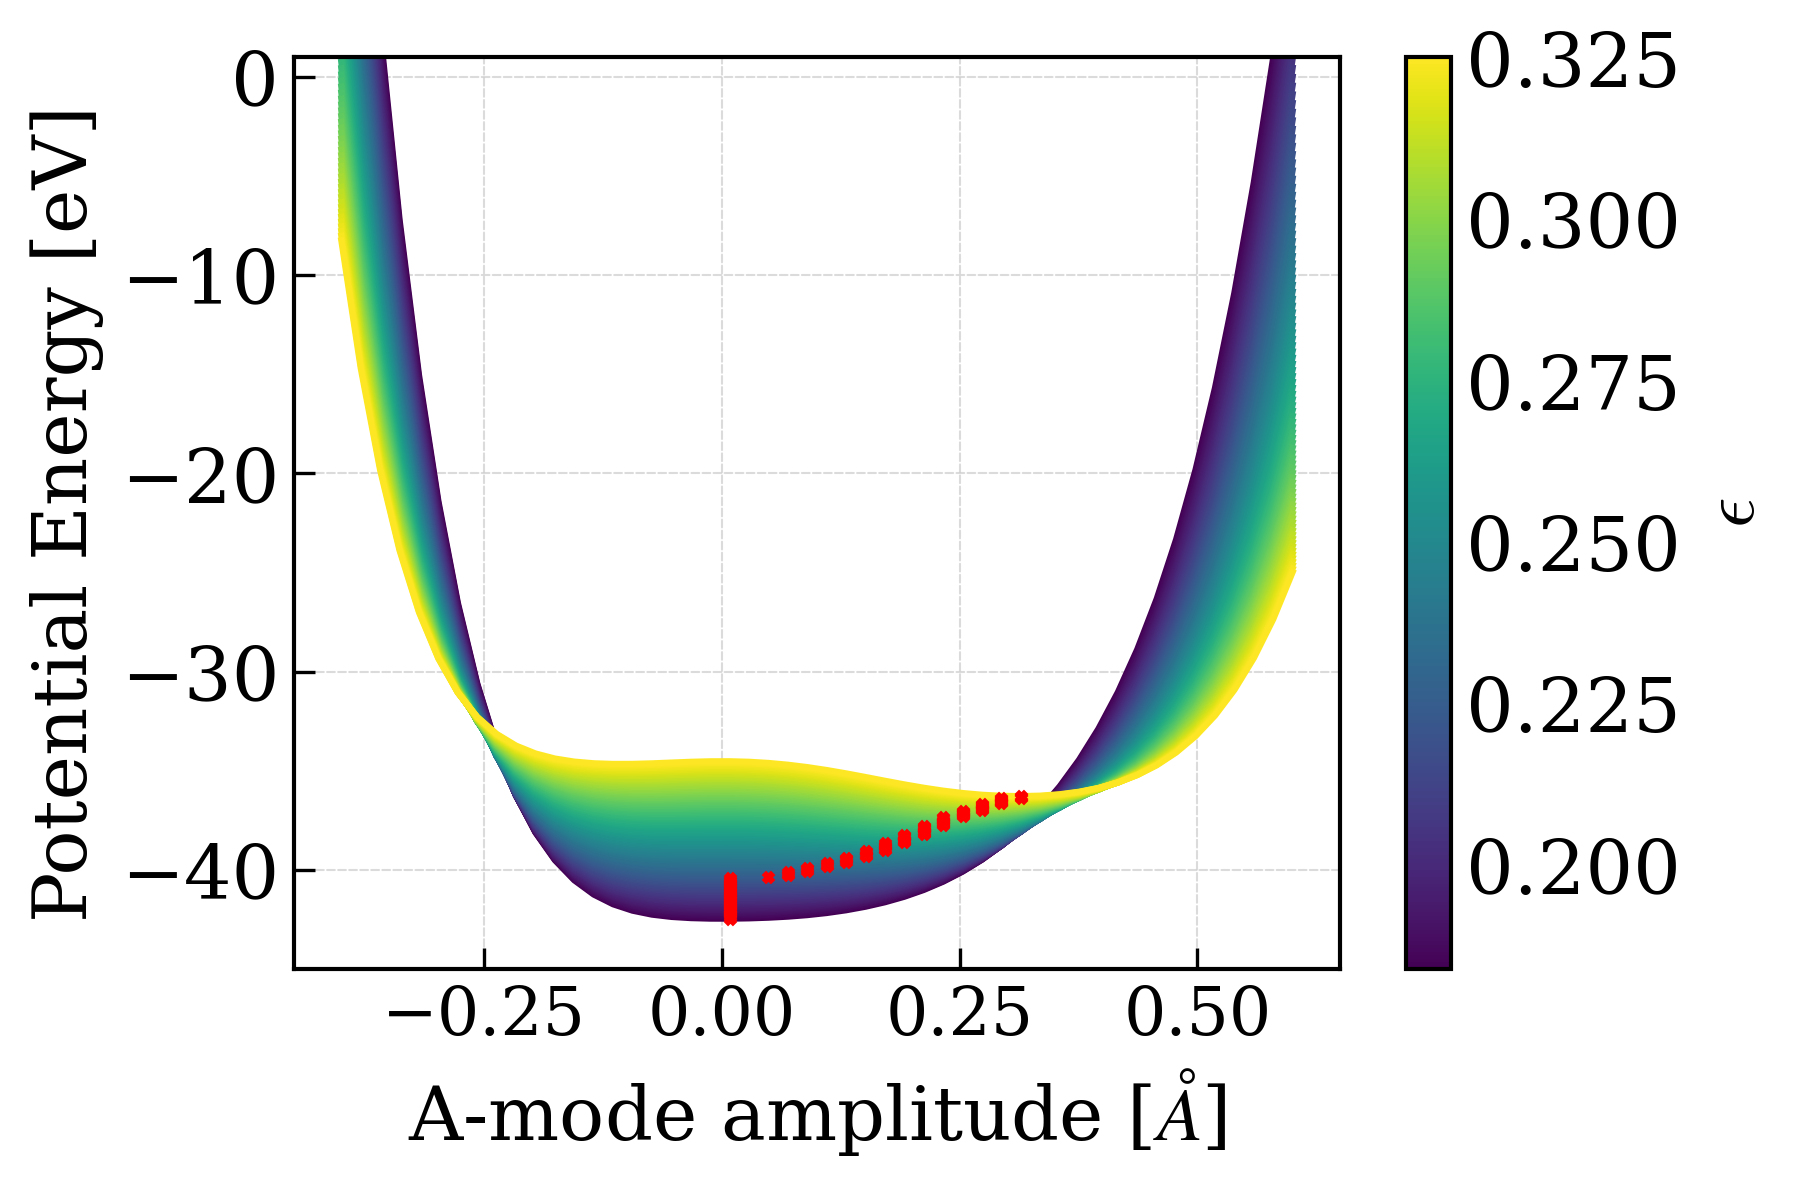

In [68]:
import json
import numpy as np

def numpy_hook(obj):
    """ Converts lists back to numpy arrays during loading if desired """
    for key, value in obj.items():
        if isinstance(value, list):
            obj[key] = np.array(value)
    return obj

with open("AMODE.json", "r") as f:
    # This will turn every list in your JSON back into a numpy array
    AMODE_ENERGIES = json.load(f, object_hook=numpy_hook)

plot_mode_energy(AMODE_ENERGIES)

In [69]:
def plot_key(key, AMODE):
    xs = AMODE['amplitudes']
    ys = AMODE[key]
    plt.xlim(-0.1, 0.1)
    plt.scatter(xs, ys)
    minidx = np.argmin(ys)
    minx = xs[minidx]
    miny = ys[minidx]
    plt.scatter(minx, miny, marker = "x")
    miny = np.min(ys)
    plt.ylim(miny-0.001, miny+0.05)
    plt.show()

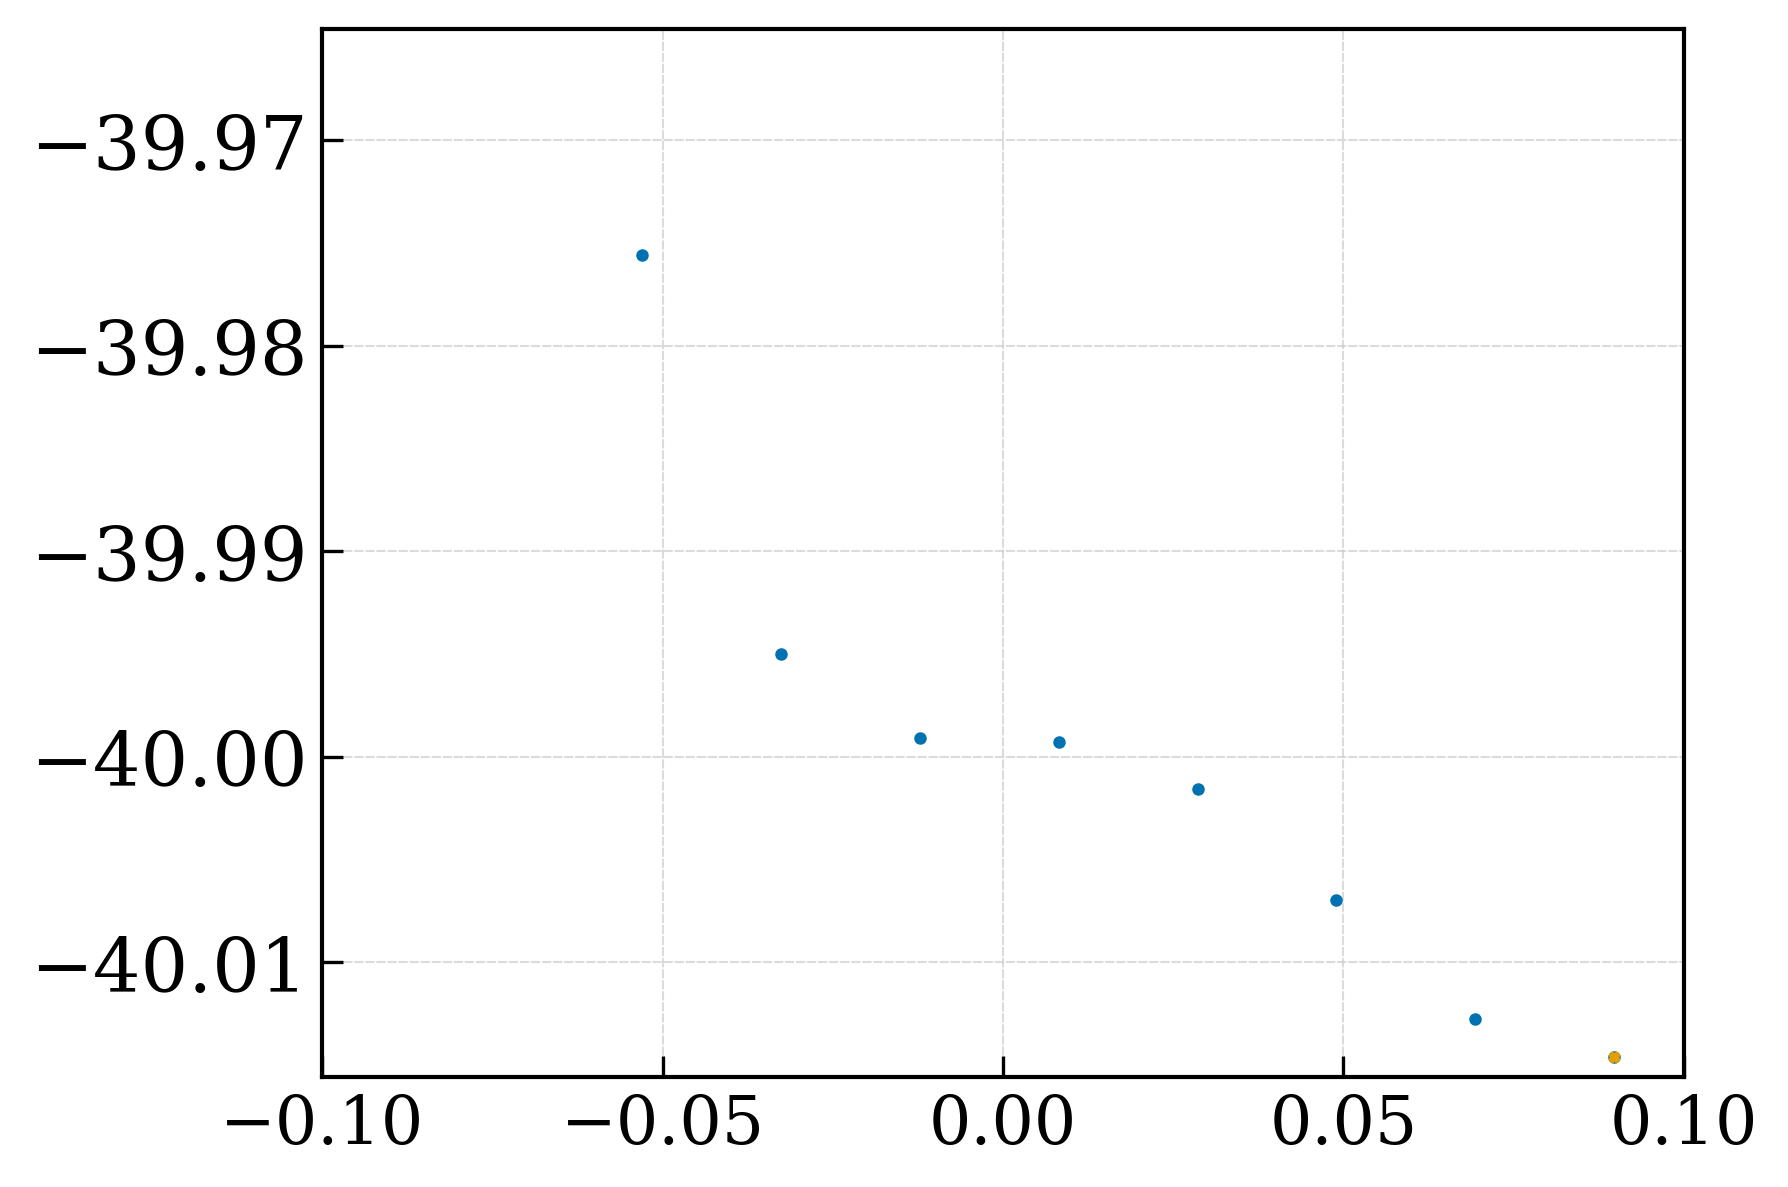

0.2295597166397539


In [70]:
key = list(AMODE_ENERGIES.keys())[33]
plot_key(key, AMODE=AMODE_ENERGIES)
print(float(key) * SQRT2)


In [ ]:
ID = np.eye(3)
strains_zoom = np.linspace(0.2/np.sqrt(2), 0.25/np.sqrt(2), num = 100)
deformations_zoom = [ID + np.array([[s, 0, 0], [0, s, 0], [0, 0, 0]]) for s in strains_zoom]
amplitudes_zoom = np.linspace(-0.1, 0.1, num=101, endpoint=True)

AMODE_ENERGIES_ZOOM = {}

AMODE_ENERGIES_ZOOM['amplitudes'] = amplitudes_zoom
amodes = []

for strain, deformation in tqdm(zip(strains_zoom, deformations_zoom), total=strains_zoom.size):
    cell = KCELL0 @ deformation
    strained_atoms = katoms.copy()
    strained_atoms.set_cell(cell, scale_atoms=True)
    strained_atoms.calc = model

    energies = []
    for a in amplitudes_zoom:
        modded_atoms = AMODE.apply(strained_atoms, a)
        modded_atoms.calc = model
        energies.append(modded_atoms.get_potential_energy())
        amodes.append(modded_atoms.copy())

    AMODE_ENERGIES_ZOOM[strain] = energies


100%|██████████| 100/100 [04:07<00:00,  2.47s/it]


In [ ]:
import json
class NumpyEncoder(json.JSONEncoder):
    """ Custom encoder for numpy data types """
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.bool_):
            return bool(obj)
        return super(NumpyEncoder, self).default(obj)


In [ ]:
with open("AMODE_ZOOM.json", "w") as f:
    json.dump(AMODE_ENERGIES_ZOOM, f, cls=NumpyEncoder)

In [ ]:
AMODE_ENERGIES_ZOOM.keys()

dict_keys(['amplitudes', np.float64(0.1414213562373095), np.float64(0.14177848087427242), np.float64(0.1421356055112353), np.float64(0.14249273014819822), np.float64(0.1428498547851611), np.float64(0.14320697942212401), np.float64(0.14356410405908693), np.float64(0.1439212286960498), np.float64(0.14427835333301273), np.float64(0.14463547796997564), np.float64(0.14499260260693853), np.float64(0.14534972724390144), np.float64(0.14570685188086432), np.float64(0.14606397651782724), np.float64(0.14642110115479015), np.float64(0.14677822579175304), np.float64(0.14713535042871595), np.float64(0.14749247506567884), np.float64(0.14784959970264175), np.float64(0.14820672433960466), np.float64(0.14856384897656755), np.float64(0.14892097361353046), np.float64(0.14927809825049337), np.float64(0.14963522288745626), np.float64(0.14999234752441917), np.float64(0.15034947216138206), np.float64(0.15070659679834497), np.float64(0.15106372143530788), np.float64(0.15142084607227077), np.float64(0.151777970

['0.1414213562373095', '0.14177848087427242', '0.1421356055112353', '0.14249273014819822', '0.1428498547851611', '0.14320697942212401', '0.14356410405908693', '0.1439212286960498', '0.14427835333301273', '0.14463547796997564', '0.14499260260693853', '0.14534972724390144', '0.14570685188086432', '0.14606397651782724', '0.14642110115479015', '0.14677822579175304', '0.14713535042871595', '0.14749247506567884', '0.14784959970264175', '0.14820672433960466', '0.14856384897656755', '0.14892097361353046', '0.14927809825049337', '0.14963522288745626', '0.14999234752441917', '0.15034947216138206', '0.15070659679834497', '0.15106372143530788', '0.15142084607227077', '0.15177797070923368', '0.15213509534619657', '0.15249221998315948', '0.1528493446201224', '0.15320646925708528', '0.1535635938940482', '0.1539207185310111', '0.154277843167974', '0.1546349678049369', '0.1549920924418998', '0.1553492170788627', '0.15570634171582562', '0.1560634663527885', '0.15642059098975142', '0.1567777156267143', '

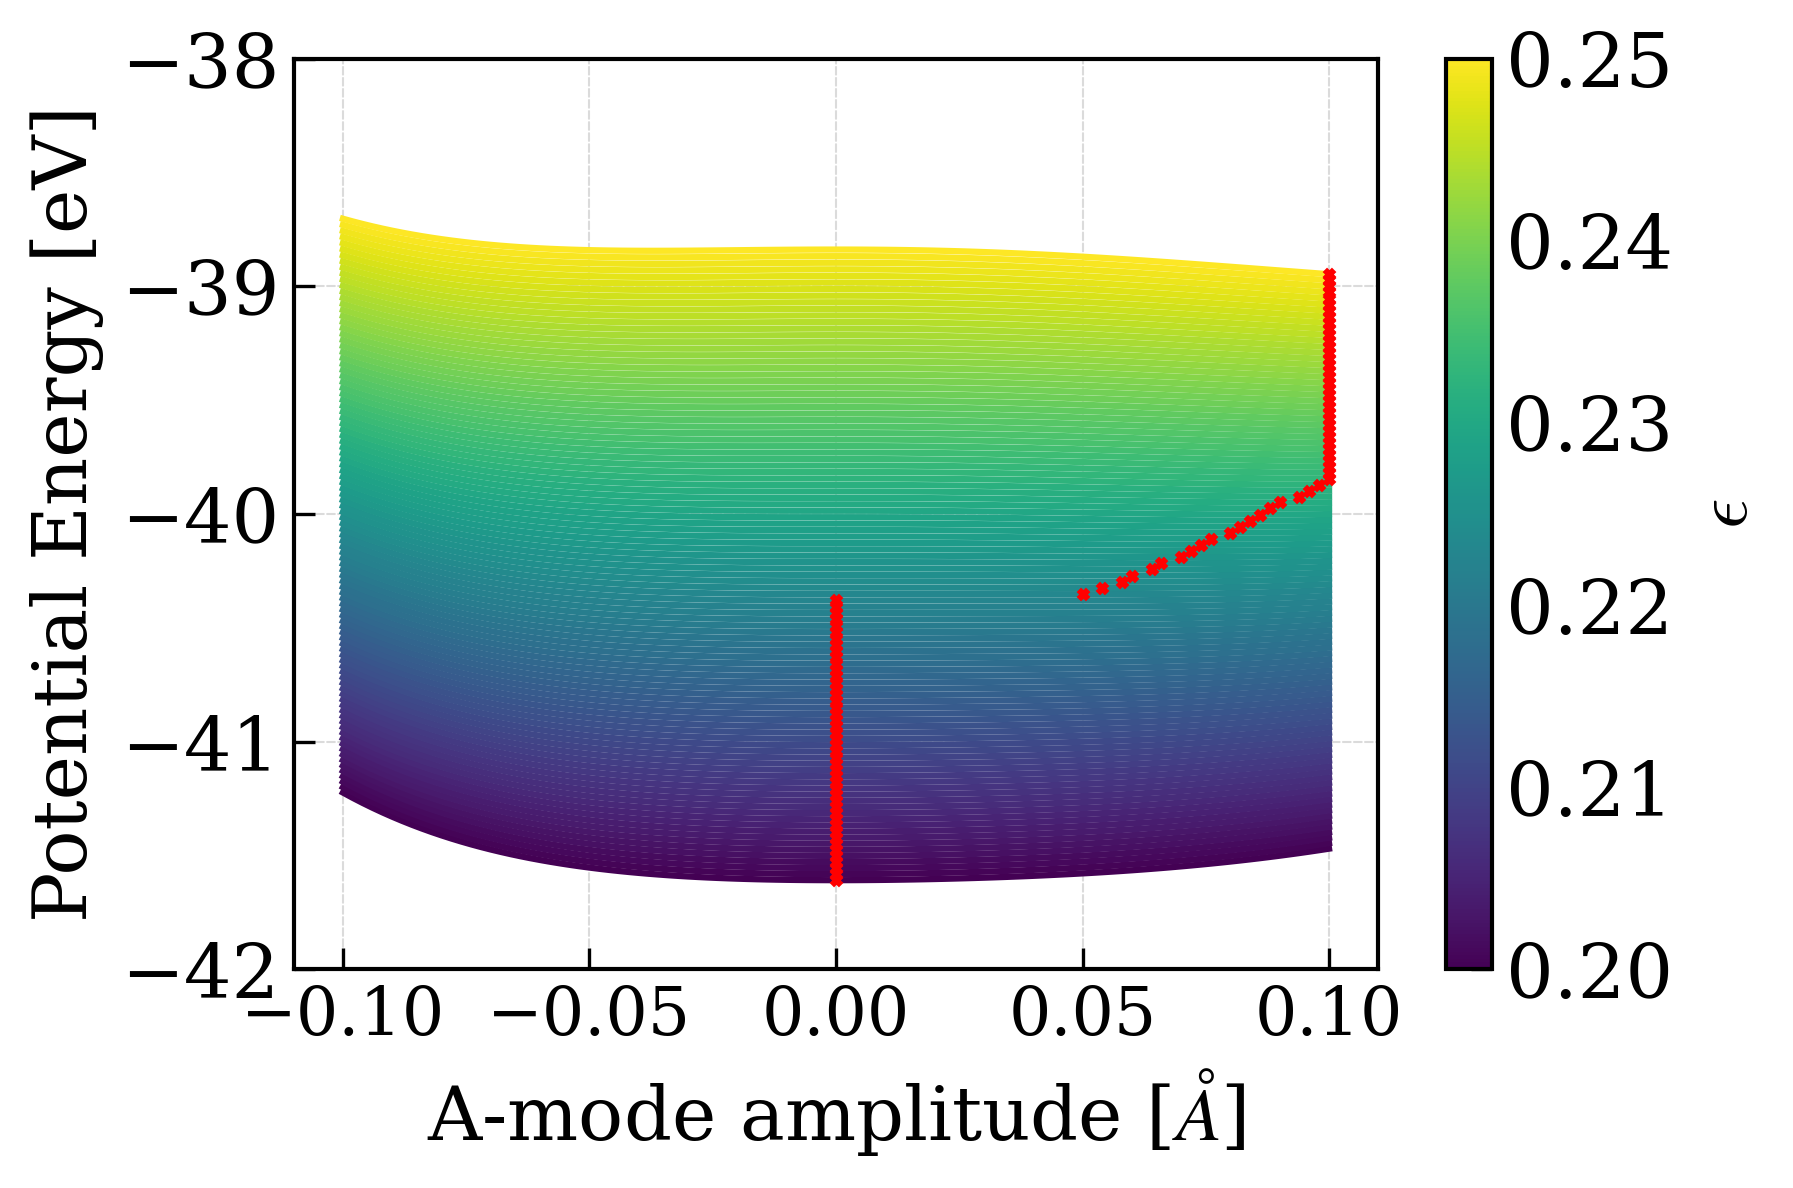

In [71]:
import json
import numpy as np

def numpy_hook(obj):
    """ Converts lists back to numpy arrays during loading if desired """
    for key, value in obj.items():
        if isinstance(value, list):
            obj[key] = np.array(value)
    return obj

with open("AMODE_ZOOM.json", "r") as f:
    # This will turn every list in your JSON back into a numpy array
    AMODE_ENERGIES_ZOOM = json.load(f, object_hook=numpy_hook)


plot_mode_energy(AMODE_ENERGIES_ZOOM, (-42, -38))



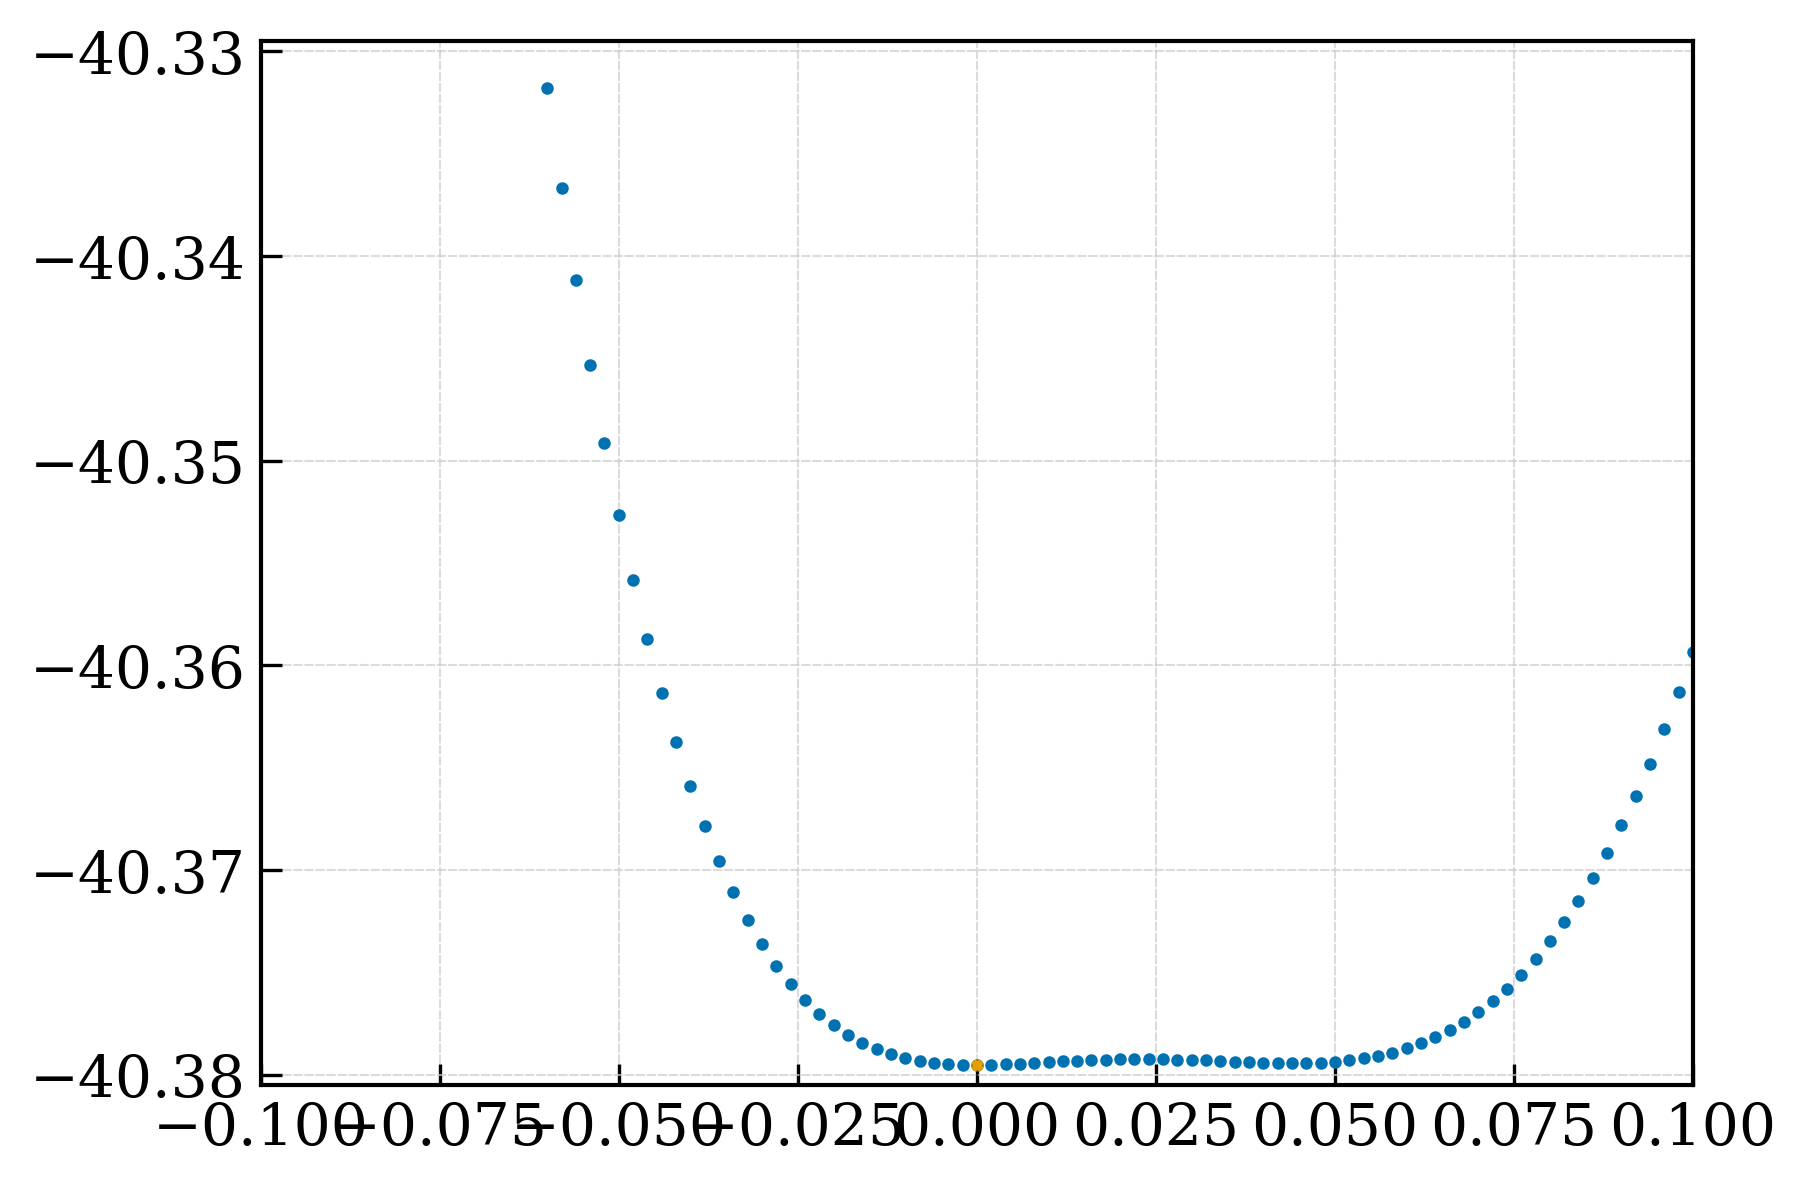

In [ ]:
plot_key(str(strains_zoom[45]), AMODE_ENERGIES_ZOOM)

In [ ]:
mins = np.array([
    np.argmin(entry) for entry in AMODE_ENERGIES_ZOOM.values()
])

In [ ]:
mins

array([  0,  50,  50,  50,  50,  50,  50,  50,  50,  50,  50,  50,  50,
        50,  50,  50,  50,  50,  50,  50,  50,  50,  50,  50,  50,  50,
        50,  50,  50,  77,  82,  86,  89,  93,  96,  99, 100, 100, 100,
       100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
       100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
       100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
       100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
       100, 100, 100, 100, 100, 100, 100, 100, 100, 100])

In [ ]:
strains_zoom[46] * np.sqrt(2)

np.float64(0.22323232323232323)

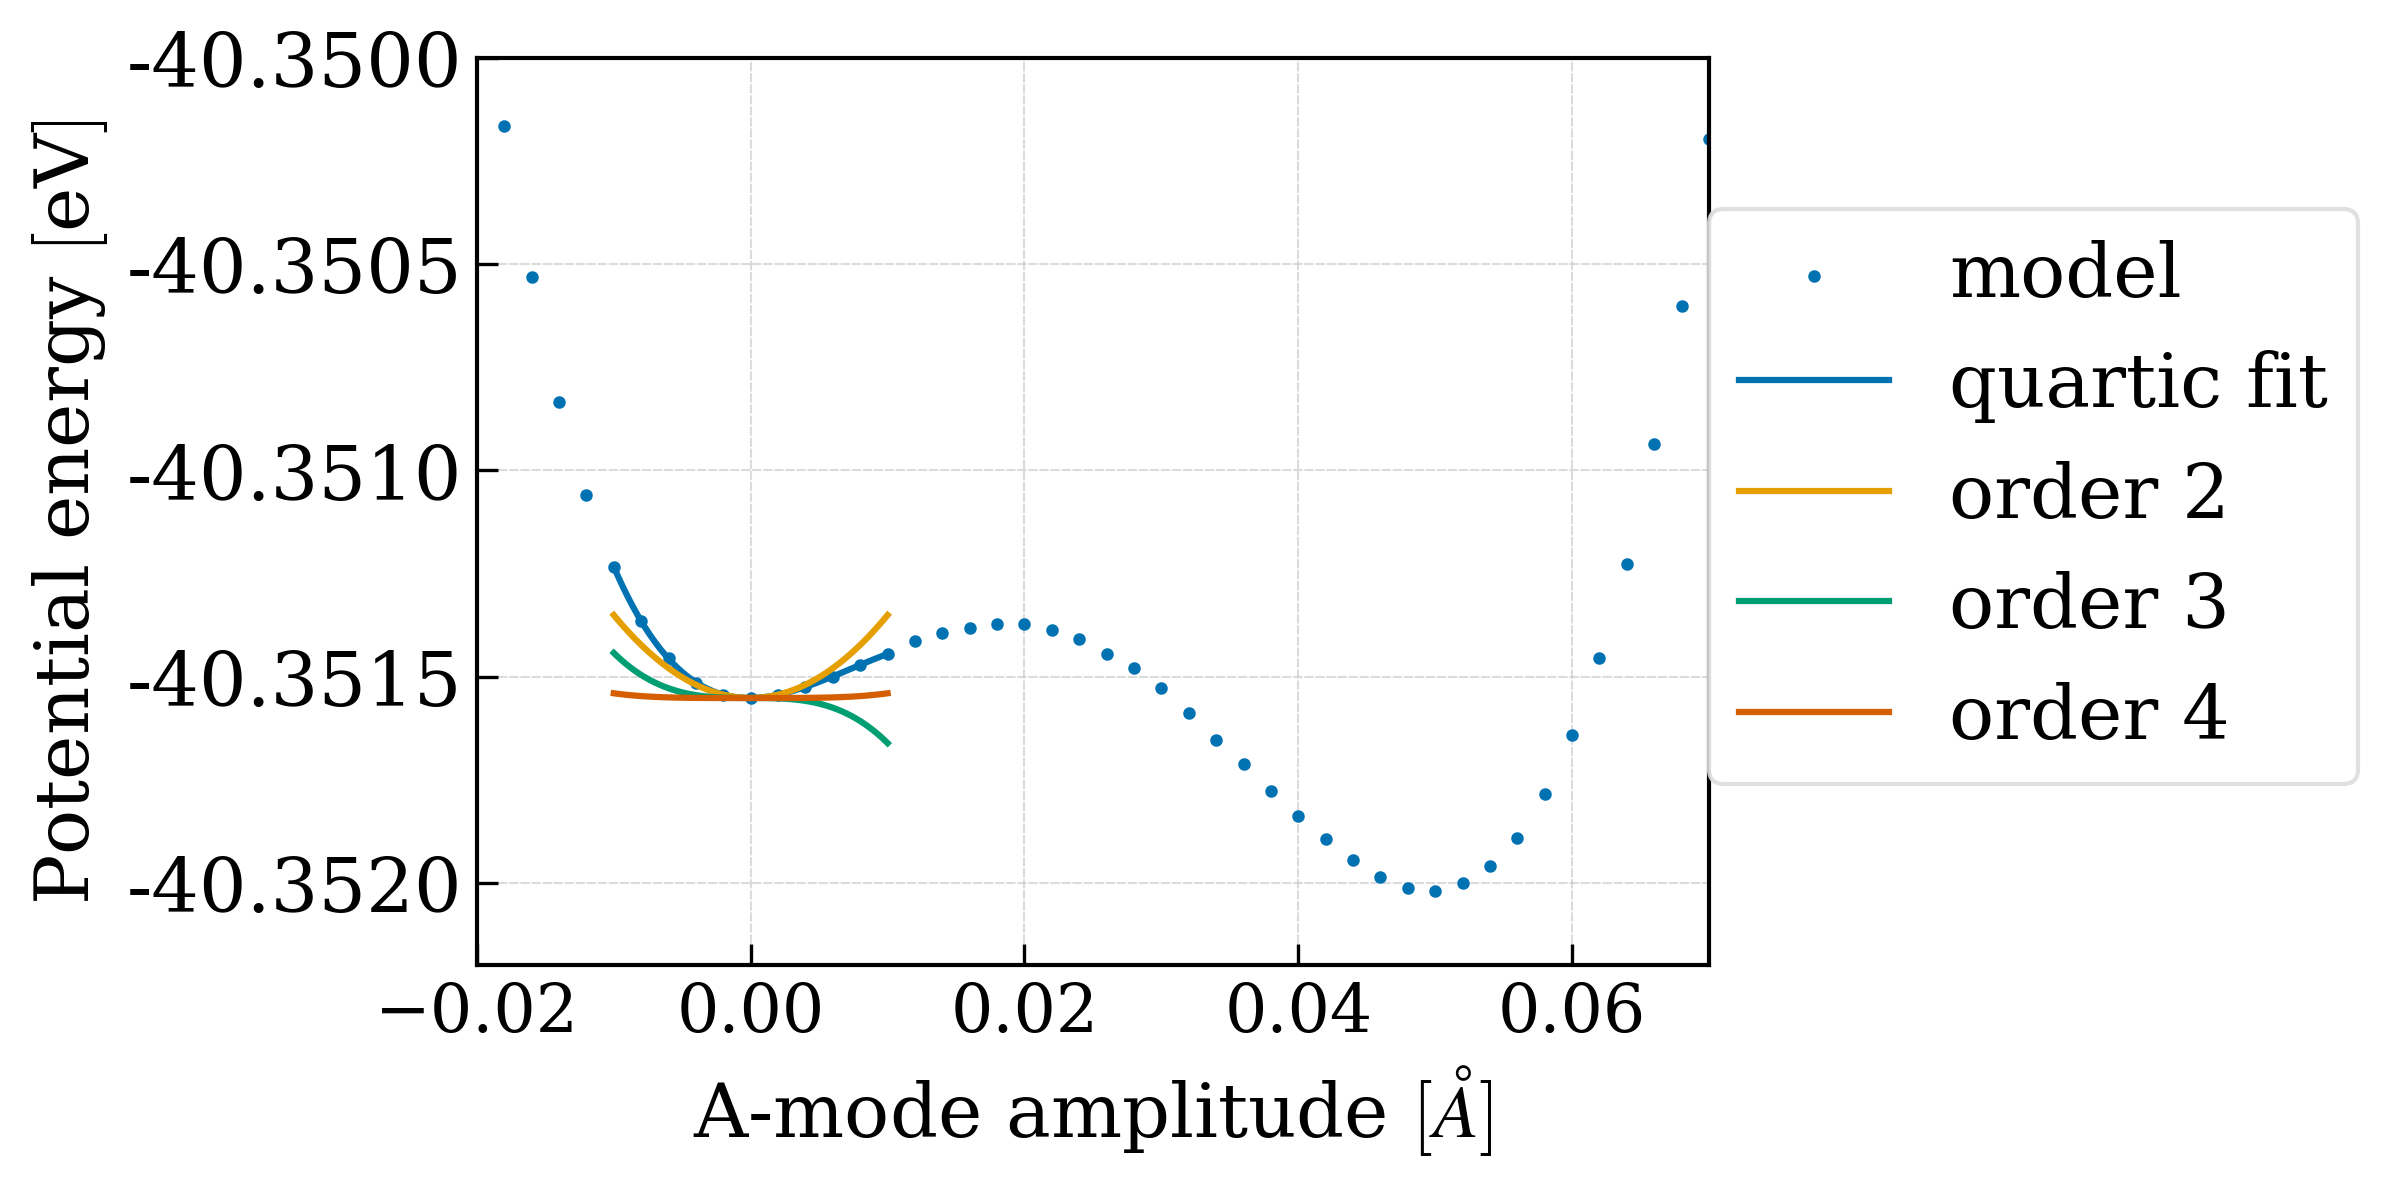

In [88]:
fig, ax = plt.subplots(1, 1, figsize = (8, 4))


energies = AMODE_ENERGIES_ZOOM[list(AMODE_ENERGIES_ZOOM.keys())[47]]
mine = np.min(energies)
plt.xlim(-0.02, 0.07)

plt.scatter(AMODE_ENERGIES_ZOOM['amplitudes'], energies, label = "model")

coeffs, covar = np.polyfit(AMODE_ENERGIES_ZOOM['amplitudes'][45:55], energies[45:55], 4, cov=True)

from numpy import poly1d

support = np.linspace(-0.01, 0.01, 101, endpoint=True)
fit = poly1d(coeffs)
ys = fit(support)

parabola = coeffs[-1] + coeffs[-3]*support**2
thirdorder = coeffs[-1] + coeffs[-4] * support**3
fourthorder = coeffs[-1] + coeffs[-5]*support**4

plt.plot(support, ys, label = "quartic fit")
plt.plot(support, parabola, label="order 2")
plt.plot(support, thirdorder, label = "order 3")
plt.plot(support, fourthorder, label = "order 4")

plt.xlabel(r"A-mode amplitude $[\AA]$")
plt.ylabel(r"Potential energy $[$eV$]$")

ymin, ymax = -40.3522, -40.35
yticks = np.linspace(-40.352, ymax, 5)
ytickslabels = [f"{yt:.4f}" for yt in yticks]
plt.yticks(yticks, ytickslabels)
plt.ylim(ymin, ymax)


plt.legend(loc = (1, 0.2))
plt.tight_layout()

plt.savefig("MF_AmodeZoom.pdf")

In [ ]:
coeffs

array([ 7.29427486e+02, -1.07399511e+02,  3.39704793e-01, -6.78020209e-05,
       -4.01587336e+01])

In [ ]:
from scipy.constants import atomic_mass, elementary_charge, hbar

In [ ]:
der2 = coeffs[-3] * 2
conv = (1 / np.sqrt(elementary_charge)) * 1e10 * np.sqrt(1/atomic_mass)
energy = np.sign(der2) * hbar * np.sqrt(np.abs(der2) / 12.011) * conv

In [ ]:
der2_diff = (
        np.abs(AMODE_ENERGIES_ZOOM[list(AMODE_ENERGIES_ZOOM.keys())[32]][-1] + AMODE_ENERGIES_ZOOM[list(AMODE_ENERGIES_ZOOM.keys())[32]][0] - 2*coeffs[-1])
    ) / (0.01**2)


In [ ]:
energy_diff = (
    np.sign(AMODE_ENERGIES_ZOOM[list(AMODE_ENERGIES_ZOOM.keys())[32]][-1] + AMODE_ENERGIES_ZOOM[list(AMODE_ENERGIES_ZOOM.keys())[32]][0] - 2*coeffs[-1]) * 
    hbar * np.sqrt(der2_diff / 12.011) * conv
)

In [ ]:
energy_diff

np.float64(-0.011782652532647795)

In [ ]:
energy

np.float64(-0.014566496801379943)

In [ ]:
strains_zoom[32] * np.sqrt(2)

np.float64(0.21616161616161617)

In [ ]:
get_second_derivative_at_zero(AMODE_ENERGIES_ZOOM['amplitudes'], AMODE_ENERGIES_ZOOM[str(0.1528493446201224)])

(np.float64(10.410944623221296), np.float64(0.2725070459508608))

In [ ]:
strains_zoom = [float(k) for k in AMODE_ENERGIES_ZOOM.keys() if k != "amplitudes"]
second_derivatives = []
uncertainties = []
for strain in strains_zoom:
    second_derivative, unc = get_second_derivative_at_zero(AMODE_ENERGIES_ZOOM['amplitudes'], AMODE_ENERGIES_ZOOM[str(strain)], window_size=11)
    second_derivatives.append(second_derivative)
    uncertainties.append(unc)

In [ ]:
def find_x_intercept(x, y, yerr, xlim=[-np.inf, np.inf]):
    """
    Performs weighted linear regression centered around the data's center of mass.
    Returns the x-axis intercept and its propagated uncertainty.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    yerr = np.asarray(yerr)

    # Filter data within the specified x-limits
    mask = (x > xlim[0]) & (x < xlim[1])
    x_filtered = x[mask]
    y_filtered = y[mask]
    yerr_filtered = yerr[mask]

    # Safety check
    if len(x_filtered) < 2:
        print("Warning: Not enough points in the specified xlim to perform regression.")
        return np.nan, np.nan, np.nan, np.nan

    # Avoid division by zero in weights
    if np.any(yerr_filtered == 0):
        yerr_filtered = np.where(yerr_filtered == 0, 1e-10, yerr_filtered)
        
    weights = 1.0 / yerr_filtered

    # Shift x to center of mass to decorrelate slope and intercept
    x_center = np.mean(x_filtered)
    x_shifted = x_filtered - x_center

    # Fit y = m * x_shifted + b
    # np.polyfit returns coefficients in descending order: [m, b]
    (m, b), cov = np.polyfit(x_shifted, y_filtered, 1, w=weights, cov=True)

    if m == 0:
        return np.nan, m, b, np.nan

    # Variances and covariance from the shifted fit
    var_m = cov[0, 0]
    var_b = cov[1, 1]
    cov_mb = cov[0, 1] # This will be very close to 0 because of the shift

    # 1. Calculate the shifted x-intercept (where y = 0)
    # 0 = m * x_intercept_shifted + b  =>  x_intercept_shifted = -b / m
    x_int_shifted = -b / m

    # 2. Shift back to absolute x-coordinates
    x_intercept = x_int_shifted + x_center

    # 3. Propagate uncertainty using the multivariate Delta Method
    # Let f(m, b) = -b / m
    # Partial derivatives:
    df_dm = b / (m**2)
    df_db = -1 / m

    # Standard error propagation formula for a function of two correlated variables:
    var_x_int = (df_dm**2 * var_m) + (df_db**2 * var_b) + (2 * df_dm * df_db * cov_mb)
    x_intercept_err = np.sqrt(var_x_int)

    # Reconstruct the traditional absolute intercept (c) for the output if needed
    # y = m(x - x_center) + b  =>  y = mx + (b - m * x_center)
    c = b - m * x_center

    return x_intercept, x_intercept_err, m, c

In [ ]:
intercept, intercept_unc, m, c = find_x_intercept(strains_zoom, second_derivatives, uncertainties, [0.2204/np.sqrt(2), 0.2344/np.sqrt(2)]) 
print(intercept, intercept_unc)

0.1608451055255441 2.2709805366614092e-05


In [ ]:
strains_zoom = np.array(strains_zoom)

<>:12: SyntaxWarning: invalid escape sequence '\p'


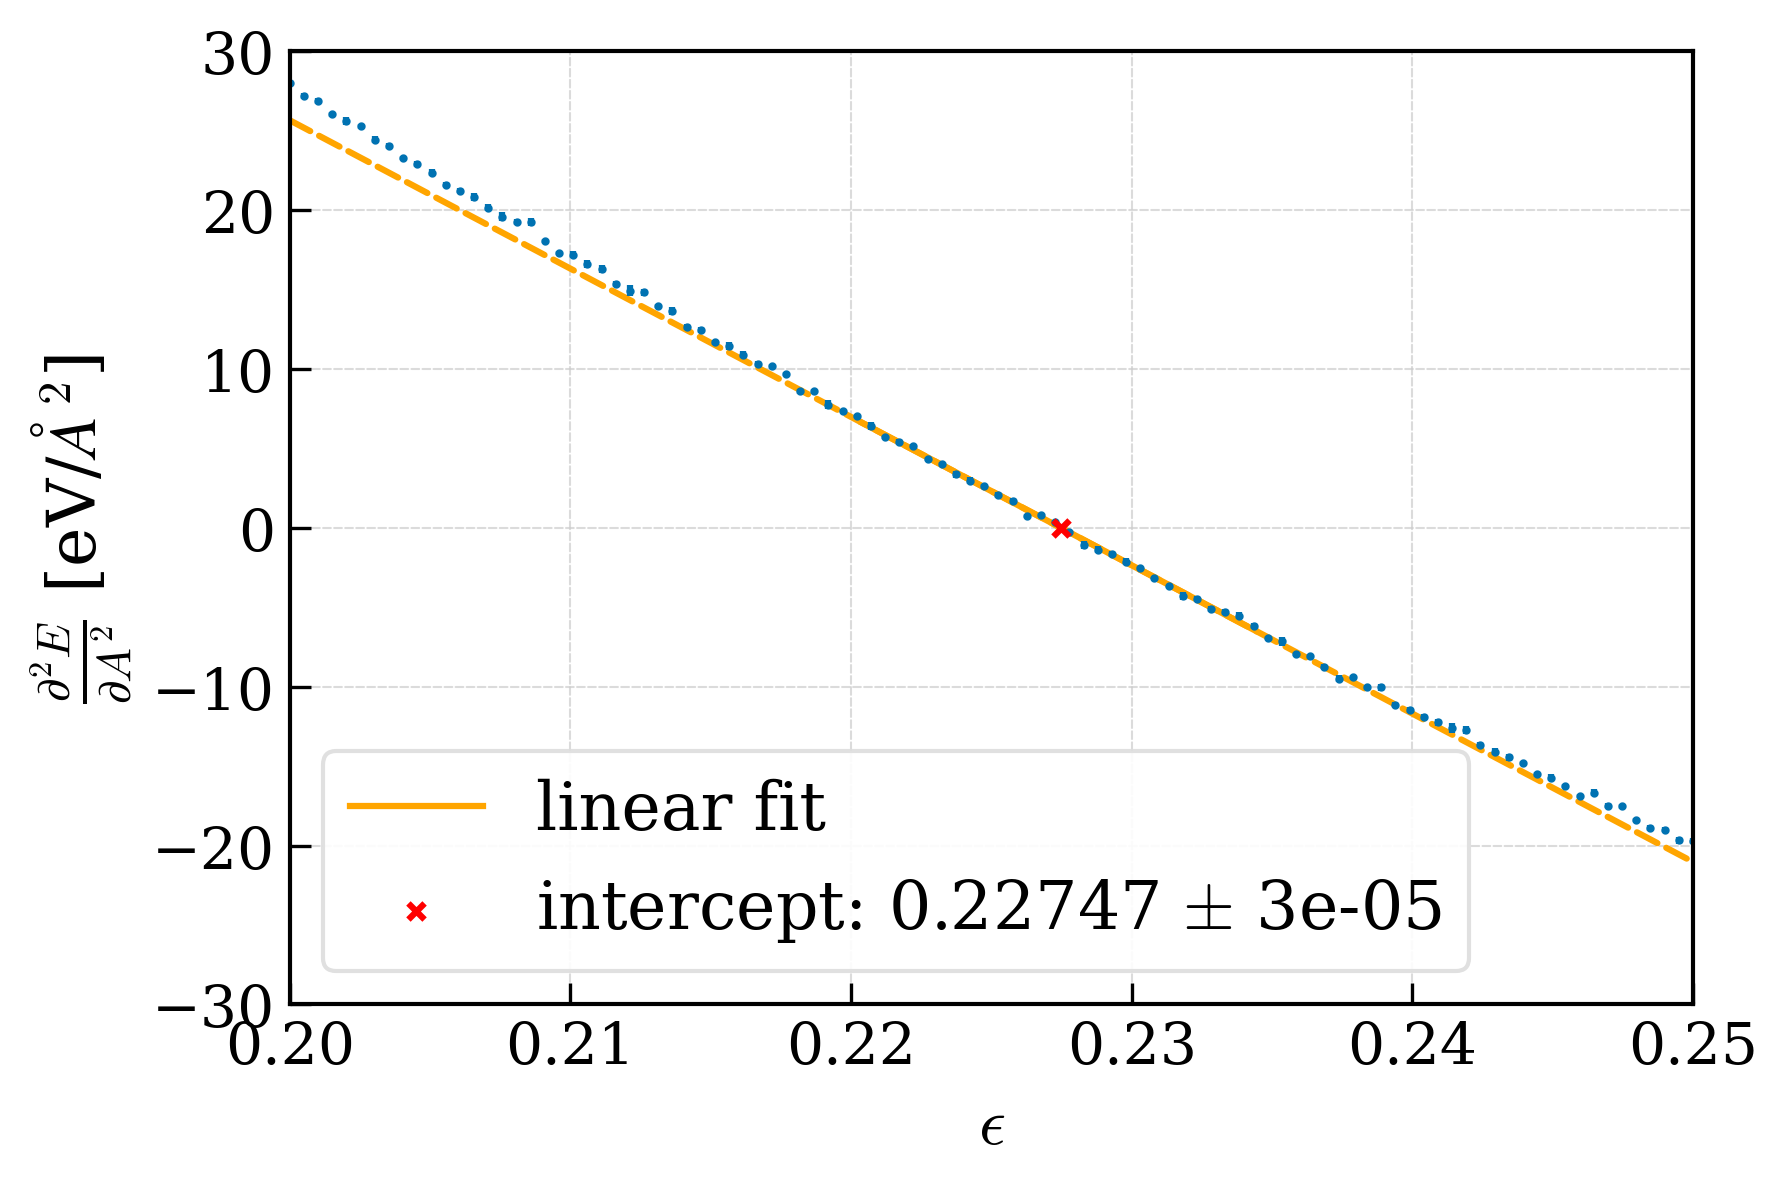

In [ ]:
xs = np.linspace(0.2204/np.sqrt(2), 0.2344/np.sqrt(2), 2)
ys = m*xs + c

xe = np.linspace(0.2/np.sqrt(2), 0.250/np.sqrt(2), 2)
ye = m*xe + c

plt.plot(xs*np.sqrt(2), ys, label = "linear fit", color = "orange")
plt.plot(xe*np.sqrt(2), ye,"--", color = "orange")

plt.errorbar(strains_zoom*np.sqrt(2), second_derivatives, yerr = uncertainties, fmt = ".", s=0.1)
plt.xlabel(r"$\epsilon$", fontsize = 16)
plt.scatter(intercept*np.sqrt(2), 0, marker="x", color="red", label = f"intercept: {intercept*np.sqrt(2):.5f} $\pm$ {intercept_unc*np.sqrt(2):.0e}", s = 15, zorder = 3)
plt.legend(loc = "lower left")
plt.ylabel(r"$\frac{\partial^2 E}{\partial A^2}$ [eV/$\AA^2$]", fontsize = 16)
plt.xlim(0.20, 0.25)
plt.ylim(-30, 30)
plt.grid(True)

plt.tight_layout()
plt.savefig("MF_linear_fit.pdf")

In [67]:
AS = np.linspace(-0.3, 0.6, 50)
BS = np.linspace(-0.3, 0.3, 50)
strains = np.linspace(0, 0.25, num=10)
deformations = [ID + np.array([[s, 0, 0], [0, s, 0], [0, 0, 0]]) for s in strains]

moddel = MACECalculator("../../MACE.model", device = "cuda")

AMODE = AMode()
BMODE = BMode()

GRID_DATA = {}

GRID_DATA['AS'] = AS
GRID_DATA['BS'] = BS
GRID_DATA['DATA'] = {}

for strain, deformation in tqdm(zip(strains, deformations)):
    cell = KCELL0 @ deformation
    strained_atoms = katoms.copy()
    strained_atoms.set_cell(cell, scale_atoms=True)

    energies = np.zeros(shape=(len(AS), len(BS)))
    for ia, A in enumerate(AS):
        amodded = AMODE.apply(strained_atoms, A)
        for ib, B in enumerate(BS):
            bmodded = BMODE.apply(amodded, B)
            bmodded.calc = model
            energies[ia, ib] = bmodded.get_potential_energy()

    GRID_DATA['DATA'][strain] = energies

/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  wa

Using head Default out of ['Default']
No dtype selected, switching to float32 to match model dtype.


10it [11:10, 67.00s/it]


In [68]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np

def plot_grid_data_to_pdf(grid_data, filename="energy_surfaces_unique_scales.pdf"):
    AS = grid_data['AS'].astype(float)
    BS = grid_data['BS'].astype(float)
    strains_data = grid_data['DATA']
    
    extent = [BS.min(), BS.max(), AS.min(), AS.max()]

    with PdfPages(filename) as pdf:
        # Sort strains numerically for the PDF order
        for strain in sorted(strains_data.keys()):
            energies = strains_data[strain].astype(float)
            strain = float(strain)  # Ensure it's a float for calculations

            
            # --- UNIQUE SCALE CALCULATION ---
            # Every page gets its own color limits
            local_min = np.min(energies)
            local_max = local_min + 1 
            
            fig, ax = plt.subplots(figsize=(8, 8))
            
            # We use 'plasma' or 'viridis' for high contrast
            im = ax.imshow(
                energies, 
                extent=extent, 
                origin='lower', 
                aspect='auto', 
                cmap='plasma',
                vmin=local_min, # Unique to this slice
                vmax=local_max  # Unique to this slice
            )
            ax.set_box_aspect(1)
            
            # Define contour levels within this unique 100-unit window
            levels = np.linspace(local_min, local_max, 15)
            ax.contour(BS, AS, energies, levels=levels, colors='white', alpha=0.1)
            
            # Add the colorbar - notice it will show different values on each page
            cbar = plt.colorbar(im, ax=ax)
            cbar.set_label('Potential Energy (eV)', rotation=270, labelpad=15)
            
            ax.set_title(f"Strain: {strain:.4f}")
            ax.set_xlabel("B-Mode Displacement")
            ax.set_ylabel("A-Mode Displacement")
            
            plt.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)
            
    print(f"PDF generated: {filename}. Each page has a unique colorscale.")

import os

from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_grid_data_to_svg(grid_data, output_dir="energy_surfaces_svg"):
    # Ensure the target directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    AS = grid_data['AS'].astype(float)
    BS = grid_data['BS'].astype(float)
    strains_data = grid_data['DATA']
    
    extent = [AS.min(), AS.max(), BS.min(), BS.max()]

    for strain in sorted(strains_data.keys()):
        energies = strains_data[strain].astype(float)
        energies = energies.T
        strain_val = float(strain)

        local_min = np.min(energies)
        local_max = local_min + 1 
        
        # 1. Changed figsize to a sensible square ratio since box_aspect=1 forces it anyway.
        # This prevents extreme whitespace padding in the final SVG container.
        fig, ax = plt.subplots(figsize=(12, 12))
        
        im = ax.imshow(
            energies, 
            extent=extent, 
            origin='lower', 
            aspect='auto', 
            cmap='plasma',
            vmin=local_min, 
            vmax=local_max  
        )
        
        ax.set_xlim(-0.3, 0.4)
        ax.set_ylim(-0.3, 0.3)
        ax.set_box_aspect(6/7)
        
        levels = np.linspace(local_min, local_max, 15)
        ax.contour(AS, BS, energies, levels=levels, colors='white', alpha=0.1)
        
        # 2. THE FIX: Explicitly divide the current axis to append the colorbar right next to it
        divider = make_axes_locatable(ax)
        # Pad controls the exact distance from the plot; size is the width of the colorbar
        cax = divider.append_axes("right", size="7%", pad="4%")
        
        # Pass the new 'cax' to the colorbar
        cbar = plt.colorbar(im, cax=cax)
        cbar.set_label('Potential Energy [eV]', rotation=270, labelpad=35, fontsize=40)
        cbar.ax.tick_params(labelsize=24) # Ensure the colorbar numbers are readable in the grid too
        
        # 3. Font scaling adjustments for grid readability
        ax.set_title(f"Strain: {strain_val*np.sqrt(2):.4f}", fontsize=40, pad=20)
        ax.set_ylabel(r"B-Mode Displacement [$\AA$]", fontsize=40, labelpad=15)
        ax.set_xlabel(r"A-Mode Displacement [$\AA$]", fontsize= 40, labelpad=15)
        
        # Scale up the primary axis numbers (ticks)
        ax.tick_params(axis='both', which='major', labelsize=24)
        
        plt.tight_layout()
        
        filename = f"strain_{strain_val:.4f}.svg"
        filepath = os.path.join(output_dir, filename)
        
        plt.savefig(filepath, format='svg', bbox_inches='tight')
        plt.close(fig)
            
    print(f"All images saved in SVG format inside the directory: '{output_dir}/'")

In [69]:
import json
with open("GRID_DATA.json", "r") as f:
    GRID_DATA = json.load(f, object_hook=numpy_hook)
plot_grid_data_to_pdf(GRID_DATA)
plot_grid_data_to_svg(GRID_DATA, "GRID_DATA")

PDF generated: energy_surfaces_unique_scales.pdf. Each page has a unique colorscale.
All images saved in SVG format inside the directory: 'GRID_DATA/'


In [70]:
plot_grid_data_to_svg(GRID_DATA, "GRID_DATA")

All images saved in SVG format inside the directory: 'GRID_DATA/'


In [71]:
plot_grid_data_to_pdf(GRID_DATA)

PDF generated: energy_surfaces_unique_scales.pdf. Each page has a unique colorscale.


In [72]:
with open("GRID_DATA.json", "w") as f:
    json.dump(GRID_DATA, f, cls=NumpyEncoder, indent = 2)

      Step     Time          Energy          fmax
BFGS:    0 16:16:54       -4.670726       61.191898
BFGS:    1 16:16:54      -12.356493        0.155970
BFGS:    2 16:16:54      -12.356650        0.144109
BFGS:    3 16:16:54      -12.357695        0.032898
BFGS:    4 16:16:54      -12.357775        0.019820
BFGS:    5 16:16:54      -12.357801        0.025447
BFGS:    6 16:16:55      -12.357870        0.047923
BFGS:    7 16:16:55      -11.814106       10.164392
BFGS:    8 16:16:55      -12.361569        0.536933
BFGS:    9 16:16:55      -12.371575        0.414335
BFGS:   10 16:16:55      -12.379523        0.496607
BFGS:   11 16:16:55      -12.402678        0.708757
BFGS:   12 16:16:55      -11.854670        9.594693
BFGS:   13 16:16:55      -12.438825        0.943357
BFGS:   14 16:16:55      -12.443842        0.967529
BFGS:   15 16:16:55      -12.112663        9.729298
BFGS:   16 16:16:55      -12.531822        1.561799
BFGS:   17 16:16:55      -12.580444        2.422287
BFGS:   18 16:

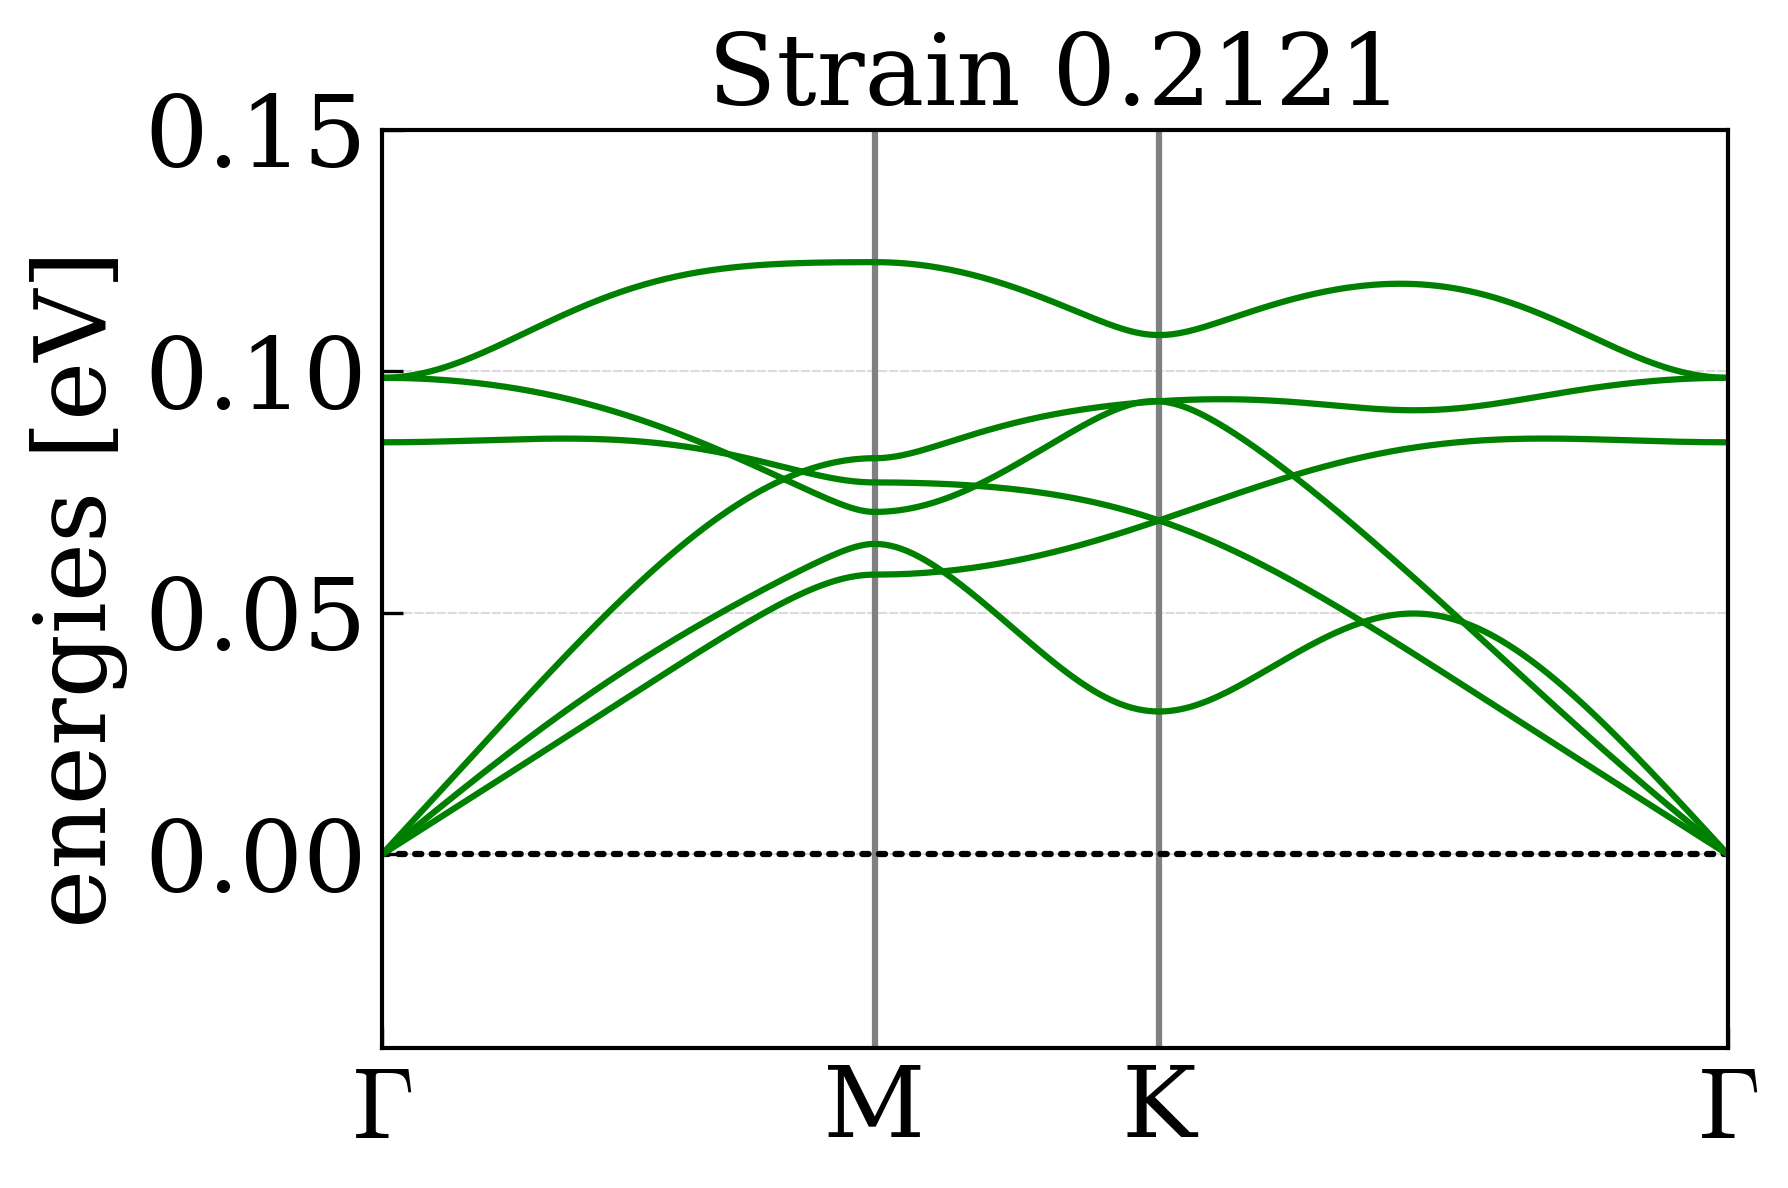

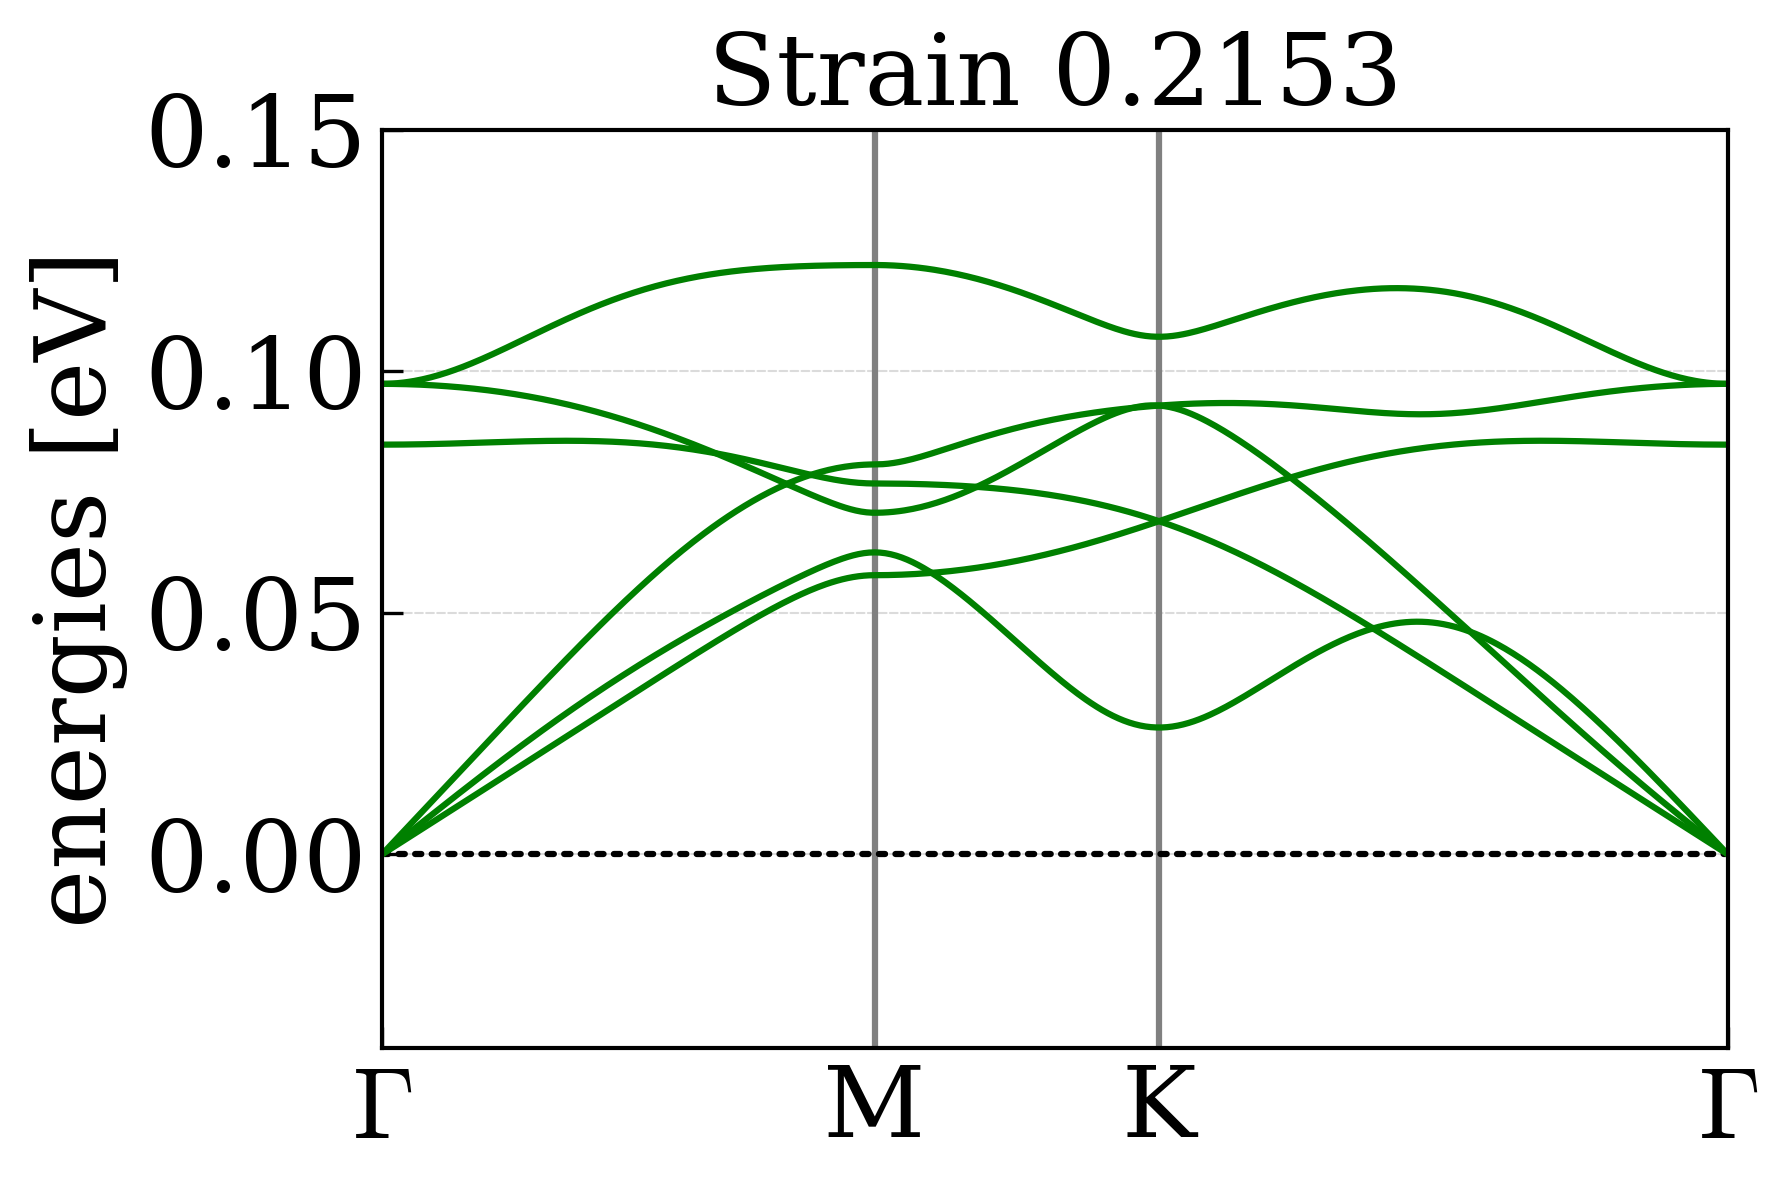

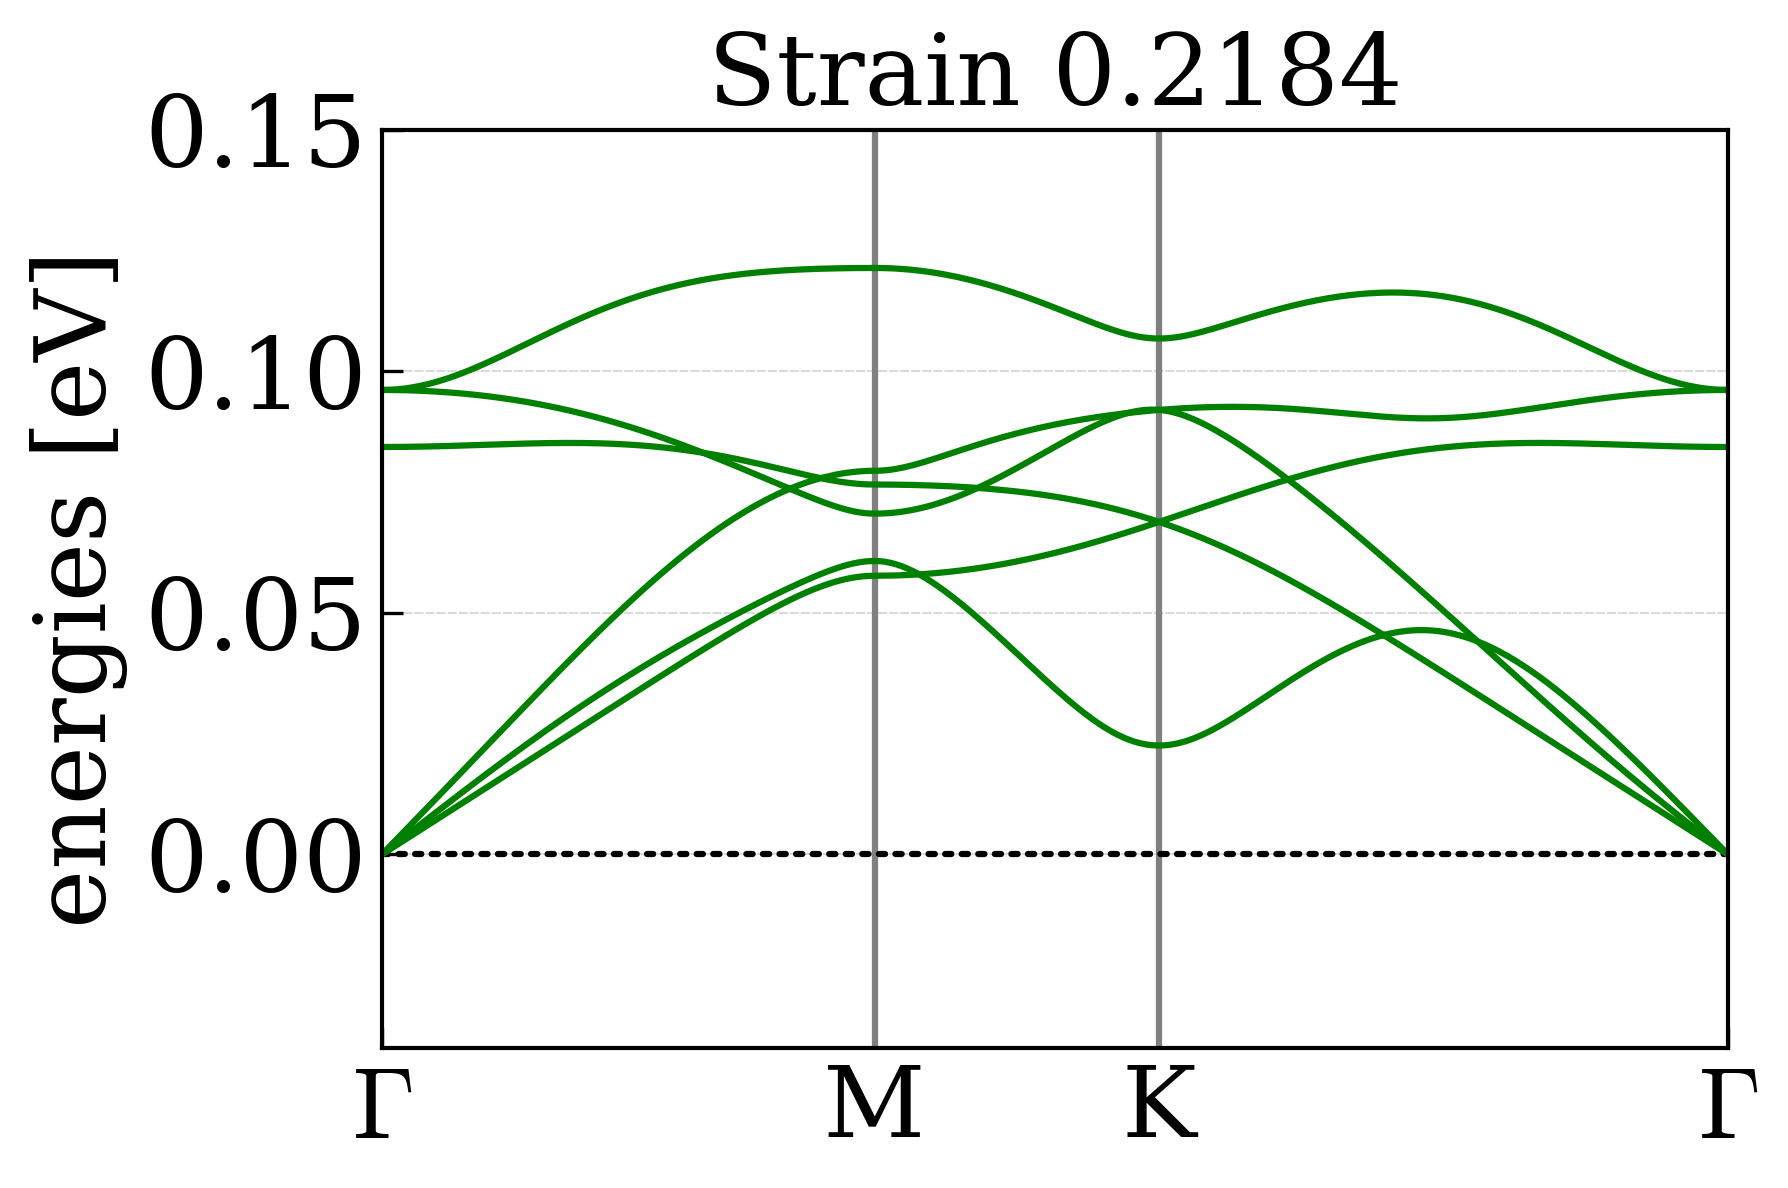

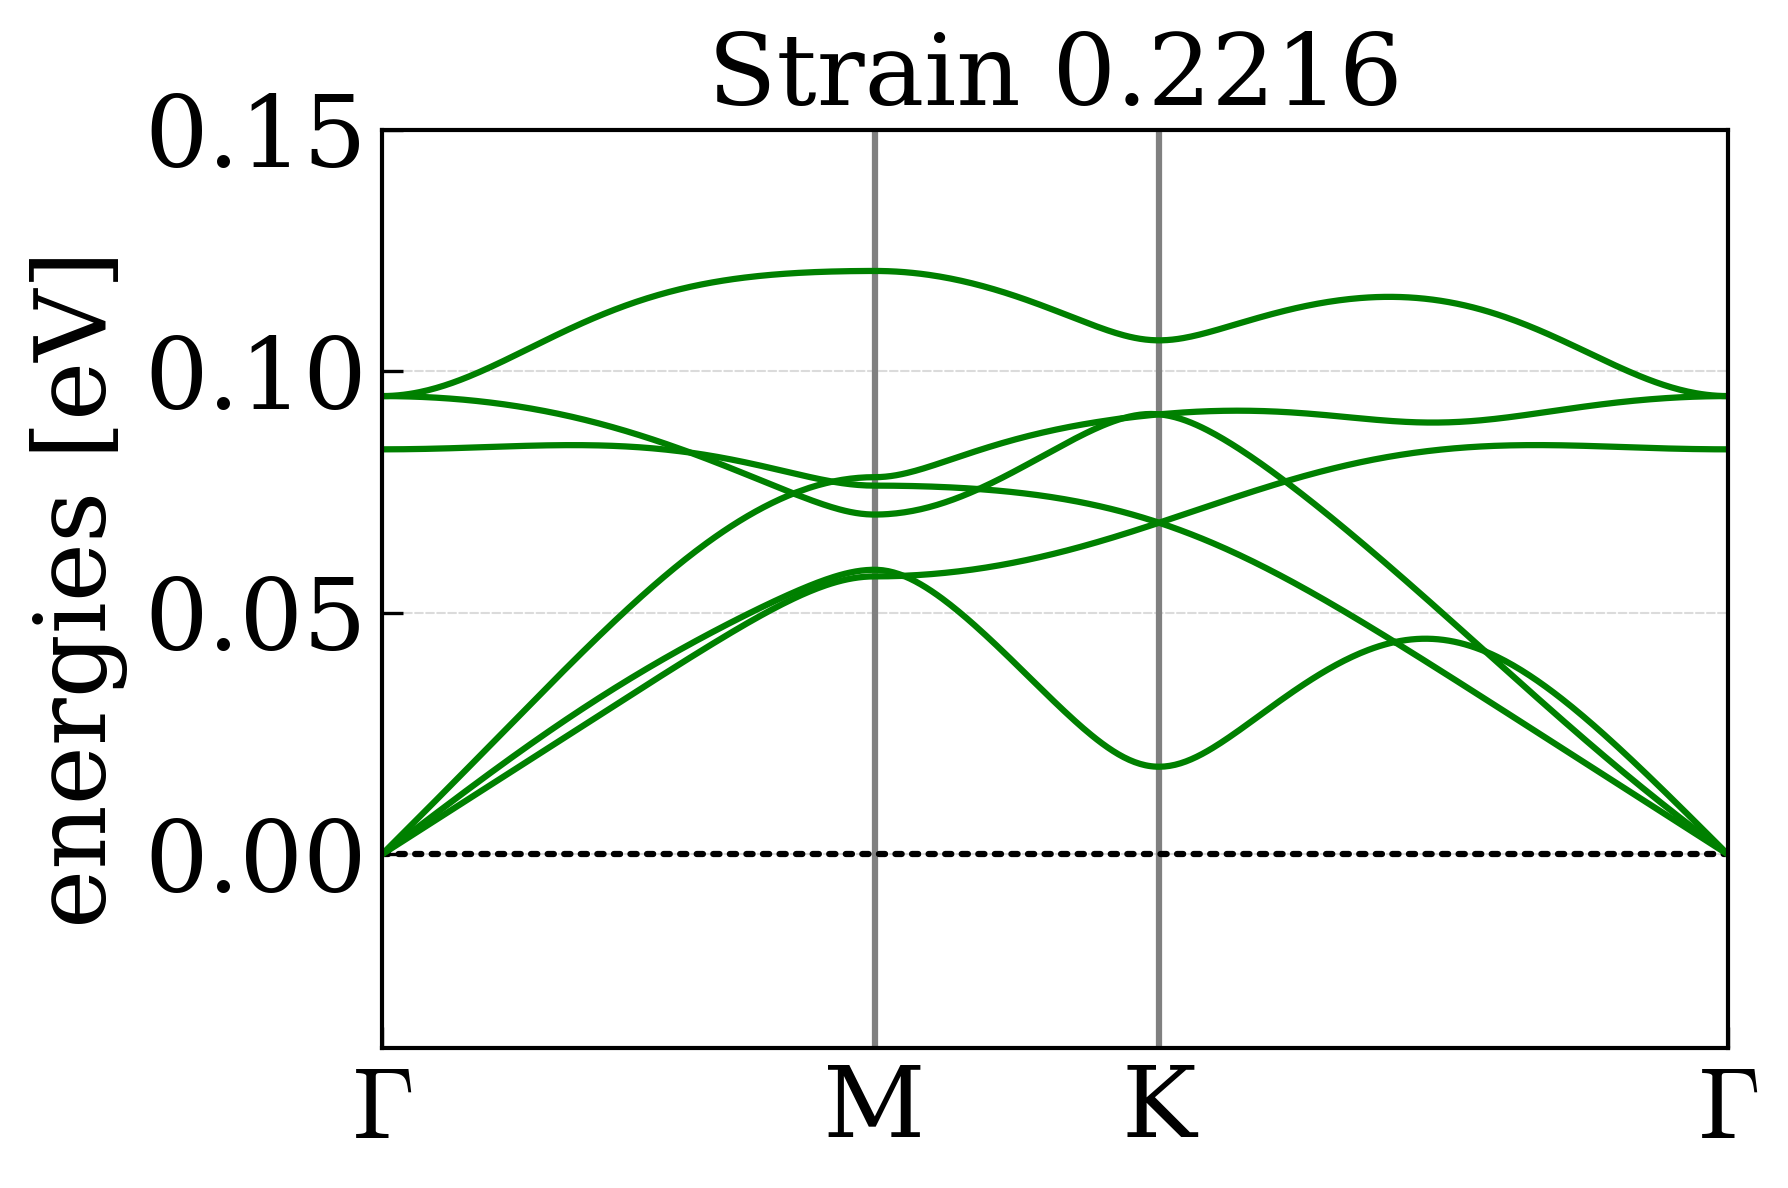

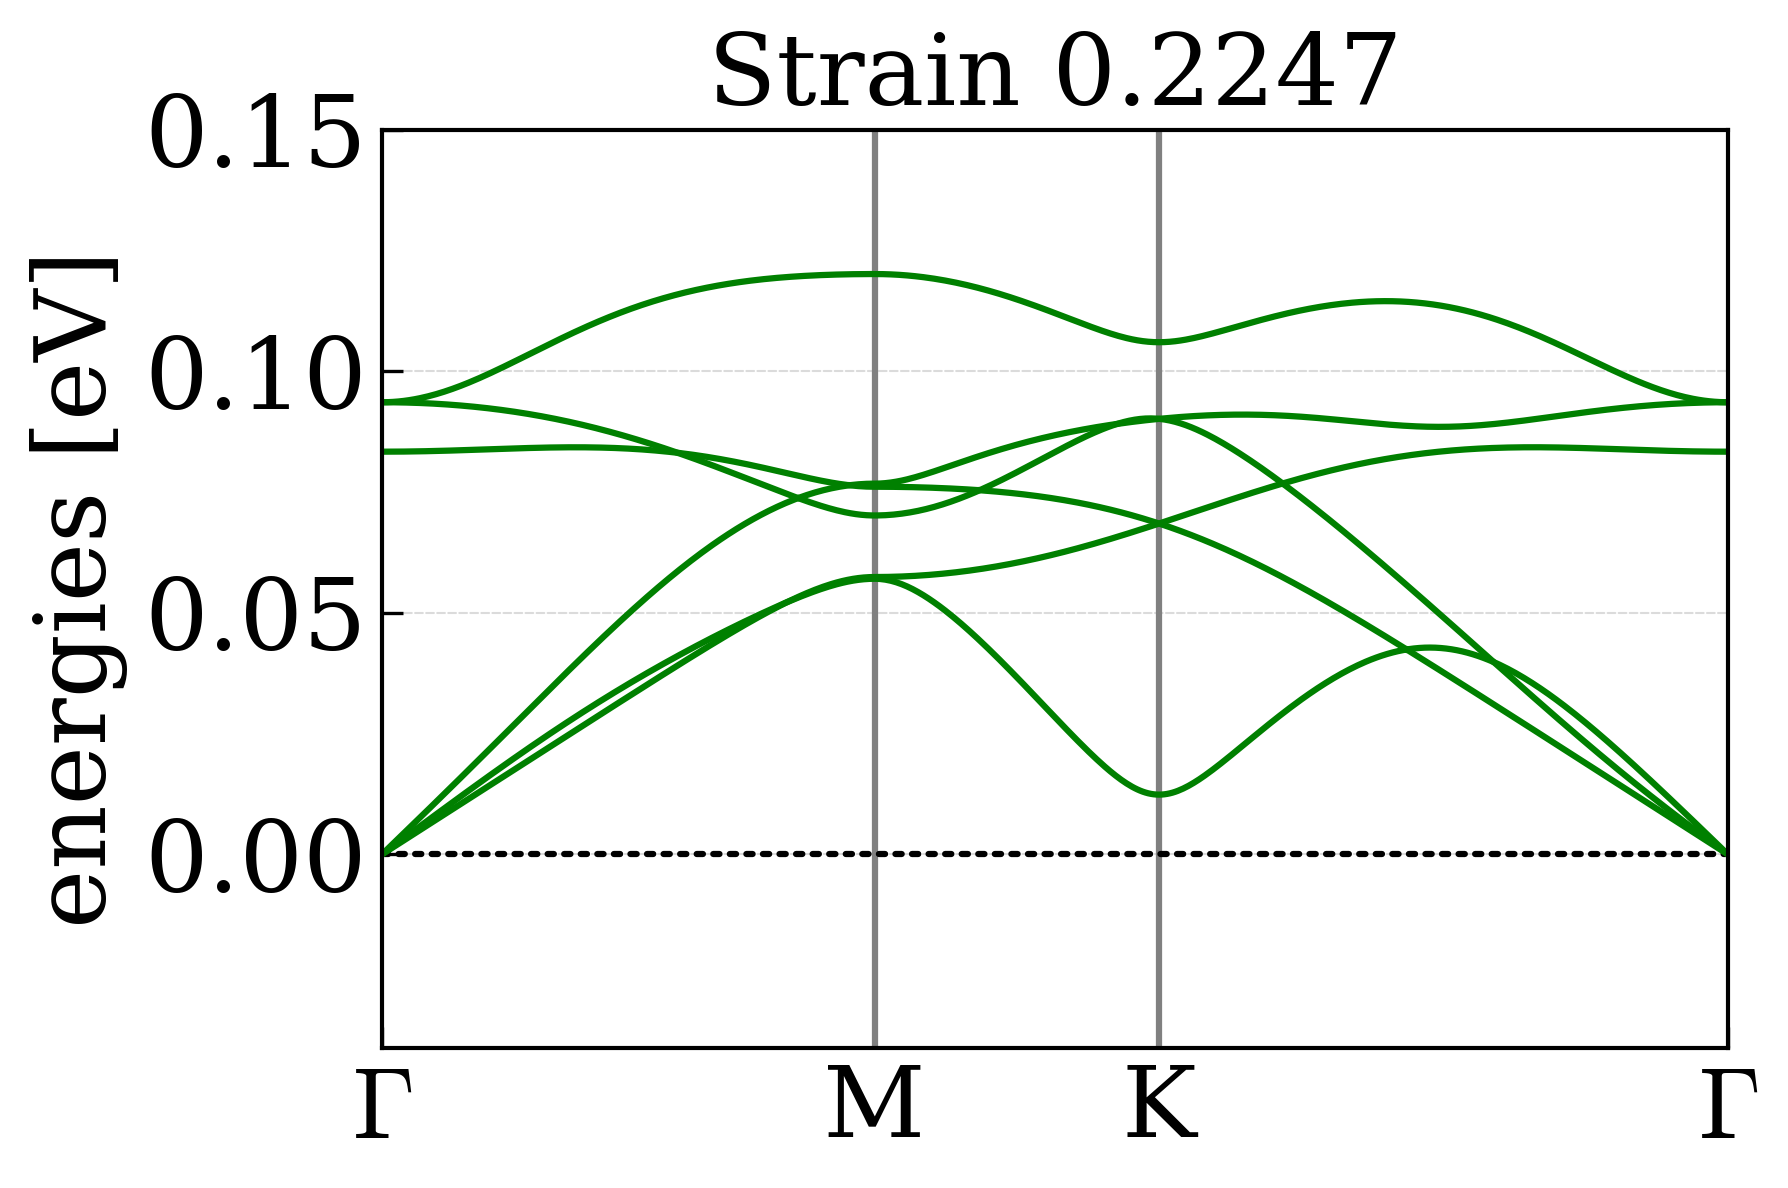

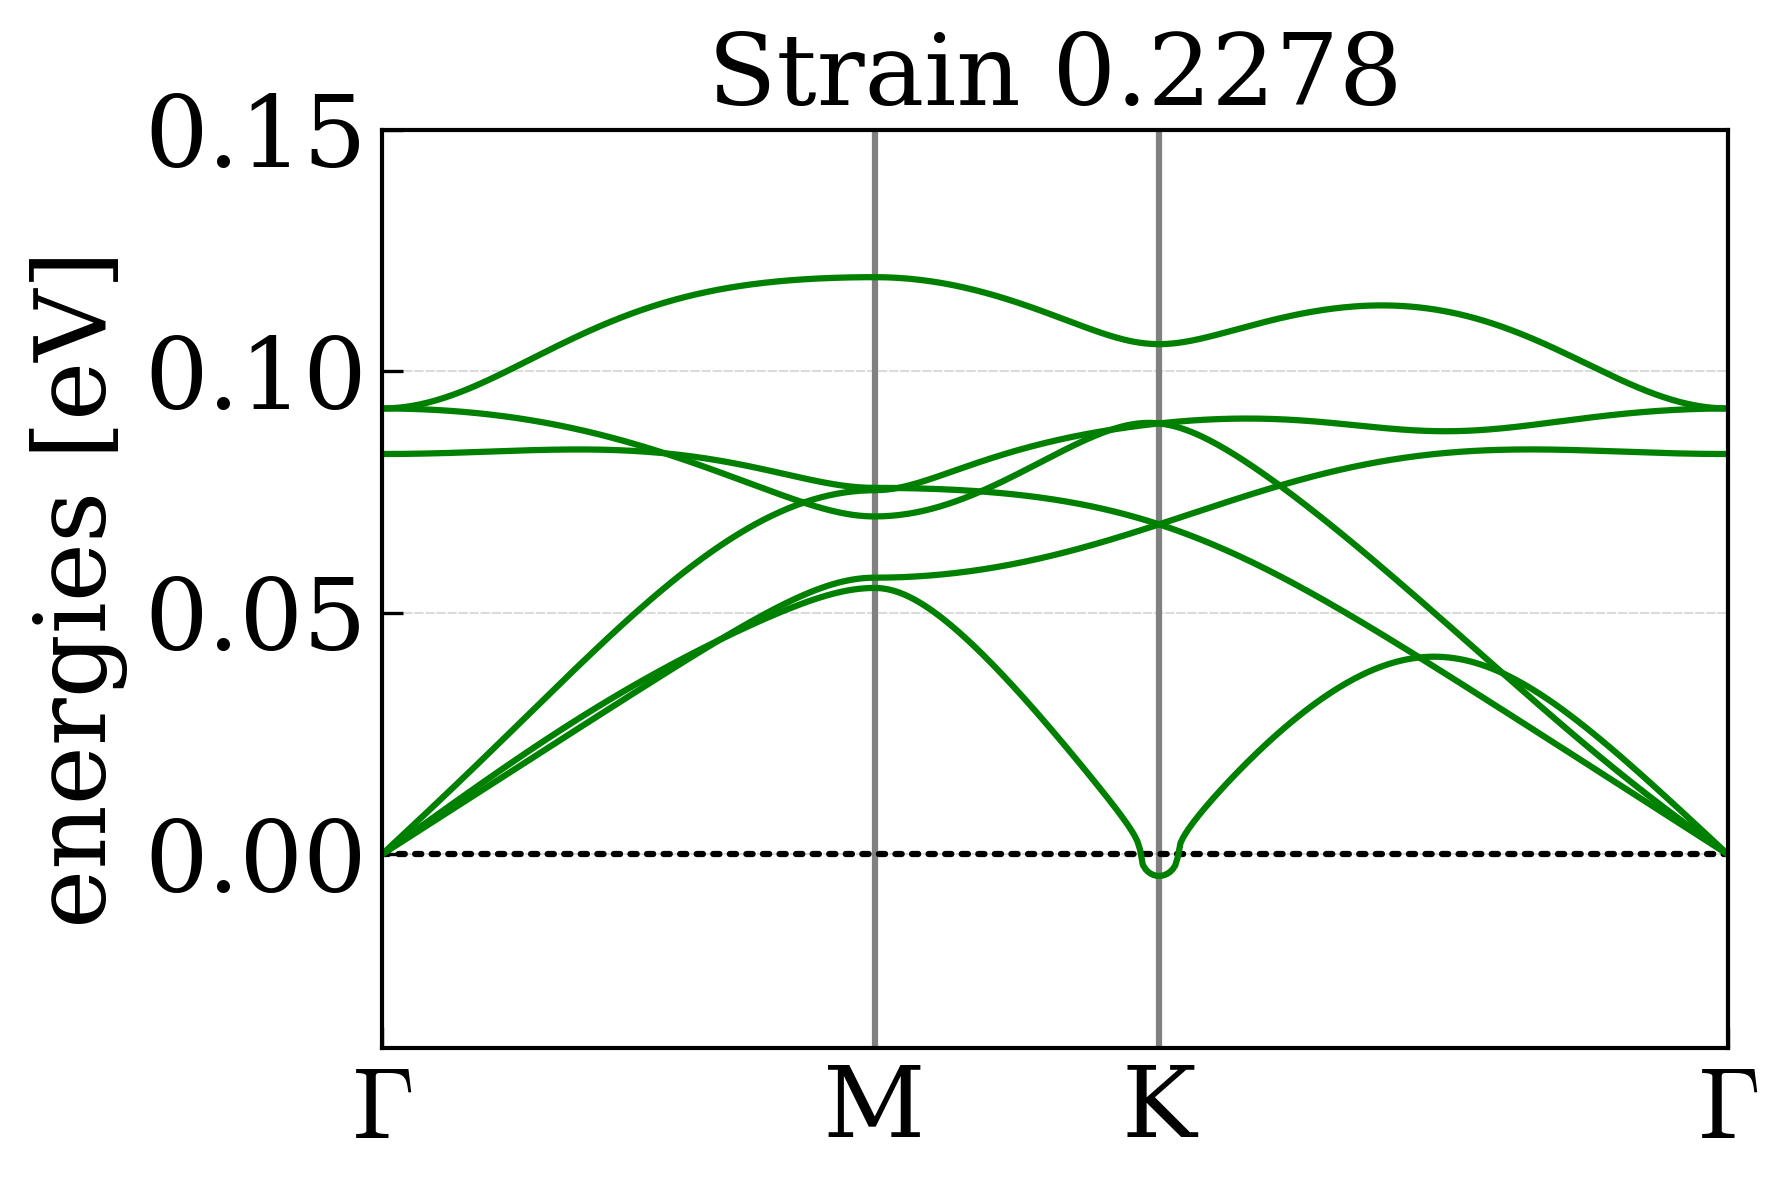

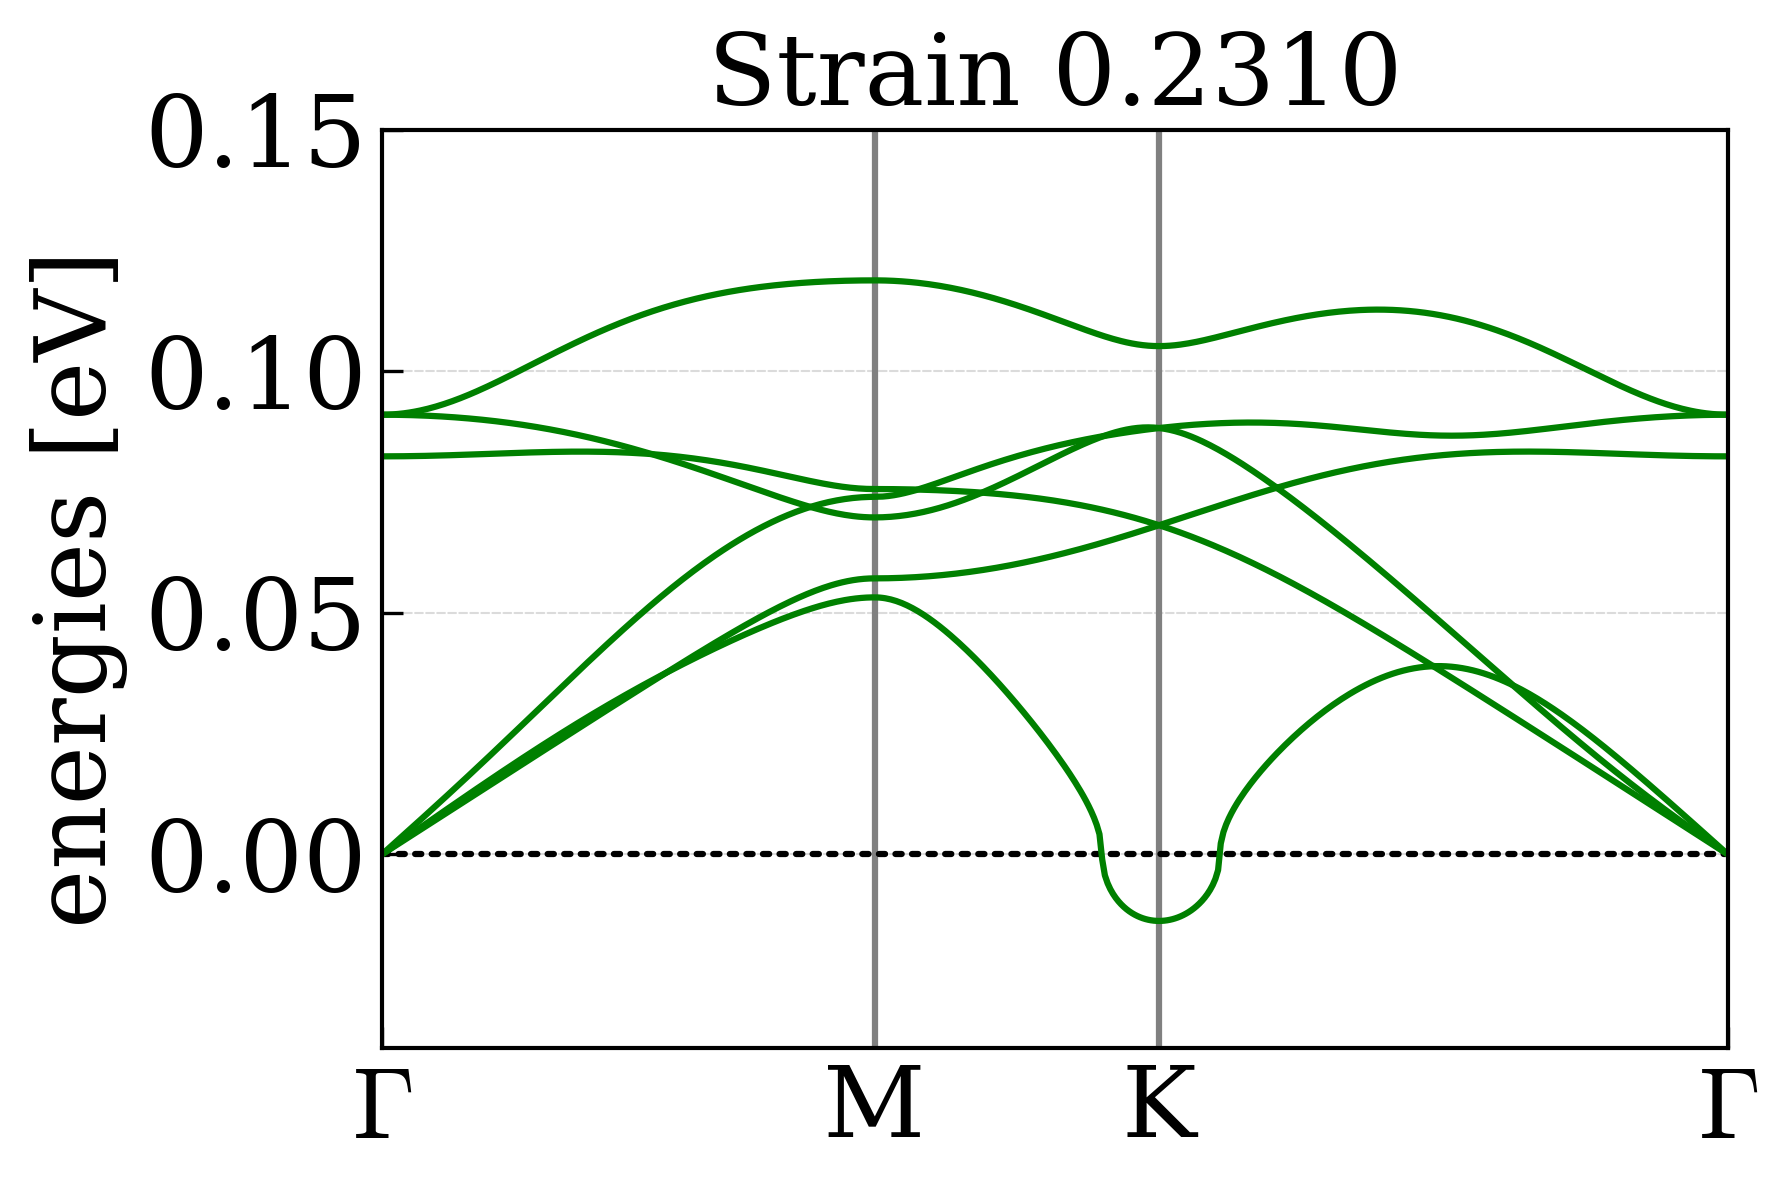

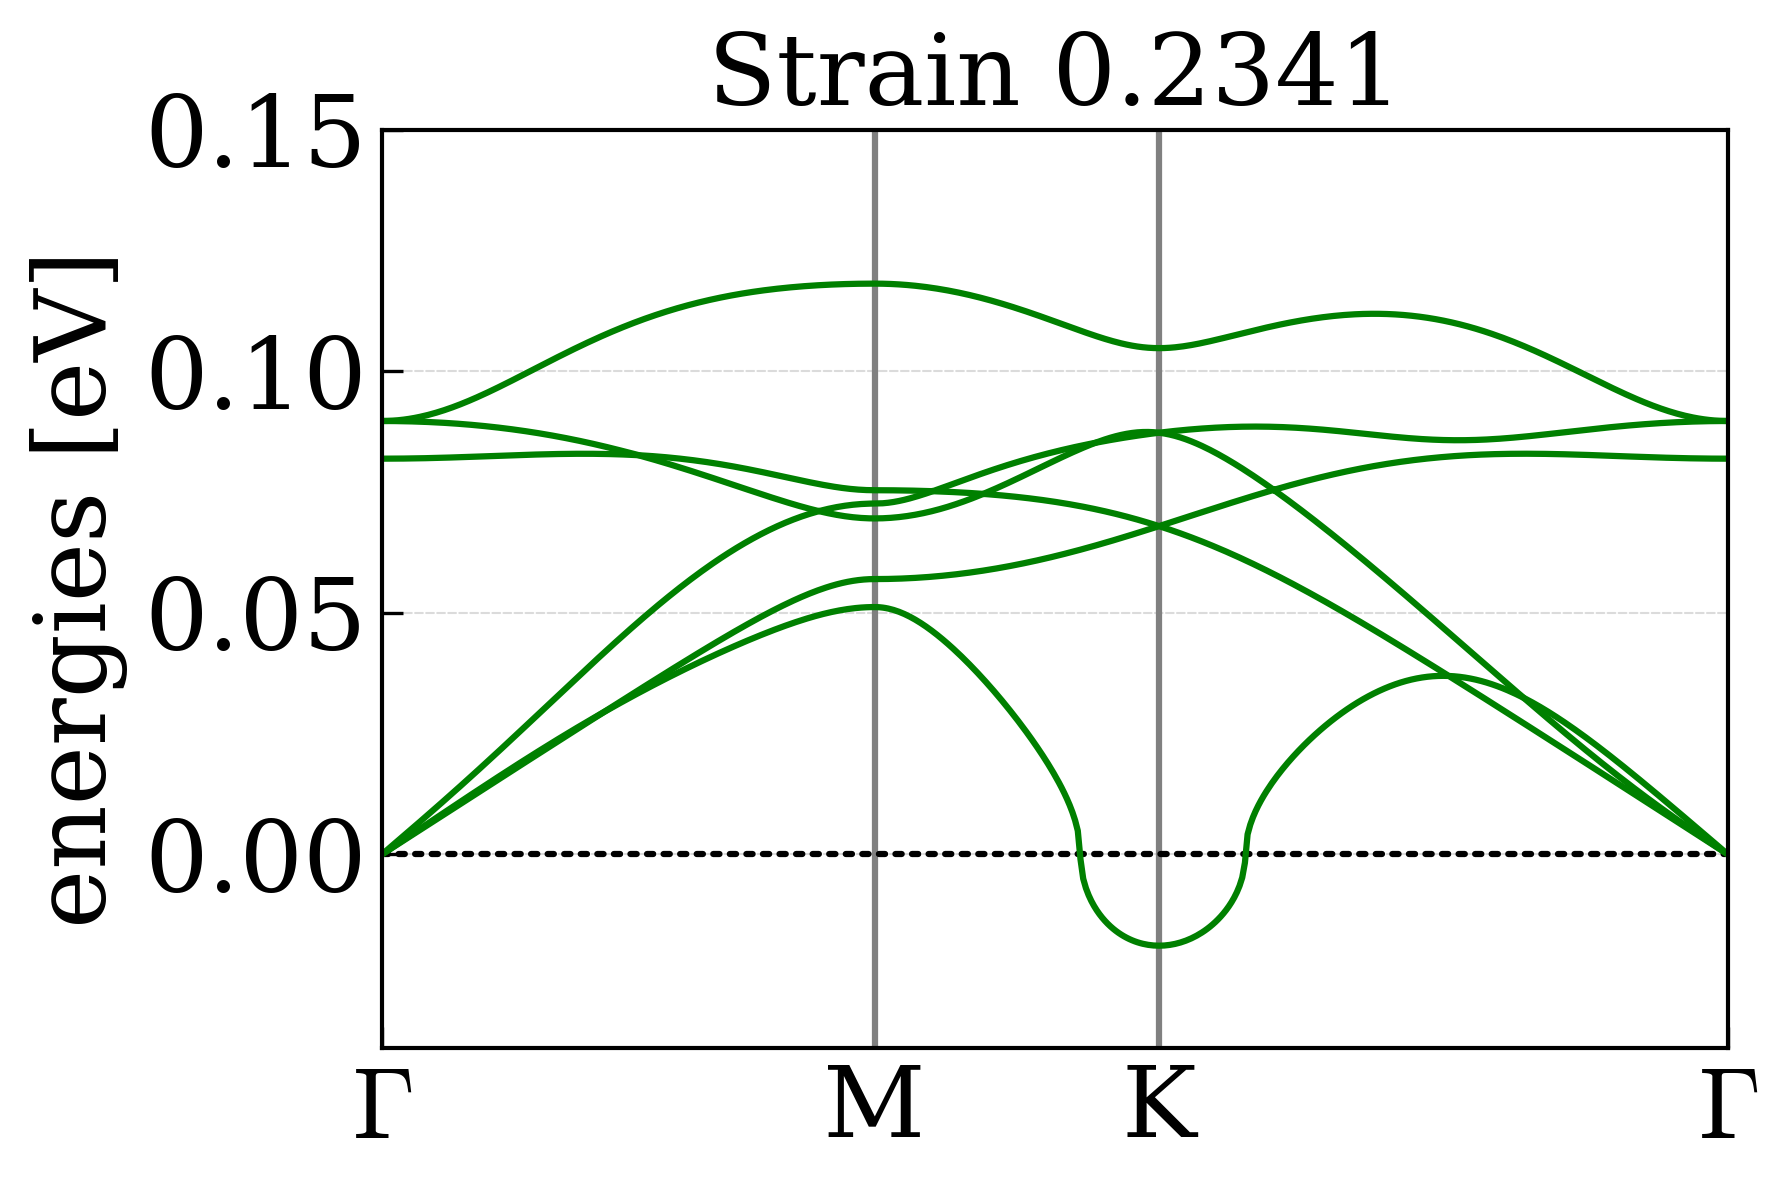

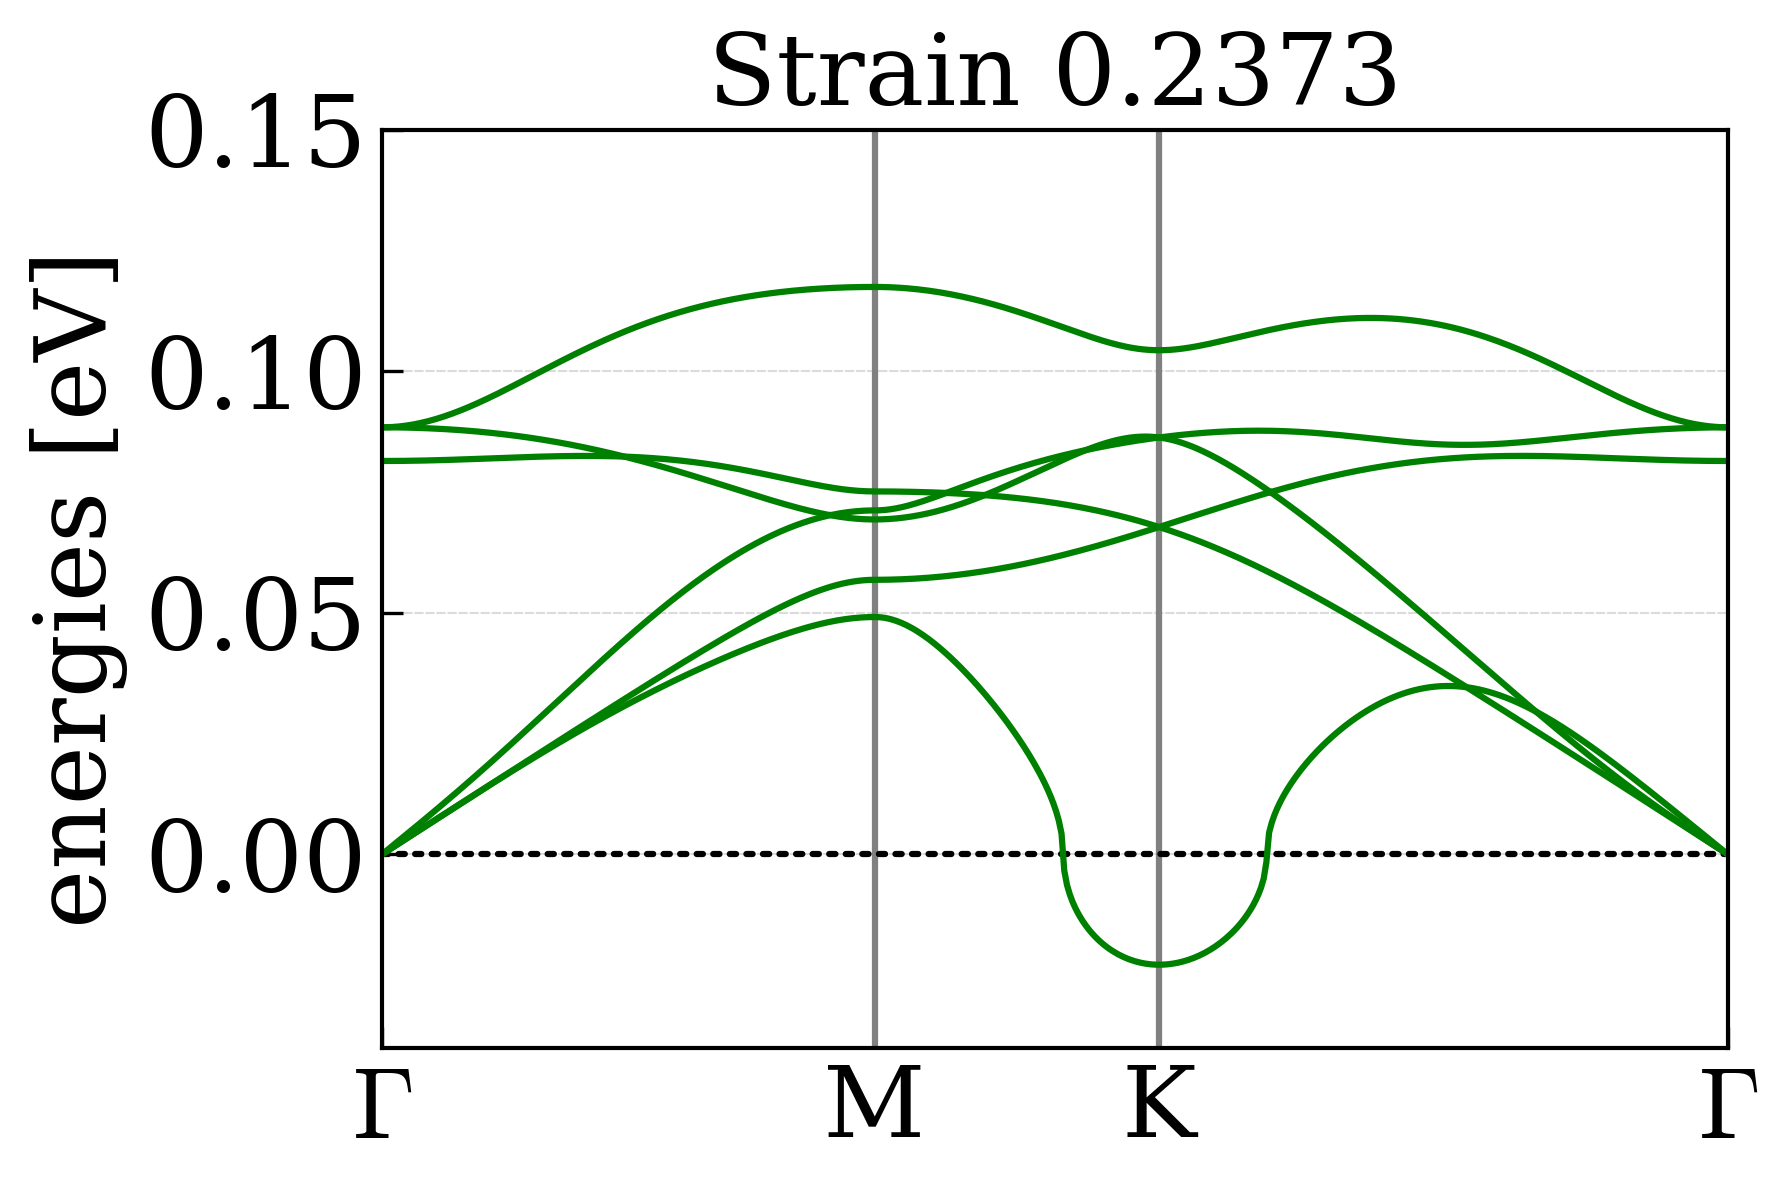

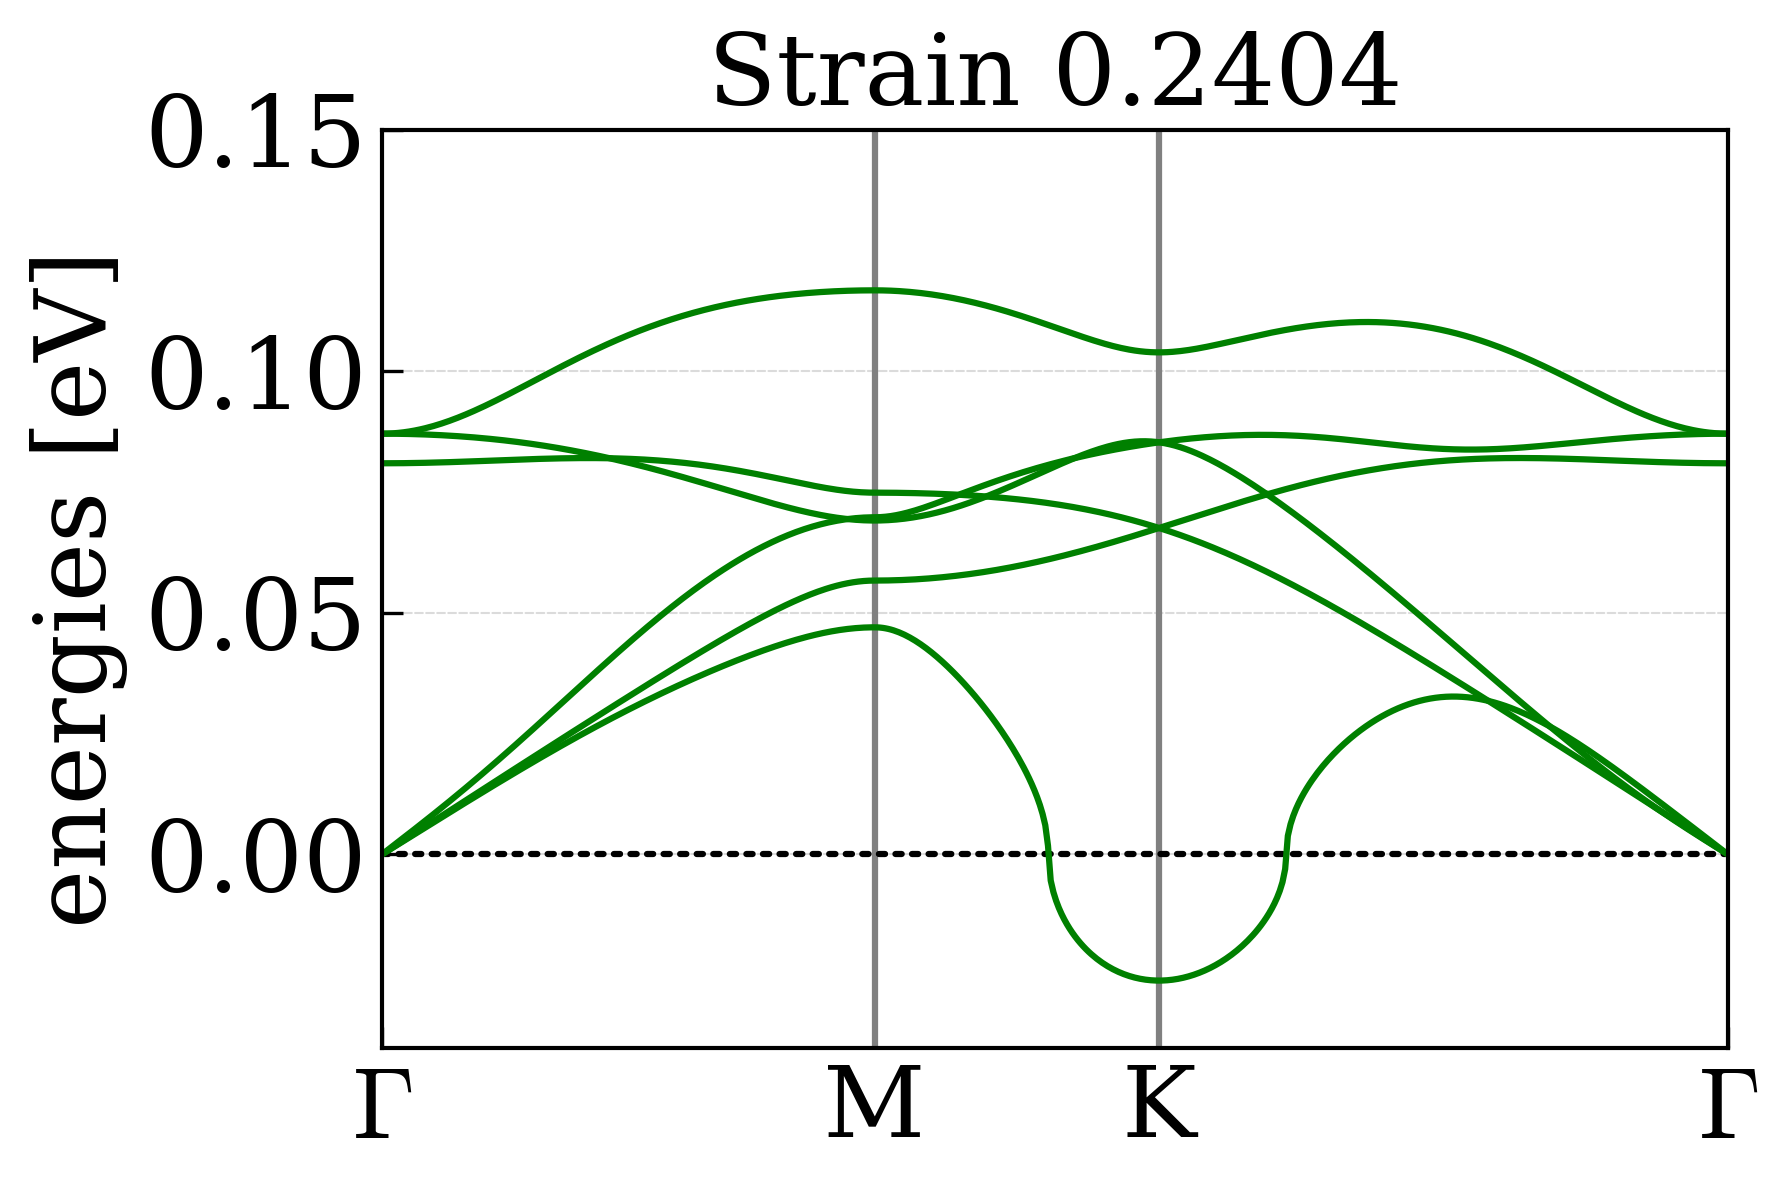

In [79]:
import os

strains = np.linspace(0.15, 0.17, num=10)
ID = np.eye(3)
deformations = [ID + np.array([[s, 0, 0], [0, s, 0], [0, 0, 0]]) for s in strains]


OUTPHONONS = "PHONONDISPERSIONANIMATION"
os.makedirs(OUTPHONONS, exist_ok=True)

for s, deformation in zip(strains, deformations):
    cell = cell0 @ deformation
    deformed = primitive.copy()
    deformed.set_cell(cell, scale_atoms=True)
    displacements = np.random.normal(0, 1e-3, size=(2, 3))
    displacements[:,2] = 0
    deformed.positions += displacements
    deformed.calc = model
    opt = BFGS(deformed)
    opt.run(fmax = 1e-5)

    ph = Phonons(
        deformed,
        model,
        supercell = (9, 9, 1),
        delta = 0.01,
        name="cache"
    )

    ph.run()
    ph.read(acoustic = True)
    ph.clean()

    bandpath = deformed.cell.bandpath(path = "GMKG", npoints = 500)
    bs = ph.get_band_structure(bandpath, modes = False)

    outfile = os.path.join(OUTPHONONS, str(s * np.sqrt(2))+".svg")
    bs.plot()

    plt.title(f"Strain {s*np.sqrt(2):.4f}")
    plt.ylim(-4e-2, 0.15)
    plt.savefig(outfile)
